# EXP-4 — Technique Family Classification with AST

**Experiment 4** classifies the playing technique **family** of each
instrument in a polyphonic string-ensemble mixture.

The 21 SECD playing techniques are grouped into 4 coarse-grained families
based on the physical sound-production mechanism:

| Family | Count | Members |
|---|---|---|
| bowed | 12 | arco-normal, arco-sul-ponticello, arco-sul-tasto, arco-au-talon, arco-tremolo, arco-martele, arco-minor-trill, arco-major-trill, arco-glissando, molto-vibrato, non-vibrato, con-sord |
| plucked | 4 | pizz-normal, pizz-glissando, pizz-tremolo, snap-pizz |
| col_legno | 2 | arco-col-legno-battuto, arco-col-legno-tratto |
| harmonic | 3 | natural-harmonic, artificial-harmonic, arco-harmonic |

EXP4 uses **all** SECD samples regardless of technique.
Each per-instrument technique label is mapped to its family before training.

**Architecture:** AST backbone + 4 per-instrument heads with masked cross-entropy.

## Cell 0 — Path Configuration

Central path registry for EXP4.

The mel-spectrogram cache (`mel_cache_ast16k_256/`) is shared read-only.

Update **only** `base` when migrating between machines.

### Directory layout

```
/home/aggelosger/
├── mel_cache_ast16k_256/            # shared cache (read-only for EXP4)
│   ├── 7th_chords_loose/
│   │   ├── dominant_seventh_loose/  # .npy files
│   │   └── ...
│   ├── harmonic_intervals_loose/
│   │   ├── cello_viola_loose/
│   │   └── ...
│   └── ...
├── harmonic_intervals_loose/csv/    # metadata CSVs
└── EXP4_TEC_FAM/                    # ← EXP4 outputs
    └── exp4_splits/
```

In [1]:
# Cell 0 — Path Configuration (EXP4 — Technique Family Classification)

import os
from dataclasses import dataclass, field
from pathlib import Path

@dataclass
class ExpPaths:
    """Central path registry for EXP4."""

    base:       str = "/home/aggelosger"
    cache_root: str = ""
    outdir:     str = ""
    split_dir:  str = ""
    csv_dirs:   list = field(default_factory=list)

    def __post_init__(self):
        self.cache_root = os.path.join(self.base, "mel_cache_ast16k_256")
        self.outdir     = os.path.join(self.base, "EXP4_TEC_FAM")
        self.split_dir  = os.path.join(self.outdir, "exp4_splits")

        self.csv_dirs = []
        for group in [
            "harmonic_intervals_loose", "harmonic_intervals_strict",
            "triads_loose", "triads_strict",
            "7th_chords_loose", "7th_chords_strict",
        ]:
            d = os.path.join(self.base, group, "csv")
            if os.path.isdir(d):
                self.csv_dirs.append(d)

    def verify(self):
        errors = []
        if not os.path.isdir(self.cache_root):
            errors.append(f"Cache not found: {self.cache_root}")
        if not self.csv_dirs:
            errors.append("No CSV directories found")
        for d in self.csv_dirs:
            csvs = [f for f in os.listdir(d)
                    if f.endswith(".csv") and "-original" not in f]
            if not csvs:
                errors.append(f"No usable CSVs in {d}")
        if errors:
            for e in errors:
                print(f"  ❌ {e}")
            raise RuntimeError("Path verification failed")

        os.makedirs(self.outdir, exist_ok=True)
        os.makedirs(self.split_dir, exist_ok=True)

        all_csvs = []
        for d in self.csv_dirs:
            all_csvs += [os.path.join(d, f) for f in os.listdir(d)
                         if f.endswith(".csv") and "-original" not in f]

        print(f"  ✅ Base       : {self.base}")
        print(f"  ✅ Cache      : {self.cache_root}")
        print(f"  ✅ Output     : {self.outdir}")
        print(f"  ✅ Splits     : {self.split_dir}")
        print(f"  ✅ CSV dirs   : {len(self.csv_dirs)}")
        print(f"  ✅ CSV files  : {len(all_csvs)} (excluding -original)")

        return all_csvs


paths = ExpPaths()
all_csv_paths = paths.verify()
print(f"\n✅ EXP4 Path configuration OK")

  ✅ Base       : /home/aggelosger
  ✅ Cache      : /home/aggelosger/mel_cache_ast16k_256
  ✅ Output     : /home/aggelosger/EXP4_TEC_FAM
  ✅ Splits     : /home/aggelosger/EXP4_TEC_FAM/exp4_splits
  ✅ CSV dirs   : 6
  ✅ CSV files  : 22 (excluding -original)

✅ EXP4 Path configuration OK


## Cell 0.1 — Environment Check

Prints the active Python interpreter path and module search paths.
Run once at the start of a session to confirm the correct
environment is active before loading any dependencies.

In [2]:
import sys

print("Python interpreter:")
print(f"  {sys.executable}")
print("\nModule search paths:")
for p in sys.path:
    if p:
        print(f"  {p}")

Python interpreter:
  /usr/bin/python3

Module search paths:
  /usr/lib/python312.zip
  /usr/lib/python3.12
  /usr/lib/python3.12/lib-dynload
  /home/aggelosger/.local/lib/python3.12/site-packages
  /usr/local/lib/python3.12/dist-packages
  /usr/lib/python3/dist-packages


## Cell 0a — Execution Timestamp Helpers

Two lightweight functions to track when each cell ran and how long it took.
Call `cell_start("Cell X")` at the top and `cell_end("Cell X")` at the bottom
of every cell.

In [3]:
# Cell 0a — Execution Timestamp Helpers

import time
from datetime import datetime

_CELL_START = {}

def cell_start(name: str):
    _CELL_START[name] = time.perf_counter()
    ts = datetime.now().strftime("%Y-%m-%d  %H:%M:%S")
    print(f"[{name}]  started  {ts}")
    print("-" * 60)

def cell_end(name: str):
    elapsed = time.perf_counter() - _CELL_START.get(name, time.perf_counter())
    ts = datetime.now().strftime("%Y-%m-%d  %H:%M:%S")
    h  = int(elapsed // 3600)
    m  = int((elapsed % 3600) // 60)
    s  = elapsed % 60
    dur = f"{h}h {m}m {s:.1f}s" if h else (f"{m}m {s:.1f}s" if m else f"{s:.1f}s")
    print("-" * 60)
    print(f"[{name}]  finished {ts}  |  duration: {dur}")

SEED = 1337
print("Timestamp helpers loaded. Use cell_start() and cell_end() in every cell.")
print(f"SEED = {SEED}")

Timestamp helpers loaded. Use cell_start() and cell_end() in every cell.
SEED = 1337


## Cell 0b — Disable Timestamps Before Publishing

To remove all timestamp output before publishing, replace Cell 0a entirely
with the cell below. Every `cell_start()` and `cell_end()` call across
the notebook will then execute silently without any output.
No other cell needs to be touched.

In [ ]:
# Cell 0b — Execution Timestamp Helpers (DISABLED for publishing)
# Replace Cell 0a with this block to silence all stamps.

# def cell_start(name: str): pass
# def cell_end(name: str):   pass

## Cell 1 — Server Snapshot (RAM · GPU · CPU · Disk)

Prints a full server status report: CPU, RAM, GPU, Disk, Python/PyTorch versions.
Run at the start of every session to confirm the environment is healthy.

In [5]:
# Cell 1 — Server Snapshot (RAM · GPU · CPU · Disk)

cell_start("Cell 1")
import os, platform, subprocess, shutil
import psutil, torch

def _bar(used, total, width=30):
    if total == 0: return "[" + "?" * width + "]"
    filled = int(width * used / total)
    pct = 100 * used / total
    bar = "█" * filled + "░" * (width - filled)
    return f"[{bar}] {pct:5.1f}%"

def _gb(n): return f"{n/1024**3:.2f} GB"

SEP = "═" * 64
sep = "─" * 64

print(f"\n{SEP}")
print(f"  🖥️  SERVER SNAPSHOT — {platform.node()}")
print(f"{SEP}")

# CPU
print(f"\n{sep}")
print(f"  💻  CPU")
print(f"{sep}")
cpu_model = "N/A"
try:
    with open("/proc/cpuinfo") as f:
        for line in f:
            if "model name" in line:
                cpu_model = line.split(":")[1].strip()
                break
except: pass
phys_cores  = psutil.cpu_count(logical=False)
logic_cores = psutil.cpu_count(logical=True)
cpu_pct     = psutil.cpu_percent(interval=1)
print(f"  Model      : {cpu_model}")
print(f"  Cores      : {phys_cores} physical  /  {logic_cores} logical")
print(f"  Usage now  : {cpu_pct:.1f}%  {_bar(cpu_pct, 100, 20)}")

# RAM
print(f"\n{sep}")
print(f"  🧠  RAM")
print(f"{sep}")
vm = psutil.virtual_memory()
print(f"  Total   : {_gb(vm.total)}")
print(f"  Used    : {_gb(vm.used)}  {_bar(vm.used, vm.total)}")
print(f"  Free    : {_gb(vm.available)}")

# GPU
print(f"\n{sep}")
print(f"  🎮  GPU")
print(f"{sep}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        total = props.total_memory
        alloc = torch.cuda.memory_allocated(i)
        print(f"  [{i}] {props.name}")
        print(f"      VRAM : {_gb(alloc)} / {_gb(total)}  {_bar(alloc, total)}")
        print(f"      SMs  : {props.multi_processor_count}  |  CC {props.major}.{props.minor}")
    print(f"  CUDA     : {torch.version.cuda}")
    print(f"  cuDNN    : {torch.backends.cudnn.version()}")
else:
    print("  ⚠️  No CUDA GPU detected")

# Disk
print(f"\n{sep}")
print(f"  💾  DISK")
print(f"{sep}")
for mount in [paths.base, "/tmp"]:
    try:
        usage = shutil.disk_usage(mount)
        print(f"  {mount}")
        print(f"    {_gb(usage.used)} / {_gb(usage.total)}  {_bar(usage.used, usage.total)}")
    except: pass

# Python / Torch
print(f"\n{sep}")
print(f"  🐍  PYTHON & TORCH")
print(f"{sep}")
import sys, transformers, sklearn
print(f"  Python       : {platform.python_version()}  ({sys.executable})")
print(f"  PyTorch      : {torch.__version__}")
print(f"  CUDA rt      : {torch.version.cuda}")
print(f"  transformers : {transformers.__version__}")
print(f"  sklearn      : {sklearn.__version__}")

print(f"\n{SEP}")
print(f"  ✅  Snapshot complete")
print(f"{SEP}\n")
cell_end("Cell 1")

[Cell 1]  started  2026-04-12  10:06:28
------------------------------------------------------------

════════════════════════════════════════════════════════════════
  🖥️  SERVER SNAPSHOT — audio-gpu-workstation
════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────────
  💻  CPU
────────────────────────────────────────────────────────────────
  Model      : Intel(R) Xeon(R) CPU @ 2.20GHz
  Cores      : 4 physical  /  8 logical
  Usage now  : 1.1%  [░░░░░░░░░░░░░░░░░░░░]   1.1%

────────────────────────────────────────────────────────────────
  🧠  RAM
────────────────────────────────────────────────────────────────
  Total   : 31.34 GB
  Used    : 2.12 GB  [██░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   6.7%
  Free    : 29.22 GB

────────────────────────────────────────────────────────────────
  🎮  GPU
────────────────────────────────────────────────────────────────
  [0] NVIDIA L4
      VRAM : 0.00 GB / 22.04 GB  [░░░░░░░░░░░░

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Python       : 3.12.3  (/usr/bin/python3)
  PyTorch      : 2.7.1+cu128
  CUDA rt      : 12.8
  transformers : 5.5.0
  sklearn      : 1.8.0

════════════════════════════════════════════════════════════════
  ✅  Snapshot complete
════════════════════════════════════════════════════════════════

------------------------------------------------------------
[Cell 1]  finished 2026-04-12  10:06:34  |  duration: 5.7s


## Cell 2b(ΟΧΙ ΥΠΟΧΡΕΩΤΙΚΟ ΚΕΛΙ) — Read-only metadata schema discovery for technique naming

In [9]:
# Cell 2b — Read-only metadata schema discovery for technique naming

cell_start("Cell 2b")

import os
import pandas as pd

# ---------------------------------------------------------------------
# This cell is STRICTLY READ-ONLY.
# It does not modify:
#   - any CSV
#   - any WAV
#   - any mel cache
# It only inspects CSV headers and a small sample of rows in memory.
# ---------------------------------------------------------------------

# Expected instrument order used across the project
INSTR_ORDER = ["cello", "viola", "violin2", "violin1"]

# Candidate technique column patterns for per-instrument schemas
def _cand_tec_cols(inst: str):
    return [
        f"{inst}_technique",
        f"{inst}_tec",
        f"technique_{inst}",
        f"tec_{inst}",
    ]

def _cand_tec_code_cols(inst: str):
    return [
        f"{inst}_technique_code",
        f"{inst}_tec_code",
        f"technique_code_{inst}",
        f"tec_code_{inst}",
    ]

def _cand_pitch_cols(inst: str):
    return [f"{inst}_pitch"]

def _cand_file_cols(inst: str):
    return [f"{inst}_file"]

def norm_str(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none", "null"}:
        return None
    return s

def file_subset_kind(csv_path: str):
    p = csv_path.lower()
    if "strict" in p:
        return "strict"
    if "loose" in p:
        return "loose"
    return "unknown"

def file_ensemble_kind(csv_path: str):
    p = csv_path.lower()
    if "harmonic_intervals" in p:
        return "duo"
    if "triads" in p:
        return "trio"
    if "7th_chords" in p:
        return "quartet"
    return "unknown"

def detect_present_instruments(df):
    present = []
    for inst in INSTR_ORDER:
        has_any = False
        for c in _cand_pitch_cols(inst) + _cand_file_cols(inst):
            if c in df.columns:
                has_any = True
                break
        if has_any:
            present.append(inst)
    return present

def discover_technique_schema(df):
    """
    Read-only schema discovery.

    Returns a dictionary describing how technique metadata is stored
    in the given dataframe.
    """
    present_instruments = detect_present_instruments(df)

    shared_text_col = "technique" if "technique" in df.columns else None

    per_inst_text_cols = {}
    for inst in present_instruments:
        for c in _cand_tec_cols(inst):
            if c in df.columns:
                per_inst_text_cols[inst] = c
                break

    per_inst_code_cols = {}
    for inst in present_instruments:
        for c in _cand_tec_code_cols(inst):
            if c in df.columns:
                per_inst_code_cols[inst] = c
                break

    if shared_text_col and per_inst_text_cols:
        schema_type = "mixed"
    elif per_inst_text_cols:
        schema_type = "per_instrument_text"
    elif shared_text_col:
        schema_type = "shared_text"
    else:
        schema_type = "no_text_technique_column"

    return {
        "schema_type": schema_type,
        "present_instruments": present_instruments,
        "shared_text_col": shared_text_col,
        "per_instrument_text_cols": per_inst_text_cols,
        "per_instrument_code_cols": per_inst_code_cols,
    }

def collect_text_technique_values(df, schema_info):
    """
    Collect observed textual technique values from the file,
    based only on the discovered schema.
    """
    observed = set()

    if schema_info["shared_text_col"] is not None:
        col = schema_info["shared_text_col"]
        vals = [norm_str(v) for v in df[col].dropna().unique().tolist()]
        observed.update(v for v in vals if v is not None)

    for inst, col in schema_info["per_instrument_text_cols"].items():
        vals = [norm_str(v) for v in df[col].dropna().unique().tolist()]
        observed.update(v for v in vals if v is not None)

    return sorted(observed)

# ---------------------------------------------------------------------
# Build file inventory from the known EXP4 path structure
# ---------------------------------------------------------------------

_CSV_MAP = {
    "duos_loose": ("harmonic_intervals_loose", [
        "cello_viola_loose.csv", "cello_violin_loose.csv", "viola_violin_loose.csv"
    ]),
    "trios_loose": ("triads_loose", [
        "triads_major_loose.csv", "triads_minor_loose.csv",
        "triads_diminished_loose.csv", "triads_augmented_loose.csv"
    ]),
    "quartets_loose": ("7th_chords_loose", [
        "major_seventh_loose.csv", "minor_seventh_loose.csv",
        "dominant_seventh_loose.csv", "half_diminished_seventh_loose.csv"
    ]),
    "duos_strict": ("harmonic_intervals_strict", [
        "cello_viola_strict.csv", "cello_violin_strict.csv", "viola_violin_strict.csv"
    ]),
    "trios_strict": ("triads_strict", [
        "triads_major_strict.csv", "triads_minor_strict.csv",
        "triads_diminished_strict.csv", "triads_augmented_strict.csv"
    ]),
    "quartets_strict": ("7th_chords_strict", [
        "major_seventh_strict.csv", "minor_seventh_strict.csv",
        "dominant_seventh_strict.csv", "half_diminished_seventh_strict.csv"
    ]),
}

def _build_csv_list(group_key):
    folder, files = _CSV_MAP[group_key]
    return [os.path.join(paths.base, folder, "csv", f) for f in files]

csv_duos_loose      = _build_csv_list("duos_loose")
csv_trios_loose     = _build_csv_list("trios_loose")
csv_quartets_loose  = _build_csv_list("quartets_loose")
csv_duos_strict     = _build_csv_list("duos_strict")
csv_trios_strict    = _build_csv_list("trios_strict")
csv_quartets_strict = _build_csv_list("quartets_strict")

ALL_CSVS = (
    csv_duos_loose + csv_trios_loose + csv_quartets_loose +
    csv_duos_strict + csv_trios_strict + csv_quartets_strict
)

missing = [p for p in ALL_CSVS if not os.path.isfile(p)]
if missing:
    print("❌ Missing CSV files:")
    for p in missing:
        print("  -", p)
    raise FileNotFoundError(f"{len(missing)} CSV(s) missing.")

# ---------------------------------------------------------------------
# Read-only schema registry
# ---------------------------------------------------------------------

TECHNIQUE_SCHEMA_REGISTRY = {}
SCHEMA_SUMMARY_ROWS = []

print("\n" + "═" * 72)
print("READ-ONLY DISCOVERY OF TECHNIQUE NAMING SCHEMA")
print("═" * 72)

for csv_path in ALL_CSVS:
    # nrows limit is enough for schema/header discovery; use full file only
    # for observed textual values when needed
    df_head = pd.read_csv(csv_path, nrows=20)
    schema_info = discover_technique_schema(df_head)

    # For observed textual technique values, read only relevant text cols
    text_cols_to_read = []
    if schema_info["shared_text_col"] is not None:
        text_cols_to_read.append(schema_info["shared_text_col"])
    text_cols_to_read.extend(schema_info["per_instrument_text_cols"].values())
    text_cols_to_read = sorted(set(text_cols_to_read))

    if text_cols_to_read:
        df_text = pd.read_csv(csv_path, usecols=text_cols_to_read)
        observed_text_values = collect_text_technique_values(df_text, schema_info)
    else:
        observed_text_values = []

    info = {
        "csv_path": csv_path,
        "csv_file": os.path.basename(csv_path),
        "subset": file_subset_kind(csv_path),
        "ensemble": file_ensemble_kind(csv_path),
        "schema_type": schema_info["schema_type"],
        "present_instruments": schema_info["present_instruments"],
        "shared_text_col": schema_info["shared_text_col"],
        "per_instrument_text_cols": schema_info["per_instrument_text_cols"],
        "per_instrument_code_cols": schema_info["per_instrument_code_cols"],
        "observed_text_techniques": observed_text_values,
    }

    TECHNIQUE_SCHEMA_REGISTRY[csv_path] = info

    SCHEMA_SUMMARY_ROWS.append({
        "csv_file": info["csv_file"],
        "subset": info["subset"],
        "ensemble": info["ensemble"],
        "schema_type": info["schema_type"],
        "n_instruments": len(info["present_instruments"]),
        "shared_text_col": info["shared_text_col"] if info["shared_text_col"] else "",
        "n_per_inst_text_cols": len(info["per_instrument_text_cols"]),
        "n_per_inst_code_cols": len(info["per_instrument_code_cols"]),
        "n_observed_text_techniques": len(info["observed_text_techniques"]),
    })

    print(f"\n{info['csv_file']}")
    print(f"  subset                : {info['subset']}")
    print(f"  ensemble              : {info['ensemble']}")
    print(f"  schema_type           : {info['schema_type']}")
    print(f"  present_instruments   : {info['present_instruments']}")
    print(f"  shared_text_col       : {info['shared_text_col']}")
    print(f"  per_instrument_text   : {info['per_instrument_text_cols']}")
    print(f"  per_instrument_codes  : {info['per_instrument_code_cols']}")
    print(f"  observed_text_values  : {info['observed_text_techniques']}")

SCHEMA_SUMMARY_DF = pd.DataFrame(SCHEMA_SUMMARY_ROWS)

print("\n" + "─" * 72)
print("COMPACT SCHEMA SUMMARY")
print("─" * 72)
display(SCHEMA_SUMMARY_DF)

print("\n" + "─" * 72)
print("KEY DISCOVERY")
print("─" * 72)
print("  - Duo files may use a shared textual column named 'technique'.")
print("  - Trio/quartet files may use per-instrument textual technique columns.")
print("  - Code columns are tracked separately and can be decoded later if needed.")
print("  - No file has been modified. This cell is inspection-only.")

cell_end("Cell 2b")

[Cell 2b]  started  2026-04-12  10:28:15
------------------------------------------------------------

════════════════════════════════════════════════════════════════════════
READ-ONLY DISCOVERY OF TECHNIQUE NAMING SCHEMA
════════════════════════════════════════════════════════════════════════

cello_viola_loose.csv
  subset                : loose
  ensemble              : duo
  schema_type           : shared_text
  present_instruments   : ['cello', 'viola']
  shared_text_col       : technique
  per_instrument_text   : {}
  per_instrument_codes  : {'cello': 'cello_technique_code', 'viola': 'viola_technique_code'}
  observed_text_values  : ['arco-col-legno-battuto', 'arco-harmonic', 'arco-major-trill', 'arco-minor-trill', 'arco-normal', 'molto-vibrato', 'non-vibrato']

cello_violin_loose.csv
  subset                : loose
  ensemble              : duo
  schema_type           : shared_text
  present_instruments   : ['cello', 'violin1']
  shared_text_col       : technique
  per_instrume

,csv_file,subset,ensemble,schema_type,n_instruments,shared_text_col,n_per_inst_text_cols,n_per_inst_code_cols,n_observed_text_techniques
0,cello_viola_loose.csv,loose,duo,shared_text,2,technique,0,2,7
1,cello_violin_loose.csv,loose,duo,shared_text,2,technique,0,2,7
2,viola_violin_loose.csv,loose,duo,shared_text,2,technique,0,2,11
3,triads_major_loose.csv,loose,trio,per_instrument_text,3,,3,0,19
4,triads_minor_loose.csv,loose,trio,per_instrument_text,3,,3,0,20
5,triads_diminished_loose.csv,loose,trio,per_instrument_text,3,,3,0,19
6,triads_augmented_loose.csv,loose,trio,per_instrument_text,3,,3,0,20
7,major_seventh_loose.csv,loose,quartet,per_instrument_text,4,,4,0,21
8,minor_seventh_loose.csv,loose,quartet,per_instrument_text,4,,4,0,21
9,dominant_seventh_loose.csv,loose,quartet,per_instrument_text,4,,4,0,21



────────────────────────────────────────────────────────────────────────
KEY DISCOVERY
────────────────────────────────────────────────────────────────────────
  - Duo files may use a shared textual column named 'technique'.
  - Trio/quartet files may use per-instrument textual technique columns.
  - Code columns are tracked separately and can be decoded later if needed.
  - No file has been modified. This cell is inspection-only.
------------------------------------------------------------
[Cell 2b]  finished 2026-04-12  10:28:16  |  duration: 1.1s


## Cell 2c(ΟΧΙ ΥΠΟΧΡΕΩΤΙΚΟ ΚΕΛΙ) — Read-only unified per-instrument technique extraction

In [15]:
# Cell 2c — Read-only unified per-instrument technique extraction
# Purpose:
#   Build a single in-memory interface for per-instrument technique names
#   across duos / trios / quartets, without modifying any SECD file.

cell_start("Cell 2c")

import os
import re
import pandas as pd

# ------------------------------------------------------------
# Strictly read-only
# ------------------------------------------------------------

INSTR_ORDER = ["cello", "viola", "violin2", "violin1"]

def norm_str(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none", "null"}:
        return None
    return s

def detect_present_instruments_from_row(row):
    present = []
    for inst in INSTR_ORDER:
        if f"{inst}_file" in row.index or f"{inst}_pitch" in row.index:
            val_file = row.get(f"{inst}_file", None)
            val_pitch = row.get(f"{inst}_pitch", None)
            if pd.notna(val_file) or pd.notna(val_pitch):
                present.append(inst)
    return present

def extract_technique_from_sample_path(sample_path: str):
    """
    Parse technique text from a source sample filename like:
      cello_F4_15_fortissimo_arco-normal.wav
      viola_A6_long_mezzo-forte_natural-harmonic.wav
      violin_Gs4_very-long_pianissimo_arco-tremolo.wav

    We extract the trailing token after the dynamic field.
    """
    s = norm_str(sample_path)
    if s is None:
        return None

    base = os.path.basename(s)

    # Remove extension
    if base.lower().endswith(".wav"):
        base = base[:-4]

    # Known dynamics, sorted longest-first to avoid partial matches
    dynamics = sorted([
        "pianissimo",
        "mezzo-piano",
        "mezzo-forte",
        "fortissimo",
        "piano",
        "forte",
    ], key=len, reverse=True)

    for dyn in dynamics:
        marker = "_" + dyn + "_"
        idx = base.find(marker)
        if idx != -1:
            return base[idx + len(marker):].strip()

    return None

def get_row_techniques(row, csv_path=None):
    """
    Unified per-instrument technique extraction.

    Rules:
    - For duos: derive technique per instrument from source filenames.
      Do NOT trust the shared duo 'technique' column as full instrument truth.
    - For trios/quartets: use explicit per-instrument text technique columns.
      Fallback to filename parsing only if needed.

    Returns dict like:
      {'cello': 'arco-normal', 'viola': 'pizz-normal'}
    """
    out = {}
    present = detect_present_instruments_from_row(row)

    # Detect whether explicit per-instrument text technique columns exist
    explicit_text_cols = {
        inst: f"{inst}_technique"
        for inst in present
        if f"{inst}_technique" in row.index
    }

    if explicit_text_cols:
        # Trios / quartets typically land here
        for inst, col in explicit_text_cols.items():
            val = norm_str(row.get(col, None))
            if val is not None:
                out[inst] = val
            else:
                # Conservative fallback from source filename
                file_col = f"{inst}_file"
                out[inst] = extract_technique_from_sample_path(row.get(file_col, None))
        return out

    # Otherwise, likely duo schema -> derive from per-instrument source files
    for inst in present:
        file_col = f"{inst}_file"
        out[inst] = extract_technique_from_sample_path(row.get(file_col, None))

    return out

def get_row_technique_families(row, csv_path=None):
    """
    Map the unified per-instrument techniques to families using TEC_TO_FAMILY.
    TEC_TO_FAMILY must exist later; this helper is safe to define now.
    """
    techs = get_row_techniques(row, csv_path=csv_path)
    fams = {}
    for inst, tec in techs.items():
        fams[inst] = TEC_TO_FAMILY.get(tec, None) if tec is not None else None
    return fams

def extract_dynamic_from_sample_path(sample_path: str):
    """
    Parse dynamic text from a source sample filename like:
      cello_F4_15_fortissimo_arco-normal.wav
      viola_A6_long_mezzo-forte_natural-harmonic.wav
      violin_Gs4_very-long_pianissimo_arco-tremolo.wav
    """
    s = norm_str(sample_path)
    if s is None:
        return None

    base = os.path.basename(s)
    if base.lower().endswith(".wav"):
        base = base[:-4]

    dynamics = sorted([
        "pianissimo",
        "mezzo-piano",
        "mezzo-forte",
        "fortissimo",
        "piano",
        "forte",
    ], key=len, reverse=True)

    for dyn in dynamics:
        marker = "_" + dyn + "_"
        if marker in base:
            return dyn

    return None


def get_row_dynamics(row, csv_path=None):
    """
    Unified per-instrument dynamic extraction.

    Rules:
    - For duos: derive dynamics per instrument from source filenames.
    - For trios/quartets: use explicit per-instrument text dynamic columns.
      Fallback to filename parsing only if needed.
    """
    out = {}
    present = detect_present_instruments_from_row(row)

    explicit_dyn_cols = {
        inst: f"{inst}_dynamic"
        for inst in present
        if f"{inst}_dynamic" in row.index
    }

    if explicit_dyn_cols:
        for inst, col in explicit_dyn_cols.items():
            val = norm_str(row.get(col, None))
            if val is not None:
                out[inst] = val
            else:
                file_col = f"{inst}_file"
                out[inst] = extract_dynamic_from_sample_path(row.get(file_col, None))
        return out

    for inst in present:
        file_col = f"{inst}_file"
        out[inst] = extract_dynamic_from_sample_path(row.get(file_col, None))

    return out


# ------------------------------------------------------------
# Quick read-only sanity report
# ------------------------------------------------------------

print("\n" + "═" * 72)
print("UNIFIED PER-INSTRUMENT TECHNIQUE EXTRACTION — SANITY CHECK")
print("═" * 72)

preview_files = [
    os.path.join(paths.base, "harmonic_intervals_loose", "csv", "viola_violin_loose.csv"),
    os.path.join(paths.base, "harmonic_intervals_strict", "csv", "viola_violin_strict.csv"),
    os.path.join(paths.base, "triads_loose", "csv", "triads_minor_loose.csv"),
    os.path.join(paths.base, "7th_chords_loose", "csv", "major_seventh_loose.csv"),
]

for csv_path in preview_files:
    if not os.path.isfile(csv_path):
        continue

    df = pd.read_csv(csv_path, nrows=3)
    print(f"\n{os.path.basename(csv_path)}")

    for i, row in df.iterrows():
        techs = get_row_techniques(row, csv_path=csv_path)
        print(f"  row {i}: {techs}")

print("\n" + "─" * 72)
print("NOTES")
print("─" * 72)
print("  - Duos: per-instrument techniques are derived from source sample filenames.")
print("  - Trios/Quartets: per-instrument textual technique columns are used directly.")
print("  - This cell performs no writes to CSVs, WAVs, or caches.")

cell_end("Cell 2c")

[Cell 2c]  started  2026-04-12  11:05:28
------------------------------------------------------------

════════════════════════════════════════════════════════════════════════
UNIFIED PER-INSTRUMENT TECHNIQUE EXTRACTION — SANITY CHECK
════════════════════════════════════════════════════════════════════════

viola_violin_loose.csv
  row 0: {'viola': 'arco-normal', 'violin1': 'arco-normal'}
  row 1: {'viola': 'arco-normal', 'violin1': 'arco-normal'}
  row 2: {'viola': 'pizz-normal', 'violin1': 'arco-sul-tasto'}

viola_violin_strict.csv
  row 0: {'viola': 'arco-normal', 'violin1': 'arco-normal'}
  row 1: {'viola': 'arco-normal', 'violin1': 'arco-normal'}
  row 2: {'viola': 'arco-normal', 'violin1': 'arco-normal'}

triads_minor_loose.csv
  row 0: {'cello': 'arco-col-legno-battuto', 'viola': 'arco-normal', 'violin1': 'arco-normal'}
  row 1: {'cello': 'arco-col-legno-battuto', 'viola': 'arco-normal', 'violin1': 'arco-normal'}
  row 2: {'cello': 'arco-col-legno-battuto', 'viola': 'arco-glissa

## Cell 3 — Constants, Paths, CSV Inventory

Defines all shared constants and directory paths:

- **Instruments**: fixed order (cello, viola, violin2, violin1)
- **Technique family mapping**: 21 raw techniques → 4 families
- **Mel cache**: AST-native features at 16 kHz, 128 mel bins, 256 frames
  (extracted via `ASTFeatureExtractor` with AudioSet global normalization)

Also scans the CSV inventory and reports file counts.

In [16]:
# Cell 3 — Constants, paths, CSV inventory, validated technique-family setup (EXP4)

cell_start("Cell 3")

import os

# ── AST model ──
MODEL_NAME = "MIT/ast-finetuned-audioset-10-10-0.4593"
TARGET_FRAMES = 256

# ── Instruments ──
INSTR_ORDER = ["cello", "viola", "violin2", "violin1"]
INSTRUMENTS = INSTR_ORDER

# ── Full validated global technique vocabulary (SECD-wide across inspected CSVs) ──
TECHNIQUES = [
    "arco-normal", "arco-sul-ponticello", "arco-sul-tasto", "arco-au-talon",
    "arco-tremolo", "arco-martele", "arco-minor-trill", "arco-major-trill",
    "arco-glissando", "arco-col-legno-battuto", "arco-col-legno-tratto",
    "arco-harmonic",
    "pizz-normal", "pizz-glissando", "pizz-tremolo", "snap-pizz",
    "natural-harmonic", "artificial-harmonic",
    "molto-vibrato", "non-vibrato", "con-sord",
]

# ── Dynamics vocabulary (kept for data loading) ──
DYNAMICS = [
    "pianissimo", "piano", "mezzo-piano", "mezzo-forte", "forte", "fortissimo"
]

# ── Technique family mapping ──
TEC_TO_FAMILY = {
    "arco-normal":             "bowed",
    "arco-sul-ponticello":     "bowed",
    "arco-sul-tasto":          "bowed",
    "arco-au-talon":           "bowed",
    "arco-tremolo":            "bowed",
    "arco-martele":            "bowed",
    "arco-minor-trill":        "bowed",
    "arco-major-trill":        "bowed",
    "arco-glissando":          "bowed",
    "molto-vibrato":           "bowed",
    "non-vibrato":             "bowed",
    "con-sord":                "bowed",
    "pizz-normal":             "plucked",
    "pizz-glissando":          "plucked",
    "pizz-tremolo":            "plucked",
    "snap-pizz":               "plucked",
    "arco-col-legno-battuto":  "col_legno",
    "arco-col-legno-tratto":   "col_legno",
    "natural-harmonic":        "harmonic",
    "artificial-harmonic":     "harmonic",
    "arco-harmonic":           "harmonic",
}

TECHNIQUE_FAMILIES = sorted(set(TEC_TO_FAMILY.values()))

# ── Mel cache ──
CACHE_ROOT = paths.cache_root

# ── CSV helpers ──
CANDIDATE_FILENAME_COLS = [
    "chord_filename", "filename", "wav_filename", "output_wav", "wav_file"
]

def resolve_filename_column(df):
    for c in CANDIDATE_FILENAME_COLS:
        if c in df.columns:
            return c
    raise KeyError("Filename column not found in CSV.")

def derive_audio_root_from_csv(csv_path: str) -> str:
    csv_dir, csv_file = os.path.split(csv_path)
    base = os.path.splitext(csv_file)[0]
    wav_dir = csv_dir.replace("/csv", "/wav")
    return os.path.join(wav_dir, base) + "/"

def _cand_dyn_cols(inst: str):
    return [f"{inst}_dynamic", f"{inst}_dyn", f"dynamic_{inst}", f"dyn_{inst}"]

def _cand_tec_cols(inst: str):
    return [f"{inst}_technique", f"{inst}_tec", f"technique_{inst}", f"tec_{inst}"]

# ── CSV inventory ──
_CSV_MAP = {
    "duos_loose": ("harmonic_intervals_loose", [
        "cello_viola_loose.csv", "cello_violin_loose.csv", "viola_violin_loose.csv"]),
    "trios_loose": ("triads_loose", [
        "triads_major_loose.csv", "triads_minor_loose.csv",
        "triads_diminished_loose.csv", "triads_augmented_loose.csv"]),
    "quartets_loose": ("7th_chords_loose", [
        "major_seventh_loose.csv", "minor_seventh_loose.csv",
        "dominant_seventh_loose.csv", "half_diminished_seventh_loose.csv"]),
    "duos_strict": ("harmonic_intervals_strict", [
        "cello_viola_strict.csv", "cello_violin_strict.csv", "viola_violin_strict.csv"]),
    "trios_strict": ("triads_strict", [
        "triads_major_strict.csv", "triads_minor_strict.csv",
        "triads_diminished_strict.csv", "triads_augmented_strict.csv"]),
    "quartets_strict": ("7th_chords_strict", [
        "major_seventh_strict.csv", "minor_seventh_strict.csv",
        "dominant_seventh_strict.csv", "half_diminished_seventh_strict.csv"]),
}

def _build_csv_list(group_key):
    folder, files = _CSV_MAP[group_key]
    return [os.path.join(paths.base, folder, "csv", f) for f in files]

csv_duos_loose      = _build_csv_list("duos_loose")
csv_trios_loose     = _build_csv_list("trios_loose")
csv_quartets_loose  = _build_csv_list("quartets_loose")
csv_duos_strict     = _build_csv_list("duos_strict")
csv_trios_strict    = _build_csv_list("trios_strict")
csv_quartets_strict = _build_csv_list("quartets_strict")

ALL_CSVS = (
    csv_duos_loose + csv_trios_loose + csv_quartets_loose +
    csv_duos_strict + csv_trios_strict + csv_quartets_strict
)

_missing = [p for p in ALL_CSVS if not os.path.isfile(p)]
if _missing:
    print("❌ Missing CSV files:")
    for p in _missing:
        print("  -", p)
    raise FileNotFoundError(f"{len(_missing)} CSV(s) missing.")

# ── Validation against discovered schema from Cell 2b ──
if "TECHNIQUE_SCHEMA_REGISTRY" not in globals():
    raise RuntimeError("Cell 2b must be executed before Cell 3.")

if "get_row_techniques" not in globals():
    raise RuntimeError("Cell 2c must be executed before Cell 3.")

schema_types_seen = set()
globally_observed_text_techniques = set()

for csv_path in ALL_CSVS:
    if csv_path not in TECHNIQUE_SCHEMA_REGISTRY:
        raise RuntimeError(f"Missing schema entry for: {csv_path}")

    info = TECHNIQUE_SCHEMA_REGISTRY[csv_path]
    schema_types_seen.add(info["schema_type"])
    globally_observed_text_techniques.update(info["observed_text_techniques"])

unknown_observed = sorted(globally_observed_text_techniques - set(TECHNIQUES))
unmapped_declared = sorted(set(TECHNIQUES) - set(TEC_TO_FAMILY.keys()))

if unknown_observed:
    print("❌ Observed techniques missing from TECHNIQUES:")
    for x in unknown_observed:
        print("  -", x)
    raise RuntimeError("Cell 3 vocabulary is incomplete.")

if unmapped_declared:
    print("❌ Declared techniques missing from TEC_TO_FAMILY:")
    for x in unmapped_declared:
        print("  -", x)
    raise RuntimeError("Technique family mapping is incomplete.")

print(f"  Technique families : {TECHNIQUE_FAMILIES}")
print("  Family sizes       :")
for fam in TECHNIQUE_FAMILIES:
    members = [t for t, f in TEC_TO_FAMILY.items() if f == fam]
    print(f"    {fam:12s} : {len(members):2d} techniques — {members}")

print("\n  Validated metadata schema:")
print(f"    schema types seen     : {sorted(schema_types_seen)}")
print("    duo handling          : per-instrument techniques derived from source filenames")
print("    trio/quartet handling : per-instrument technique columns used directly")

print(f"\n   CSV inventory OK — {len(ALL_CSVS)} files found.")
print(f"   FAMILIES    : {len(TECHNIQUE_FAMILIES)} classes — {TECHNIQUE_FAMILIES}")
print(f"   TECHNIQUES  : {len(TECHNIQUES)} raw techniques")
print(f"   OBSERVED    : {len(globally_observed_text_techniques)} validated textual techniques")
print(f"   CACHE_ROOT  : {CACHE_ROOT}")
print(f"   OUTDIR      : {paths.outdir}")

cell_end("Cell 3")

[Cell 3]  started  2026-04-12  11:05:39
------------------------------------------------------------
  Technique families : ['bowed', 'col_legno', 'harmonic', 'plucked']
  Family sizes       :
    bowed        : 12 techniques — ['arco-normal', 'arco-sul-ponticello', 'arco-sul-tasto', 'arco-au-talon', 'arco-tremolo', 'arco-martele', 'arco-minor-trill', 'arco-major-trill', 'arco-glissando', 'molto-vibrato', 'non-vibrato', 'con-sord']
    col_legno    :  2 techniques — ['arco-col-legno-battuto', 'arco-col-legno-tratto']
    harmonic     :  3 techniques — ['natural-harmonic', 'artificial-harmonic', 'arco-harmonic']
    plucked      :  4 techniques — ['pizz-normal', 'pizz-glissando', 'pizz-tremolo', 'snap-pizz']

  Validated metadata schema:
    schema types seen     : ['per_instrument_text', 'shared_text']
    duo handling          : per-instrument techniques derived from source filenames
    trio/quartet handling : per-instrument technique columns used directly

   CSV inventory OK — 22 f

## Cell 4 — Load Metadata & Map Technique Families (ALL samples)

EXP4 uses **all** SECD samples regardless of technique.
Each per-instrument technique label is mapped to its coarse-grained family.

### What this cell does

1. **Loads all SECD metadata** — combines strict and loose subsets
2. **Standardizes per-instrument labels** (`dyn_*`, `tec_*`)
3. **Maps techniques to families** — adds `fam_cello`, `fam_viola`, etc.
4. **Links each sample to its cached mel-spectrogram** (128×256)
5. **NO technique filter applied** — all samples are kept

In [17]:
# Cell 4 — Load metadata & map technique families (ALL samples, no filter)

cell_start("Cell 4")

import os
import pandas as pd
import numpy as np


def _abs_path(audio_root: str, x: str) -> str:
    x = str(x).strip()
    return x if os.path.isabs(x) else os.path.normpath(os.path.join(audio_root, x))


def _cache_path(cache_root: str, csv_path: str, abs_wav_path: str) -> str:
    """Derive cache .npy path from the CSV path and WAV filename.

    Cache structure mirrors the WAV directory layout:
      {cache_root}/{group}/{csv_stem}/{wav_stem}.npy
    """
    csv_dir = os.path.dirname(csv_path)
    group = os.path.basename(os.path.dirname(csv_dir))
    csv_stem = os.path.splitext(os.path.basename(csv_path))[0]
    wav_stem = os.path.splitext(os.path.basename(abs_wav_path))[0]
    return os.path.join(cache_root, group, csv_stem, f"{wav_stem}.npy")


def load_block(csv_list, ensemble_tag, cache_root):
    """Load metadata from a list of CSVs and create per-sample entries."""
    frames = []

    for csv_path in csv_list:
        if not os.path.exists(csv_path):
            print(f"   Warning: CSV not found, skipping: {csv_path}")
            continue

        df = pd.read_csv(csv_path)
        fname_col = resolve_filename_column(df)
        audio_root = derive_audio_root_from_csv(csv_path)
        subset = "strict" if "strict" in csv_path else "loose"

        for _, row in df.iterrows():
            abs_fp = _abs_path(audio_root, row[fname_col])
            cf = _cache_path(cache_root, csv_path, abs_fp)

            techs = get_row_techniques(row, csv_path=csv_path)
            dyns = get_row_dynamics(row, csv_path=csv_path)

            entry = {
                "filepath": abs_fp,
                "cachefile": cf,
                "ensemble_size": ensemble_tag,
                "subset": subset,
                "csv_source": os.path.basename(csv_path),
            }

            for inst in INSTR_ORDER:
                tec_val = techs.get(inst, None)
                dyn_val = dyns.get(inst, None)

                entry[f"tec_{inst}"] = tec_val
                entry[f"dyn_{inst}"] = dyn_val
                entry[f"has_{inst}"] = (tec_val is not None) or (dyn_val is not None)

            frames.append(entry)

    return pd.DataFrame(frames)


if "get_row_techniques" not in globals():
    raise RuntimeError("Cell 2c must be executed before Cell 4.")

if "get_row_dynamics" not in globals():
    raise RuntimeError("Cell 2c dynamic helpers must be defined before Cell 4.")

print("Loading all SECD metadata...")

blocks = []
for tag, csvs in [
    ("duo",     csv_duos_loose),
    ("trio",    csv_trios_loose),
    ("quartet", csv_quartets_loose),
    ("duo",     csv_duos_strict),
    ("trio",    csv_trios_strict),
    ("quartet", csv_quartets_strict),
]:
    block = load_block(csvs, tag, CACHE_ROOT)
    subset = "strict" if "strict" in csvs[0] else "loose"
    blocks.append(block)
    print(f"   {subset:6s} {tag:8s} : {len(block):>7,} samples")

df_all = pd.concat(blocks, ignore_index=True)
print(f"\n   Total samples loaded: {len(df_all):,}")

# ── Map techniques → families ──
n_mapped = 0
n_unmapped = 0

for inst in INSTR_ORDER:
    tec_col = f"tec_{inst}"
    fam_col = f"fam_{inst}"

    families = []
    for tec in df_all[tec_col]:
        if pd.isna(tec) or tec is None:
            families.append(None)
        elif str(tec) in TEC_TO_FAMILY:
            families.append(TEC_TO_FAMILY[str(tec)])
            n_mapped += 1
        else:
            families.append(None)
            n_unmapped += 1

    df_all[fam_col] = families

print(f"\n   Technique → Family mapping:")
print(f"     Mapped   : {n_mapped:>9,} labels")
print(f"     Unmapped : {n_unmapped:>9,} labels (instrument absent or unknown)")

# ── Verify cache existence ──
cache_exists = df_all["cachefile"].apply(os.path.exists)
n_cached = int(cache_exists.sum())
n_missing_cache = int((~cache_exists).sum())

print(f"\n   Cache files found   : {n_cached:>9,}")
print(f"   Cache files missing : {n_missing_cache:>9,}")

if n_missing_cache > 0 and n_cached == 0:
    sample_cf = df_all["cachefile"].iloc[0]
    print(f"\n   Sample expected cache path:")
    print(f"     {sample_cf}")
    print(f"     Exists: {os.path.exists(sample_cf)}")
    if os.path.isdir(CACHE_ROOT):
        subdirs = sorted(os.listdir(CACHE_ROOT))[:10]
        print(f"     Cache root contains: {subdirs}")
    raise RuntimeError(
        "All cache files missing. Check _cache_path() logic versus actual cache structure."
    )
elif n_missing_cache > 0:
    print(f"   Warning: {n_missing_cache:,} samples have no cached spectrogram — filtering them out.")
    df_all = df_all[cache_exists].reset_index(drop=True)

print(f"\n   Final df_all size: {len(df_all):,}")

# ── Quick coverage summary ──
print("\n   Non-null technique labels per instrument:")
for inst in INSTR_ORDER:
    n = int(df_all[f"tec_{inst}"].notna().sum())
    print(f"     {inst:8s}: {n:>9,}")

print("\n   Non-null family labels per instrument:")
for inst in INSTR_ORDER:
    n = int(df_all[f"fam_{inst}"].notna().sum())
    print(f"     {inst:8s}: {n:>9,}")

print("\n✅ df_all ready — all samples loaded with unified per-instrument technique families")
cell_end("Cell 4")

[Cell 4]  started  2026-04-12  11:06:11
------------------------------------------------------------
Loading all SECD metadata...
   loose  duo      :  90,000 samples
   loose  trio     :  80,000 samples
   loose  quartet  :  92,598 samples
   strict duo      :  11,224 samples
   strict trio     :   4,586 samples
   strict quartet  :   8,680 samples

   Total samples loaded: 287,088

   Technique → Family mapping:
     Mapped   :   860,796 labels
     Unmapped :         0 labels (instrument absent or unknown)

   Cache files found   :   287,088
   Cache files missing :         0

   Final df_all size: 287,088

   Non-null technique labels per instrument:
     cello   :   252,396
     viola   :   253,932
     violin2 :   101,278
     violin1 :   253,190

   Non-null family labels per instrument:
     cello   :   252,396
     viola   :   253,932
     violin2 :   101,278
     violin1 :   253,190

✅ df_all ready — all samples loaded with unified per-instrument technique families
----------

## Cell 4b — Technique Family Distribution per Instrument

This cell examines the distribution of technique families across all
instruments in the loaded dataset, showing both family-level counts and
the raw techniques that contribute to each family.

In [18]:
# Cell 4b — Technique family distribution diagnostics
cell_start("Cell 4b")

import pandas as pd

print("=" * 70)
print("  TECHNIQUE FAMILY DISTRIBUTION PER INSTRUMENT")
print("=" * 70)

for inst in INSTR_ORDER:
    fam_col = f"fam_{inst}"
    tec_col = f"tec_{inst}"

    fam_counts = df_all[fam_col].value_counts(dropna=True)
    total = fam_counts.sum()

    print(f"\n  {inst.upper()} ({total:,} labelled samples)")
    print(f"  {'Family':<12s}  {'Count':>8s}  {'%':>6s}  {'Techniques':>s}")
    print(f"  {'-'*60}")

    for fam in TECHNIQUE_FAMILIES:
        count = fam_counts.get(fam, 0)
        pct = 100 * count / total if total > 0 else 0
        mask = df_all[fam_col] == fam
        raw_tecs = df_all.loc[mask, tec_col].value_counts()
        tec_str = ", ".join(f"{t}({c})" for t, c in raw_tecs.head(5).items())
        print(f"  {fam:<12s}  {count:>8,}  {pct:>5.1f}%  {tec_str}")

# Cross-instrument agreement for strict samples
print(f"\n{'=' * 70}")
print("  STRICT SAMPLES — CROSS-INSTRUMENT FAMILY AGREEMENT")
print(f"{'=' * 70}")

strict_df = df_all[df_all["subset"] == "strict"]
fam_cols = [f"fam_{inst}" for inst in INSTR_ORDER]
n_agree = n_disagree = 0
for _, row in strict_df.iterrows():
    fams = [row[c] for c in fam_cols if row[c] is not None and pd.notna(row[c])]
    if len(fams) > 1:
        if len(set(fams)) == 1: n_agree += 1
        else: n_disagree += 1
    elif len(fams) == 1:
        n_agree += 1

print(f"  All instruments same family : {n_agree:>8,}")
print(f"  Mixed families              : {n_disagree:>8,}")
print(f"  Note: strict samples should all agree by definition.")

cell_end("Cell 4b")

[Cell 4b]  started  2026-04-12  11:07:33
------------------------------------------------------------
  TECHNIQUE FAMILY DISTRIBUTION PER INSTRUMENT

  CELLO (252,396 labelled samples)
  Family           Count       %  Techniques
  ------------------------------------------------------------
  bowed          243,665   96.5%  arco-normal(230203), non-vibrato(5183), arco-minor-trill(3179), arco-major-trill(3029), molto-vibrato(2071)
  col_legno        5,052    2.0%  arco-col-legno-battuto(5052)
  harmonic         3,679    1.5%  arco-harmonic(3679)
  plucked              0    0.0%  

  VIOLA (253,932 labelled samples)
  Family           Count       %  Techniques
  ------------------------------------------------------------
  bowed          227,311   89.5%  arco-normal(194266), arco-minor-trill(7411), non-vibrato(6821), molto-vibrato(6393), arco-major-trill(6246)
  col_legno            0    0.0%  
  harmonic         8,121    3.2%  artificial-harmonic(4183), natural-harmonic(3938)
  plucke

## Cell 4d — Integrity Check for df_all

This cell performs a rapid sanity check on the loaded dataset. It reports:
- the percentage of non-null family and technique labels per instrument
- the distribution of strict vs loose samples
- cache file spot-check

In [19]:
# Cell 4d — Integrity check for df_all
cell_start("Cell 4d")

# 1) Per-instrument label presence
print("Per-instrument label presence (% non-null):")
for inst in INSTR_ORDER:
    fam = df_all[f"fam_{inst}"].notna().mean() * 100.0
    tec = df_all[f"tec_{inst}"].notna().mean() * 100.0
    dyn = df_all[f"dyn_{inst}"].notna().mean() * 100.0
    print(f"  {inst:8s}  fam: {fam:5.1f}%  |  tec: {tec:5.1f}%  |  dyn: {dyn:5.1f}%")

# 2) Strict vs loose counts
strict_mask = df_all["subset"] == "strict"
n_strict    = int(strict_mask.sum())
n_loose     = int((~strict_mask).sum())
print(f"\nSample counts — loose: {n_loose:,}  |  strict: {n_strict:,}  |  total: {len(df_all):,}")

# 3) Cache spot-check
import numpy as np
sample_idx = np.random.RandomState(42).choice(len(df_all), size=min(5, len(df_all)), replace=False)
print(f"\nCache spot-check ({len(sample_idx)} samples):")
for idx in sample_idx:
    cf = df_all.iloc[idx]["cachefile"]
    exists = os.path.exists(cf)
    if exists:
        arr = np.load(cf)
        print(f"  ✅ {os.path.basename(cf)} shape={arr.shape}")
    else:
        print(f"  ❌ {cf}")

cell_end("Cell 4d")

[Cell 4d]  started  2026-04-12  11:08:04
------------------------------------------------------------
Per-instrument label presence (% non-null):
  cello     fam:  87.9%  |  tec:  87.9%  |  dyn:  87.9%
  viola     fam:  88.5%  |  tec:  88.5%  |  dyn:  88.5%
  violin2   fam:  35.3%  |  tec:  35.3%  |  dyn:  35.3%
  violin1   fam:  88.2%  |  tec:  88.2%  |  dyn:  88.2%

Sample counts — loose: 262,598  |  strict: 24,490  |  total: 287,088

Cache spot-check (5 samples):
  ✅ Gmaj7_122809_223617_315309_430409c.npy shape=(128, 256)
  ✅ 237709_438309.npy shape=(128, 256)
  ✅ Fs7_114309_229709_344309_446309o.npy shape=(128, 256)
  ✅ Cmaj123709_228809_444509o.npy shape=(128, 256)
  ✅ Gsmaj7_124609_228409_343309_447409o.npy shape=(128, 256)
------------------------------------------------------------
[Cell 4d]  finished 2026-04-12  11:08:04  |  duration: 0.2s


## Cell 5 — Stratified Train / Val / Test Split (70 / 15 / 15)

Constructs a sparse multi-label indicator matrix Y encoding per-instrument
technique family and ensemble size, then applies Iterative Stratification
separately on the strict and loose subsets before merging.

Split files are saved under `EXP4_TEC_FAM/exp4_splits/`.

In [23]:
# Cell 5 — Exact-size stratified Train / Val / Test Split (70 / 15 / 15) — EXP4

cell_start("Cell 5")

import numpy as np
import pandas as pd
from pathlib import Path

OUT_SPLIT_DIR = Path(paths.split_dir)
OUT_SPLIT_DIR.mkdir(parents=True, exist_ok=True)

_split_file    = OUT_SPLIT_DIR / "exp4_split_indices.npz"
_manifest_file = OUT_SPLIT_DIR / "exp4_manifest.csv"


def _hamilton_allocate(counts: np.ndarray, target_total: int) -> np.ndarray:
    """
    Exact integer allocation using Hamilton / largest remainder method.
    Guarantees:
      - sum(allocation) == target_total
      - 0 <= allocation[i] <= counts[i]
    """
    counts = np.asarray(counts, dtype=np.int64)
    total = int(counts.sum())

    if target_total < 0 or target_total > total:
        raise ValueError(f"Invalid target_total={target_total} for total={total}")

    if total == 0:
        return np.zeros_like(counts, dtype=np.int64)

    quotas = counts * (target_total / total)
    alloc = np.floor(quotas).astype(np.int64)

    # Safety cap
    alloc = np.minimum(alloc, counts)

    deficit = int(target_total - alloc.sum())
    if deficit > 0:
        remainders = quotas - alloc
        order = np.argsort(-remainders)  # descending
        for i in order:
            if deficit == 0:
                break
            if alloc[i] < counts[i]:
                alloc[i] += 1
                deficit -= 1

    if alloc.sum() != target_total:
        raise RuntimeError(
            f"Hamilton allocation failed: got {alloc.sum()} instead of {target_total}"
        )

    return alloc


def _build_strata_keys(df: pd.DataFrame) -> pd.Series:
    """
    Composite stratification key from ensemble size + per-instrument family labels.
    """
    fam_cols = [f"fam_{inst}" for inst in INSTR_ORDER]

    temp = pd.DataFrame(index=df.index)
    temp["ensemble_size"] = df["ensemble_size"].astype(str)

    for c in fam_cols:
        temp[c] = df[c].fillna("_absent_").astype(str)

    key = (
        temp["ensemble_size"]
        + "|c:" + temp["fam_cello"]
        + "|v:" + temp["fam_viola"]
        + "|v2:" + temp["fam_violin2"]
        + "|v1:" + temp["fam_violin1"]
    )
    return key


def _split_one_subset(df_all: pd.DataFrame, subset_name: str, seed: int):
    """
    Exact-size stratified split within one subset.
    Strategy:
      1. Build composite strata.
      2. Allocate exact test counts across strata.
      3. Allocate exact val counts on the remaining pool across strata.
      4. Train gets the rest.
    """
    mask = (df_all["subset"].values == subset_name)
    idx = np.flatnonzero(mask)
    df_sub = df_all.iloc[idx].copy()

    n_total = len(df_sub)
    if n_total == 0:
        raise RuntimeError(f"Subset '{subset_name}' is empty.")

    target_test = int(round(n_total * 0.15))
    target_val = int(round(n_total * 0.15))
    target_train = n_total - target_test - target_val

    strata = _build_strata_keys(df_sub)
    strata_counts = strata.value_counts(sort=False)
    strata_names = list(strata_counts.index)
    counts = strata_counts.values.astype(np.int64)

    # Exact test allocation per stratum
    test_alloc = _hamilton_allocate(counts, target_test)

    # Remaining after test
    remaining_after_test = counts - test_alloc

    # Exact val allocation per stratum on the remaining pool
    val_alloc = _hamilton_allocate(remaining_after_test, target_val)

    # Train gets the remainder
    train_alloc = remaining_after_test - val_alloc

    if train_alloc.sum() != target_train:
        raise RuntimeError(
            f"{subset_name}: train allocation mismatch {train_alloc.sum()} != {target_train}"
        )

    rng = np.random.RandomState(seed)

    train_parts, val_parts, test_parts = [], [], []

    # Precompute local positions per stratum
    local_positions = np.arange(n_total)
    strata_to_local = {}
    for s in strata_names:
        strata_to_local[s] = local_positions[strata.values == s]

    for i, s in enumerate(strata_names):
        loc = strata_to_local[s].copy()
        rng.shuffle(loc)

        n_te = int(test_alloc[i])
        n_va = int(val_alloc[i])
        n_tr = int(train_alloc[i])

        assert n_te + n_va + n_tr == len(loc)

        test_loc = loc[:n_te]
        val_loc = loc[n_te:n_te + n_va]
        train_loc = loc[n_te + n_va:]

        if len(train_loc) != n_tr:
            raise RuntimeError(f"{subset_name} / {s}: train slice mismatch")
        if len(val_loc) != n_va:
            raise RuntimeError(f"{subset_name} / {s}: val slice mismatch")
        if len(test_loc) != n_te:
            raise RuntimeError(f"{subset_name} / {s}: test slice mismatch")

        test_parts.append(idx[test_loc])
        val_parts.append(idx[val_loc])
        train_parts.append(idx[train_loc])

    train_idx = np.concatenate(train_parts) if train_parts else np.array([], dtype=np.int64)
    val_idx = np.concatenate(val_parts) if val_parts else np.array([], dtype=np.int64)
    test_idx = np.concatenate(test_parts) if test_parts else np.array([], dtype=np.int64)

    # Shuffle final arrays
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    rng.shuffle(test_idx)

    # Final checks
    if len(train_idx) != target_train:
        raise RuntimeError(f"{subset_name}: final train size mismatch")
    if len(val_idx) != target_val:
        raise RuntimeError(f"{subset_name}: final val size mismatch")
    if len(test_idx) != target_test:
        raise RuntimeError(f"{subset_name}: final test size mismatch")

    return train_idx, val_idx, test_idx


# ---------------------------------------------------------------------
# Cache validation
# ---------------------------------------------------------------------
use_cache = False
if _split_file.exists() and _manifest_file.exists():
    manifest = pd.read_csv(_manifest_file)
    if len(manifest) == len(df_all):
        use_cache = True
    else:
        print("Cached splits incompatible — recomputing...")
        _split_file.unlink(missing_ok=True)
        _manifest_file.unlink(missing_ok=True)

if use_cache:
    print("Loading existing splits from disk (skipping recompute)...")
    _npz = np.load(_split_file)
    train_idx = _npz["train_idx"]
    val_idx   = _npz["val_idx"]
    test_idx  = _npz["test_idx"]

else:
    print("Computing exact-size stratified splits...")

    seed_base = SEED if "SEED" in globals() else 42

    tr_strict, va_strict, te_strict = _split_one_subset(df_all, "strict", seed_base + 1)
    print(
        f"  strict -> train: {len(tr_strict):,} ({len(tr_strict)/len(df_all[df_all['subset']=='strict']):.1%}) | "
        f"val: {len(va_strict):,} ({len(va_strict)/len(df_all[df_all['subset']=='strict']):.1%}) | "
        f"test: {len(te_strict):,} ({len(te_strict)/len(df_all[df_all['subset']=='strict']):.1%})"
    )

    tr_loose, va_loose, te_loose = _split_one_subset(df_all, "loose", seed_base + 2)
    print(
        f"  loose  -> train: {len(tr_loose):,} ({len(tr_loose)/len(df_all[df_all['subset']=='loose']):.1%}) | "
        f"val: {len(va_loose):,} ({len(va_loose)/len(df_all[df_all['subset']=='loose']):.1%}) | "
        f"test: {len(te_loose):,} ({len(te_loose)/len(df_all[df_all['subset']=='loose']):.1%})"
    )

    train_idx = np.concatenate([tr_strict, tr_loose])
    val_idx   = np.concatenate([va_strict, va_loose])
    test_idx  = np.concatenate([te_strict, te_loose])

    rng = np.random.RandomState(seed_base)
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    rng.shuffle(test_idx)

    # Integrity checks
    S_tr, S_va, S_te = set(train_idx), set(val_idx), set(test_idx)

    assert len(S_tr & S_va) == 0, "Train/Val overlap detected"
    assert len(S_tr & S_te) == 0, "Train/Test overlap detected"
    assert len(S_va & S_te) == 0, "Val/Test overlap detected"
    assert len(S_tr | S_va | S_te) == len(df_all), "Coverage mismatch detected"

    print("Disjointness & coverage: OK")

    np.savez_compressed(
        _split_file,
        train_idx=train_idx,
        val_idx=val_idx,
        test_idx=test_idx
    )

    manifest = pd.DataFrame({
        "idx": np.arange(len(df_all)),
        "split": "none",
        "subset": df_all["subset"].values,
        "ensemble_size": df_all["ensemble_size"].values,
    })
    manifest.loc[train_idx, "split"] = "train"
    manifest.loc[val_idx,   "split"] = "val"
    manifest.loc[test_idx,  "split"] = "test"
    manifest.to_csv(_manifest_file, index=False)

    print("Saved splits")

# ---------------------------------------------------------------------
# Final reporting
# ---------------------------------------------------------------------
total = len(train_idx) + len(val_idx) + len(test_idx)
print(
    f"\nSplit sizes — "
    f"train: {len(train_idx):,} ({len(train_idx)/total:.1%}) | "
    f"val: {len(val_idx):,} ({len(val_idx)/total:.1%}) | "
    f"test: {len(test_idx):,} ({len(test_idx)/total:.1%})"
)

df_train = df_all.iloc[train_idx].reset_index(drop=True)
df_val   = df_all.iloc[val_idx].reset_index(drop=True)
df_test  = df_all.iloc[test_idx].reset_index(drop=True)

for name, df in [("TRAIN", df_train), ("VAL", df_val), ("TEST", df_test)]:
    print(f"\n{name} — subset x ensemble_size")
    print(pd.crosstab(df["subset"], df["ensemble_size"]))

cell_end("Cell 5")

[Cell 5]  started  2026-04-12  12:43:22
------------------------------------------------------------
Computing exact-size stratified splits...
  strict -> train: 17,142 (70.0%) | val: 3,674 (15.0%) | test: 3,674 (15.0%)
  loose  -> train: 183,818 (70.0%) | val: 39,390 (15.0%) | test: 39,390 (15.0%)
Disjointness & coverage: OK
Saved splits

Split sizes — train: 200,960 (70.0%) | val: 43,064 (15.0%) | test: 43,064 (15.0%)

TRAIN — subset x ensemble_size
ensemble_size    duo  quartet   trio
subset                              
loose          62997    64817  56004
strict          7856     6076   3210

VAL — subset x ensemble_size
ensemble_size    duo  quartet   trio
subset                              
loose          13501    13890  11999
strict          1684     1302    688

TEST — subset x ensemble_size
ensemble_size    duo  quartet   trio
subset                              
loose          13502    13891  11997
strict          1684     1302    688
---------------------------------------

## Cell 6b — Reload Splits from Disk

Fast entry point for session restarts after Cell 5 has run once.

In [24]:
# Cell 6b — Reload splits from disk (EXP4)
cell_start("Cell 6b")

import numpy as np
import pandas as pd
from pathlib import Path

if "df_all" not in globals():
    raise RuntimeError("df_all is missing. Re-run Cells 0 → 3 → 4 first.")

OUT_SPLIT_DIR = Path(paths.split_dir)
NPZ_PATH = OUT_SPLIT_DIR / "exp4_split_indices.npz"
CSV_PATH = OUT_SPLIT_DIR / "exp4_manifest.csv"

for p in [NPZ_PATH, CSV_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Split file not found: {p}\nRun Cell 5 once.")

manifest = pd.read_csv(CSV_PATH)
if len(manifest) != len(df_all):
    raise RuntimeError("Split files incompatible with current df_all. Re-run Cell 5.")

data = np.load(NPZ_PATH)
train_idx = data["train_idx"]
val_idx   = data["val_idx"]
test_idx  = data["test_idx"]

df_train = df_all.iloc[train_idx].reset_index(drop=True)
df_val   = df_all.iloc[val_idx].reset_index(drop=True)
df_test  = df_all.iloc[test_idx].reset_index(drop=True)

total = len(train_idx) + len(val_idx) + len(test_idx)
print(f"Splits reloaded — "
      f"train: {len(df_train)} ({len(df_train)/total:.1%}) | "
      f"val: {len(df_val)} ({len(df_val)/total:.1%}) | "
      f"test: {len(df_test)} ({len(df_test)/total:.1%})")

s_tr = set(train_idx.tolist())
s_va = set(val_idx.tolist())
s_te = set(test_idx.tolist())
assert s_tr.isdisjoint(s_va) and s_tr.isdisjoint(s_te) and s_va.isdisjoint(s_te)
print("Disjointness: OK")

for name, df in [("train", df_train), ("val", df_val), ("test", df_test)]:
    subsets = df["subset"].unique().tolist()
    assert "strict" in subsets and "loose" in subsets, \
        f"{name} split is missing a subset — re-run Cell 5."
print("Subset coverage: OK")

for name, df in [("TRAIN", df_train), ("VAL", df_val), ("TEST", df_test)]:
    print(f"\n{name} — subset x ensemble_size")
    print(pd.crosstab(df["subset"], df["ensemble_size"]))

cell_end("Cell 6b")

[Cell 6b]  started  2026-04-12  12:45:44
------------------------------------------------------------
Splits reloaded — train: 200960 (70.0%) | val: 43064 (15.0%) | test: 43064 (15.0%)
Disjointness: OK
Subset coverage: OK

TRAIN — subset x ensemble_size
ensemble_size    duo  quartet   trio
subset                              
loose          62997    64817  56004
strict          7856     6076   3210

VAL — subset x ensemble_size
ensemble_size    duo  quartet   trio
subset                              
loose          13501    13890  11999
strict          1684     1302    688

TEST — subset x ensemble_size
ensemble_size    duo  quartet   trio
subset                              
loose          13502    13891  11997
strict          1684     1302    688
------------------------------------------------------------
[Cell 6b]  finished 2026-04-12  12:45:44  |  duration: 0.5s


## Cell 6c — Technique Family Breakdown (train / val / test)

In [25]:
# Cell 6c — Technique family breakdown per split
cell_start("Cell 6c")

import pandas as pd

for name, df in [("TRAIN", df_train), ("VAL", df_val), ("TEST", df_test)]:
    print(f"\n{'='*55}")
    print(f"  {name:<6} | total: {len(df):>7,} "
          f"| strict: {(df['subset']=='strict').sum():>6,} "
          f"| loose:  {(df['subset']=='loose').sum():>6,}")
    print(f"{'='*55}")

    for inst in INSTR_ORDER:
        fam_col = f"fam_{inst}"
        tec_col = f"tec_{inst}"
        print(f"\n  Families [{inst}]:")
        vc = df[fam_col].value_counts(dropna=True)
        total_inst = vc.sum()
        for label, count in vc.items():
            pct = 100 * count / total_inst if total_inst > 0 else 0
            bar = "#" * int(count / vc.max() * 20)
            print(f"    {label:<12s} {count:>7,}  ({pct:>5.1f}%)  {bar}")

    print(f"\n  Ensemble size:")
    print(df["ensemble_size"].value_counts().to_string())

print(f"\n{'='*55}")
cell_end("Cell 6c")

[Cell 6c]  started  2026-04-12  12:45:58
------------------------------------------------------------

  TRAIN  | total: 200,960 | strict: 17,142 | loose:  183,818

  Families [cello]:
    bowed        170,562  ( 96.5%)  ####################
    col_legno      3,541  (  2.0%)  
    harmonic       2,574  (  1.5%)  

  Families [viola]:
    bowed        159,114  ( 89.5%)  ####################
    plucked       12,951  (  7.3%)  #
    harmonic       5,688  (  3.2%)  

  Families [violin2]:
    bowed         61,317  ( 86.5%)  ####################
    plucked        4,881  (  6.9%)  #
    col_legno      3,725  (  5.3%)  #
    harmonic         970  (  1.4%)  

  Families [violin1]:
    bowed        151,582  ( 85.5%)  ####################
    plucked       10,458  (  5.9%)  #
    col_legno      9,593  (  5.4%)  #
    harmonic       5,598  (  3.2%)  

  Ensemble size:
ensemble_size
quartet    70893
duo        70853
trio       59214

  VAL    | total:  43,064 | strict:  3,674 | loose:  39,390



## Cell 11.8 — Focus Technique Family Selection (Train Only)

Selects technique families that appear in at least 1% of training labels.
Families below the threshold are excluded from training.

In [26]:
# Cell 11.8 — Focus technique family selection (TRAIN only)
cell_start("Cell 11.8")

import pandas as pd
import json, os
from collections import Counter

if "df_train" not in globals():
    raise RuntimeError("df_train not found. Run previous cells first.")

# Count family occurrences across all instruments (train only)
fam_counter = Counter()
for inst in INSTR_ORDER:
    fam_col = f"fam_{inst}"
    fam_counter.update(df_train[fam_col].dropna().tolist())

total_labels = sum(fam_counter.values())
print("Family distribution (train, all instruments pooled):")
for fam in TECHNIQUE_FAMILIES:
    count = fam_counter.get(fam, 0)
    pct = 100 * count / total_labels if total_labels > 0 else 0
    print(f"  {fam:<12s} : {count:>8,}  ({pct:>5.1f}%)")

# Select focus families (>= 1% threshold)
MIN_PCT = 1.0
FOCUS_FAM = [
    fam for fam in TECHNIQUE_FAMILIES
    if 100 * fam_counter.get(fam, 0) / total_labels >= MIN_PCT
]

print(f"\nFocus families (>={MIN_PCT}%): {FOCUS_FAM}")

fam2i = {f: i for i, f in enumerate(FOCUS_FAM)}
N_FAM = len(FOCUS_FAM)

# Save
focus_path = os.path.join(paths.split_dir, "exp4_focus_families.json")
with open(focus_path, "w") as f:
    json.dump({"FOCUS_FAM": FOCUS_FAM, "fam2i": fam2i}, f, indent=2)
print(f"Saved: {focus_path}")

cell_end("Cell 11.8")

[Cell 11.8]  started  2026-04-12  12:46:58
------------------------------------------------------------
Family distribution (train, all instruments pooled):
  bowed        :  542,575  ( 90.0%)
  col_legno    :   16,859  (  2.8%)
  harmonic     :   14,830  (  2.5%)
  plucked      :   28,290  (  4.7%)

Focus families (>=1.0%): ['bowed', 'col_legno', 'harmonic', 'plucked']
Saved: /home/aggelosger/EXP4_TEC_FAM/exp4_splits/exp4_focus_families.json
------------------------------------------------------------
[Cell 11.8]  finished 2026-04-12  12:46:58  |  duration: 0.1s


## Cell 11.9 — Focus Label Filtering (Technique Families)

Filters train/val/test splits to keep only samples where at least one
present instrument has a valid family label in FOCUS_FAM.

In [27]:
# Cell 11.9 — Focus label filtering (technique families)
cell_start("Cell 11.9")

import pandas as pd

assert "FOCUS_FAM" in globals(), "Run Cell 11.8 first."
assert all(x in globals() for x in ["df_train", "df_val", "df_test"]), \
    "Run earlier cells first."

def _row_has_focus_fam(row):
    for inst in INSTR_ORDER:
        col = f"fam_{inst}"
        if col in row and pd.notna(row[col]) and str(row[col]) in FOCUS_FAM:
            return True
    return False

for name in ["df_train", "df_val", "df_test"]:
    df = globals()[name]
    before = len(df)
    df_filtered = df[df.apply(_row_has_focus_fam, axis=1)].reset_index(drop=True)
    globals()[name] = df_filtered
    after = len(df_filtered)
    print(f"  {name}: {before:,} → {after:,} ({after/before:.1%})")

print("Focus family filtering: OK")

cell_end("Cell 11.9")

[Cell 11.9]  started  2026-04-12  12:47:41
------------------------------------------------------------
  df_train: 200,960 → 200,960 (100.0%)
  df_val: 43,064 → 43,064 (100.0%)
  df_test: 43,064 → 43,064 (100.0%)
Focus family filtering: OK
------------------------------------------------------------
[Cell 11.9]  finished 2026-04-12  12:47:44  |  duration: 2.7s


## Cell 11.10 — Class Weights for Imbalance Correction (Technique Families)

Computes per-class weights using the effective number of samples method
(Cui et al., 2019) with β = 0.9999.

In [28]:
# Cell 11.10 — Class weights (effective number; technique families)
cell_start("Cell 11.10")

import numpy as np
import torch
import json, os

assert "FOCUS_FAM" in globals(), "Run Cell 11.8 first."

# Count per-family occurrences (train only, all instruments pooled)
# Vectorized counting (fast)
fam_counts = np.zeros(N_FAM, dtype=np.float64)

for inst in INSTR_ORDER:
    fam_col = f"fam_{inst}"
    vals = df_train[fam_col].dropna().values
    for fam, count in pd.Series(vals).value_counts().items():
        if fam in fam2i:
            fam_counts[fam2i[fam]] += count

print("Family counts (train):")
for i, fam in enumerate(FOCUS_FAM):
    print(f"  {fam:<12s} : {int(fam_counts[i]):>8,}")

# Effective-number weighting
beta = 0.9999
effective_num = 1.0 - np.power(beta, fam_counts)
weights = (1.0 - beta) / (effective_num + 1e-8)
weights = weights / weights.sum() * N_FAM

CLASS_WEIGHTS_FAM = weights.astype(np.float32)

print("\nClass weights:")
for i, fam in enumerate(FOCUS_FAM):
    print(f"  {fam:<12s} : {CLASS_WEIGHTS_FAM[i]:.4f}")

# Save
weights_path = os.path.join(paths.split_dir, "exp4_class_weights_fam.json")
with open(weights_path, "w") as f:
    json.dump({
        "FOCUS_FAM": FOCUS_FAM,
        "CLASS_WEIGHTS_FAM": CLASS_WEIGHTS_FAM.tolist(),
        "family_counts": fam_counts.tolist(),
    }, f, indent=2)
print(f"\nSaved: {weights_path}")

cell_end("Cell 11.10")

[Cell 11.10]  started  2026-04-12  12:50:41
------------------------------------------------------------
Family counts (train):
  bowed        :  542,575
  col_legno    :   16,859
  harmonic     :   14,830
  plucked      :   28,290

Class weights:
  bowed        : 0.8727
  col_legno    : 1.0711
  harmonic     : 1.1288
  plucked      : 0.9274

Saved: /home/aggelosger/EXP4_TEC_FAM/exp4_splits/exp4_class_weights_fam.json
------------------------------------------------------------
[Cell 11.10]  finished 2026-04-12  12:50:41  |  duration: 0.1s


## Cell 11.11 — Dataset Construction and Collation (Technique Families)

Each sample consists of:
- an input mel-spectrogram (`input_values`), loaded from cached `.npy` files,
  with shape `(128, 256)` — 128 mel bins × 256 time frames
- a target vector (`y_fam`) containing one technique family label per instrument

Instruments not present in a given sample are assigned a target of `-1`,
which is ignored by the masked cross-entropy loss during training.

In [29]:
# Cell 11.11 — Dataset construction (technique families)
cell_start("Cell 11.11")

import numpy as np
import torch
from torch.utils.data import Dataset

for _n in ("df_train", "df_val", "df_test", "FOCUS_FAM", "INSTR_ORDER"):
    if _n not in globals():
        raise RuntimeError(f"{_n} missing — run previous cells.")

TARGET_FRAMES = 256

def pad_or_truncate(mel, n_frames):
    t = mel.shape[-1]
    if t >= n_frames:
        return mel[..., :n_frames]
    return torch.nn.functional.pad(mel, (0, n_frames - t))

fam_labels = FOCUS_FAM
N_FAM = len(fam_labels)

print("Technique family classes:", fam_labels)

class SECDFamilyDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def _lab(self, row, inst):
        col = f"fam_{inst}"
        if col not in row or row[col] is None:
            return -1
        return fam2i.get(str(row[col]), -1)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        try:
            mel = torch.tensor(np.load(row["cachefile"]).astype(np.float32))
        except Exception:
            mel = torch.zeros(128, TARGET_FRAMES)

        mel = pad_or_truncate(mel, TARGET_FRAMES)

        y_fam = torch.tensor(
            [self._lab(row, inst) for inst in INSTR_ORDER],
            dtype=torch.long
        )

        return {
            "input_values": mel,
            "y_fam": y_fam,
        }


def collate_fn(batch):
    return {
        "input_values": torch.stack([b["input_values"] for b in batch]),
        "y_fam": torch.stack([b["y_fam"] for b in batch]),
    }


ds_train = SECDFamilyDataset(df_train)
ds_val   = SECDFamilyDataset(df_val)
ds_test  = SECDFamilyDataset(df_test)

print(f"Train : {len(ds_train):,}")
print(f"Val   : {len(ds_val):,}")
print(f"Test  : {len(ds_test):,}")

cell_end("Cell 11.11")

[Cell 11.11]  started  2026-04-12  12:51:17
------------------------------------------------------------
Technique family classes: ['bowed', 'col_legno', 'harmonic', 'plucked']
Train : 200,960
Val   : 43,064
Test  : 43,064
------------------------------------------------------------
[Cell 11.11]  finished 2026-04-12  12:51:17  |  duration: 0.0s


## Cell X — Full Pipeline Sanity Check

In [30]:
# Cell X — FULL PIPELINE SANITY CHECK
print("\n" + "="*80)
print("  FULL PIPELINE SANITY CHECK — EXP4")
print("="*80)

import torch
import numpy as np

required = [
    "ds_train", "ds_val", "ds_test", "collate_fn",
    "INSTR_ORDER", "FOCUS_FAM", "CLASS_WEIGHTS_FAM",
    "TARGET_FRAMES", "N_FAM", "fam2i",
]

missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError(f"❌ Missing globals: {missing}")

# 1. Dataset sample
s0 = ds_train[0]
s1 = ds_train[1]
assert s0["input_values"].shape == (128, TARGET_FRAMES), \
    f"Expected (128, {TARGET_FRAMES}), got {s0['input_values'].shape}"
assert s0["y_fam"].shape == (len(INSTR_ORDER),), \
    f"Expected ({len(INSTR_ORDER)},), got {s0['y_fam'].shape}"

# 2. Collation
batch = collate_fn([s0, s1])
assert batch["input_values"].shape == (2, 128, TARGET_FRAMES)
assert batch["y_fam"].shape == (2, len(INSTR_ORDER))

# 3. Label ranges
for i, inst in enumerate(INSTR_ORDER):
    vals = set()
    for j in range(min(200, len(ds_train))):
        vals.add(ds_train[j]["y_fam"][i].item())
    valid = {-1} | set(range(N_FAM))
    bad = vals - valid
    assert not bad, f"Invalid labels for {inst}: {bad}"

print("  ✅ Dataset shapes OK")
print("  ✅ Collation OK")
print("  ✅ Label ranges OK")
print(f"  ✅ {N_FAM} families: {FOCUS_FAM}")
print(f"  ✅ Weights: {list(CLASS_WEIGHTS_FAM)}")
print(f"\n✅ ALL SANITY CHECKS PASSED")


  FULL PIPELINE SANITY CHECK — EXP4
  ✅ Dataset shapes OK
  ✅ Collation OK
  ✅ Label ranges OK
  ✅ 4 families: ['bowed', 'col_legno', 'harmonic', 'plucked']
  ✅ Weights: [np.float32(0.87265396), np.float32(1.0710853), np.float32(1.1288294), np.float32(0.92743134)]

✅ ALL SANITY CHECKS PASSED


## Cell 12_TEST — Quick training sanity run (5k samples)

In [36]:
# Cell 12_TEST — Quick training sanity run (5k samples, self-contained, before Cell 12)

cell_start("Cell 12_TEST")

import os, io, time, warnings, socket, getpass, shutil, json, glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Subset
from sklearn.metrics import f1_score, accuracy_score
from transformers import (
    AutoModel,
    TrainingArguments,
    Trainer,
    TrainerCallback,
    PrinterCallback,
    EarlyStoppingCallback,
)
from transformers.utils import logging as hf_logging
from transformers import trainer as _hf_trainer

# ------------------------------------------------------------------
# Guards
# ------------------------------------------------------------------
required = [
    "ds_train", "ds_val", "collate_fn",
    "MODEL_NAME", "INSTR_ORDER", "N_FAM", "FOCUS_FAM",
    "CLASS_WEIGHTS_FAM", "SEED", "paths", "TARGET_FRAMES"
]
missing = [x for x in required if x not in globals()]
if missing:
    raise RuntimeError(f"Missing globals: {missing}")

# ------------------------------------------------------------------
# HF / torch setup
# ------------------------------------------------------------------
_orig_load_rng = getattr(_hf_trainer.Trainer, "_load_rng_state", None)
if _orig_load_rng is not None:
    def _patched_load_rng(self, checkpoint):
        rng_file = os.path.join(checkpoint, f"rng_state_{self.args.process_index}.pth")
        if os.path.isfile(rng_file):
            try:
                with open(rng_file, "rb") as f:
                    buf = io.BytesIO(f.read())
                state = torch.load(buf, map_location="cpu", weights_only=False)
                import random
                random.setstate(state["python"])
                np.random.set_state(state["numpy"])
                torch.random.set_rng_state(state["cpu"])
                if "cuda" in state and torch.cuda.is_available():
                    torch.cuda.random.set_rng_state_all(state["cuda"])
            except Exception as e:
                print(f"  Warning: RNG reload skipped: {e}")
    _hf_trainer.Trainer._load_rng_state = _patched_load_rng

hf_logging.set_verbosity_error()
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.manual_seed(SEED)
np.random.seed(SEED)

if not torch.cuda.is_available():
    raise RuntimeError("No CUDA GPU found. Switch to GPU runtime.")

print(f"  GPU : {torch.cuda.get_device_name(0)}")

_disk = shutil.disk_usage(paths.base)
_free_gb = _disk.free / 1024**3
if _free_gb < 5.0:
    raise RuntimeError(f"Only {_free_gb:.1f} GB free — need at least 5 GB.")
print(f"  Disk: {_free_gb:.1f} GB free")

# ------------------------------------------------------------------
# Small subsets
# ------------------------------------------------------------------
TEST_TRAIN_SIZE = 5000
TEST_VAL_SIZE = 2000

rng = np.random.RandomState(SEED)
train_sel = rng.choice(len(ds_train), size=min(TEST_TRAIN_SIZE, len(ds_train)), replace=False)
val_sel = rng.choice(len(ds_val), size=min(TEST_VAL_SIZE, len(ds_val)), replace=False)

ds_train_small = Subset(ds_train, train_sel)
ds_val_small = Subset(ds_val, val_sel)

print(f"  Train subset : {len(ds_train_small):,}")
print(f"  Val subset   : {len(ds_val_small):,}")

# ------------------------------------------------------------------
# AST positional embedding resize
# ------------------------------------------------------------------
def resize_ast_pos_embed(ast_model, target_frames):
    """Interpolate AST positional embeddings to match target frame count."""
    n_mels_patches = (128 - 16) // 10 + 1
    n_time_patches = (target_frames - 16) // 10 + 1
    n_patches = n_mels_patches * n_time_patches
    n_tokens = n_patches + 2  # CLS + distillation

    pos_embed = ast_model.embeddings.position_embeddings
    old_n = pos_embed.shape[1]

    if old_n == n_tokens:
        return

    cls_dist = pos_embed[:, :2, :]
    patch_pos = pos_embed[:, 2:, :]

    old_freq = 12
    old_time = patch_pos.shape[1] // old_freq
    d = patch_pos.shape[-1]

    patch_pos = patch_pos.reshape(1, old_freq, old_time, d).permute(0, 3, 1, 2)
    patch_pos = F.interpolate(
        patch_pos.float(),
        size=(n_mels_patches, n_time_patches),
        mode="bicubic",
        align_corners=False,
    )
    patch_pos = patch_pos.permute(0, 2, 3, 1).reshape(1, n_patches, d)

    new_pos = torch.cat([cls_dist, patch_pos], dim=1)
    ast_model.embeddings.position_embeddings = nn.Parameter(new_pos)

    print(
        f"  Pos embeddings resized: {old_n} → {n_tokens} "
        f"(grid {old_freq}×{old_time} → {n_mels_patches}×{n_time_patches})"
    )

# ------------------------------------------------------------------
# Loss
# ------------------------------------------------------------------
def masked_ce(logits_flat, targets_flat, weight=None, ignore_index=-1):
    valid = targets_flat.ne(ignore_index)
    if not valid.any():
        return logits_flat.new_zeros(())
    return F.cross_entropy(
        logits_flat[valid].float(),
        targets_flat[valid],
        weight=weight.float() if weight is not None else None,
        label_smoothing=0.05,
    )

# ------------------------------------------------------------------
# Model
# ------------------------------------------------------------------
class ASTMultiHeadFamilies(nn.Module):
    def __init__(self, model_name, instr_order, n_fam, class_weights):
        super().__init__()
        self.n_fam = n_fam
        self.n_instr = len(instr_order)

        self.ast = AutoModel.from_pretrained(model_name, ignore_mismatched_sizes=True)
        resize_ast_pos_embed(self.ast, TARGET_FRAMES)

        with torch.no_grad():
            dummy = torch.zeros(1, 128, TARGET_FRAMES)
            h = self.ast(input_values=dummy).last_hidden_state
            d = h.mean(dim=1).shape[-1]

        self.inst_embed = nn.Embedding(self.n_instr, d)

        self.heads_fam = nn.ModuleList([
            nn.Sequential(
                nn.Linear(d, d),
                nn.GELU(),
                nn.Linear(d, n_fam)
            )
            for _ in range(self.n_instr)
        ])

        self.register_buffer("w_fam", torch.tensor(class_weights, dtype=torch.float32))

    def feats(self, x):
        return self.ast(input_values=x).last_hidden_state.mean(dim=1)

    def forward(self, input_values, y_fam=None, **kwargs):
        emb = self.feats(input_values)

        inst_ids = torch.arange(self.n_instr, device=emb.device)
        inst_vecs = self.inst_embed(inst_ids)

        logits_list = []
        for i, head in enumerate(self.heads_fam):
            inst_vec = inst_vecs[i].unsqueeze(0).expand_as(emb)
            conditioned = emb + inst_vec
            logits_list.append(head(conditioned))

        logits = torch.stack(logits_list, dim=1)

        loss = None
        if y_fam is not None:
            loss = masked_ce(
                logits.reshape(-1, self.n_fam),
                y_fam.reshape(-1),
                weight=self.w_fam
            )

        return {"loss": loss, "logits": logits}

# ------------------------------------------------------------------
# Metrics
# ------------------------------------------------------------------
def compute_metrics_fam(eval_pred):
    preds, labels = eval_pred
    logits = np.asarray(preds)
    y_true = np.asarray(labels)

    all_preds, all_labels = [], []
    per_inst = {}

    for i, inst in enumerate(INSTR_ORDER):
        inst_logits = logits[:, i, :]
        inst_labels = y_true[:, i]

        mask = inst_labels >= 0
        if mask.sum() == 0:
            continue

        yp = inst_logits[mask].argmax(axis=-1)
        yt = inst_labels[mask]

        all_preds.extend(yp.tolist())
        all_labels.extend(yt.tolist())

        per_inst[inst] = {
            "acc": float(accuracy_score(yt, yp)),
            "f1": float(f1_score(yt, yp, average="macro", zero_division=0)),
            "n": int(mask.sum()),
        }

    pooled_acc = float(accuracy_score(all_labels, all_preds)) if all_labels else 0.0
    pooled_f1 = float(f1_score(all_labels, all_preds, average="macro", zero_division=0)) if all_labels else 0.0

    out = {
        "eval_support_fam": len(all_labels),
        "eval_acc_fam": pooled_acc,
        "eval_f1_macro_fam": pooled_f1,
    }

    for inst, m in per_inst.items():
        out[f"eval_acc_{inst}"] = m["acc"]
        out[f"eval_f1_{inst}"] = m["f1"]
        out[f"eval_n_{inst}"] = m["n"]

    return out

# ------------------------------------------------------------------
# Callback
# ------------------------------------------------------------------
class EpochTableCallback(TrainerCallback):
    _SEP = "-" * 140
    _HDR = (
        f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>8} | "
        f"{'Acc':>7} | {'F1':>7} | "
        f"{'F1_cello':>9} | {'F1_viola':>9} | {'F1_violin2':>11} | {'F1_violin1':>11}"
    )

    def __init__(self):
        self.train_losses = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            self.train_losses.append(logs["loss"])

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics is None:
            return

        if state.epoch == 1:
            print(self._SEP)
            print(self._HDR)
            print(self._SEP)

        ep = int(state.epoch or 0)
        tl = float(np.mean(self.train_losses)) if self.train_losses else 0.0
        self.train_losses = []

        vl = metrics.get("eval_loss", 0.0)
        acc = metrics.get("eval_acc_fam", 0.0)
        f1 = metrics.get("eval_f1_macro_fam", 0.0)

        f1_cello   = metrics.get("eval_f1_cello", 0.0)
        f1_viola   = metrics.get("eval_f1_viola", 0.0)
        f1_violin2 = metrics.get("eval_f1_violin2", 0.0)
        f1_violin1 = metrics.get("eval_f1_violin1", 0.0)

        print(
            f"{ep:>5} | {tl:>10.4f} | {vl:>8.4f} | "
            f"{acc:>7.4f} | {f1:>7.4f} | "
            f"{f1_cello:>9.4f} | {f1_viola:>9.4f} | "
            f"{f1_violin2:>11.4f} | {f1_violin1:>11.4f}"
        )

# ------------------------------------------------------------------
# CPU dry-run
# ------------------------------------------------------------------
print("\n  CPU dry-run...")
s0 = ds_train[0]
s1 = ds_train[1]
batch = collate_fn([s0, s1])

m_cpu = ASTMultiHeadFamilies(MODEL_NAME, INSTR_ORDER, N_FAM, CLASS_WEIGHTS_FAM)
out = m_cpu(input_values=batch["input_values"].float(), y_fam=batch["y_fam"].long())
assert out["loss"] is not None
assert out["logits"].shape == (2, len(INSTR_ORDER), N_FAM)
_ = float(out["loss"])
print("  CPU dry-run passed.")
del m_cpu
torch.cuda.empty_cache()

# ------------------------------------------------------------------
# CUDA model
# ------------------------------------------------------------------
device = torch.device("cuda:0")
model = ASTMultiHeadFamilies(MODEL_NAME, INSTR_ORDER, N_FAM, CLASS_WEIGHTS_FAM).to(device)

try:
    model.ast.gradient_checkpointing_enable()
    print("  Gradient checkpointing : ENABLED")
except Exception as e:
    print(f"  Gradient checkpointing : unavailable ({e})")

# ------------------------------------------------------------------
# Training args
# ------------------------------------------------------------------
TEST_OUTDIR = os.path.join(paths.outdir, f"exp4_test_run_{time.strftime('%H%M%S')}")
os.makedirs(TEST_OUTDIR, exist_ok=True)

args = TrainingArguments(
    output_dir=TEST_OUTDIR,
    logging_dir=os.path.join(TEST_OUTDIR, "logs"),
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=3e-5,
    warmup_ratio=0.05,
    weight_decay=1e-2,
    fp16=True,
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_macro_fam",
    greater_is_better=True,
    save_total_limit=1,
    remove_unused_columns=False,
    label_names=["y_fam"],
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds_train_small,
    eval_dataset=ds_val_small,
    data_collator=collate_fn,
    compute_metrics=compute_metrics_fam,
    callbacks=[EpochTableCallback(), EarlyStoppingCallback(early_stopping_patience=3)],
)

trainer.remove_callback(PrinterCallback)

print("-" * 90)
print(f"User : {getpass.getuser()} | Host : {socket.gethostname()}")
print(f"Run  : {TEST_OUTDIR}")
print(f"Model: {MODEL_NAME}")
print(f"Task : {N_FAM}-class technique family classification (TEST)")
print(f"Data : train={len(ds_train_small):,} val={len(ds_val_small):,}")
print("-" * 90)

t0 = time.time()
trainer.train()

print(f"\nTest training finished in {(time.time()-t0)/60:.2f} min")

# Optional cleanup
shutil.rmtree(TEST_OUTDIR, ignore_errors=True)
del model, trainer
torch.cuda.empty_cache()

print("-" * 90)
print("TEST RUN COMPLETE — EXP4")
print("Test artifacts cleaned up")
print("-" * 90)

cell_end("Cell 12_TEST")

[Cell 12_TEST]  started  2026-04-12  13:16:49
------------------------------------------------------------
  GPU : NVIDIA L4
  Disk: 145.6 GB free
  Train subset : 5,000
  Val subset   : 2,000

  CPU dry-run...


Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 4014.77it/s]


  Pos embeddings resized: 1214 → 302 (grid 12×101 → 12×25)
  CPU dry-run passed.


Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 5044.52it/s]


  Pos embeddings resized: 1214 → 302 (grid 12×101 → 12×25)
  Gradient checkpointing : ENABLED
------------------------------------------------------------------------------------------
User : aggelosger | Host : audio-gpu-workstation
Run  : /home/aggelosger/EXP4_TEC_FAM/exp4_test_run_131650
Model: MIT/ast-finetuned-audioset-10-10-0.4593
Task : 4-class technique family classification (TEST)
Data : train=5,000 val=2,000
------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------------------------------------------------
Epoch | Train Loss | Val Loss |     Acc |      F1 |  F1_cello |  F1_viola |  F1_violin2 |  F1_violin1
--------------------------------------------------------------------------------------------------------------------------------------------
    1 |     0.5227 |   0.3958 |  0.9453 |  0.6569 |    0.5945 |    0.7577 |      0.3273 |      0.6662
 

## Cell 12 — Full Training Pipeline (Technique Families)

End-to-end training for technique family classification using the full
dataset and the finalized experimental configuration.

- AST backbone + 4 per-instrument heads
- Masked cross-entropy loss (ignoring absent instruments)
- Effective-number class weighting
- Single-stage fine-tuning (backbone unfrozen from start)
- Early stopping on `eval_f1_macro_fam` with patience 5
- Seed: 1337

In [38]:
# Cell 12 — Full Training Pipeline (Technique Families, EXP4)

cell_start("Cell 12")

import os, time, glob, json, socket, getpass, warnings, shutil, io
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import f1_score, accuracy_score
from transformers import (
    AutoModel,
    TrainingArguments,
    Trainer,
    TrainerCallback,
    PrinterCallback,
    EarlyStoppingCallback,
)
from transformers.utils import logging as hf_logging
from transformers import trainer as _hf_trainer

# ------------------------------------------------------------------
# Environment
# ------------------------------------------------------------------
warnings.filterwarnings("ignore")
hf_logging.set_verbosity_error()

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

# Patch: PyTorch 2.6 Trainer RNG loading issue
_orig_load_rng = getattr(_hf_trainer.Trainer, "_load_rng_state", None)
if _orig_load_rng is not None:
    def _patched_load_rng(self, checkpoint):
        rng_file = os.path.join(checkpoint, f"rng_state_{self.args.process_index}.pth")
        if os.path.isfile(rng_file):
            try:
                with open(rng_file, "rb") as f:
                    buf = io.BytesIO(f.read())
                state = torch.load(buf, map_location="cpu", weights_only=False)
                import random
                random.setstate(state["python"])
                np.random.set_state(state["numpy"])
                torch.random.set_rng_state(state["cpu"])
                if "cuda" in state and torch.cuda.is_available():
                    torch.cuda.random.set_rng_state_all(state["cuda"])
            except Exception as e:
                print(f"  Warning: RNG reload skipped: {e}")
    _hf_trainer.Trainer._load_rng_state = _patched_load_rng

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.manual_seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------------
# Guards
# ------------------------------------------------------------------
need = [
    "INSTR_ORDER", "TARGET_FRAMES", "FOCUS_FAM", "CLASS_WEIGHTS_FAM",
    "ds_train", "ds_val", "ds_test", "collate_fn",
    "MODEL_NAME", "N_FAM", "SEED", "paths"
]
miss = [k for k in need if k not in globals()]
if miss:
    raise RuntimeError(f"Missing from previous cells: {miss}")

if not torch.cuda.is_available():
    raise RuntimeError("No CUDA GPU found.")

print(f"  GPU : {torch.cuda.get_device_name(0)}")

_disk = shutil.disk_usage(paths.base)
_free_gb = _disk.free / 1024**3
if _free_gb < 5.0:
    raise RuntimeError(f"Only {_free_gb:.1f} GB free — need at least 5 GB.")
print(f"  Disk: {_free_gb:.1f} GB free")

# ------------------------------------------------------------------
# Run directory
# ------------------------------------------------------------------
RUN_TAG = time.strftime("exp4_tecfam_%Y%m%d-%H%M%S")
OUTDIR = os.path.join(paths.outdir, RUN_TAG)
os.makedirs(OUTDIR, exist_ok=True)

with open(os.path.join(paths.outdir, "latest_run.txt"), "w") as f:
    f.write(OUTDIR)

print(f"  Run  : {OUTDIR}")

# ------------------------------------------------------------------
# Save session config
# ------------------------------------------------------------------
W_FAM = np.asarray(CLASS_WEIGHTS_FAM, dtype=np.float32)

print(f"\n  Families  : {N_FAM} — {FOCUS_FAM}")
print(f"  Weights   : {list(W_FAM)}")

session_cfg = {
    "experiment": "EXP4_TEC_FAM",
    "MODEL_NAME": MODEL_NAME,
    "INSTR_ORDER": INSTR_ORDER,
    "FOCUS_FAM": FOCUS_FAM,
    "N_FAM": N_FAM,
    "CLASS_WEIGHTS_FAM": W_FAM.tolist(),
    "TARGET_FRAMES": TARGET_FRAMES,
    "SEED": SEED,
    "train_size": len(ds_train),
    "val_size": len(ds_val),
    "test_size": len(ds_test),
}
with open(os.path.join(OUTDIR, "session_config.json"), "w") as f:
    json.dump(session_cfg, f, indent=2)

# ------------------------------------------------------------------
# Helpers
# ------------------------------------------------------------------
def resize_ast_pos_embed(ast_model, target_frames: int):
    """Interpolate AST positional embeddings to match target frame count."""
    n_mels_patches = (128 - 16) // 10 + 1
    n_time_patches = (target_frames - 16) // 10 + 1
    n_patches = n_mels_patches * n_time_patches
    n_tokens = n_patches + 2  # CLS + distillation

    pos_embed = ast_model.embeddings.position_embeddings
    old_n = pos_embed.shape[1]

    if old_n == n_tokens:
        return

    cls_dist = pos_embed[:, :2, :]
    patch_pos = pos_embed[:, 2:, :]

    old_freq = 12
    old_time = 101
    d = patch_pos.shape[-1]

    patch_pos = patch_pos.reshape(1, old_freq, old_time, d).permute(0, 3, 1, 2)
    patch_pos = F.interpolate(
        patch_pos.float(),
        size=(n_mels_patches, n_time_patches),
        mode="bicubic",
        align_corners=False,
    )
    patch_pos = patch_pos.permute(0, 2, 3, 1).reshape(1, n_patches, d)

    new_pos = torch.cat([cls_dist, patch_pos], dim=1)
    ast_model.embeddings.position_embeddings = nn.Parameter(new_pos)

    print(
        f"  Pos embeddings resized: {old_n} → {n_tokens} "
        f"(grid {old_freq}×{old_time} → {n_mels_patches}×{n_time_patches})"
    )

def masked_ce(logits_flat, targets_flat, weight=None, ignore_index=-1):
    valid = targets_flat.ne(ignore_index)
    if not valid.any():
        return logits_flat.new_zeros(())
    return F.cross_entropy(
        logits_flat[valid].float(),
        targets_flat[valid],
        weight=weight.float() if weight is not None else None,
        label_smoothing=0.05,
    )

# ------------------------------------------------------------------
# Model
# ------------------------------------------------------------------
class ASTMultiHeadFamilies(nn.Module):
    def __init__(self, model_name, instr_order, n_fam, class_weights):
        super().__init__()
        self.n_instr = len(instr_order)
        self.n_fam = n_fam

        self.ast = AutoModel.from_pretrained(model_name, ignore_mismatched_sizes=True)
        resize_ast_pos_embed(self.ast, TARGET_FRAMES)

        with torch.no_grad():
            dummy = torch.zeros(1, 128, TARGET_FRAMES)
            h = self.ast(input_values=dummy).last_hidden_state
            d = h.mean(dim=1).shape[-1]

        self.inst_embed = nn.Embedding(self.n_instr, d)

        self.heads_fam = nn.ModuleList([
            nn.Sequential(
                nn.Linear(d, d),
                nn.GELU(),
                nn.Linear(d, n_fam)
            )
            for _ in range(self.n_instr)
        ])

        self.register_buffer("w_fam", torch.tensor(class_weights, dtype=torch.float32))

    def feats(self, x):
        return self.ast(input_values=x).last_hidden_state.mean(dim=1)

    def forward(self, input_values, y_fam=None, **kwargs):
        emb = self.feats(input_values)

        inst_ids = torch.arange(self.n_instr, device=emb.device)
        inst_vecs = self.inst_embed(inst_ids)

        logits_list = []
        for i, head in enumerate(self.heads_fam):
            inst_vec = inst_vecs[i].unsqueeze(0).expand_as(emb)
            conditioned = emb + inst_vec
            logits_list.append(head(conditioned))

        logits = torch.stack(logits_list, dim=1)  # [B, 4, N_FAM]

        loss = None
        if y_fam is not None:
            loss = masked_ce(
                logits.reshape(-1, self.n_fam),
                y_fam.reshape(-1),
                weight=self.w_fam
            )

        return {"loss": loss, "logits": logits}

# ------------------------------------------------------------------
# Metrics
# ------------------------------------------------------------------
def compute_metrics_fam(eval_pred):
    preds, labels = eval_pred
    logits = np.asarray(preds)
    y_true = np.asarray(labels)

    all_preds, all_labels = [], []
    per_inst = {}

    for i, inst in enumerate(INSTR_ORDER):
        inst_logits = logits[:, i, :]
        inst_labels = y_true[:, i]

        mask = inst_labels >= 0
        if mask.sum() == 0:
            continue

        yp = inst_logits[mask].argmax(axis=-1)
        yt = inst_labels[mask]

        all_preds.extend(yp.tolist())
        all_labels.extend(yt.tolist())

        per_inst[inst] = {
            "acc": float(accuracy_score(yt, yp)),
            "f1": float(f1_score(yt, yp, average="macro", zero_division=0)),
            "n": int(mask.sum()),
        }

    pooled_acc = float(accuracy_score(all_labels, all_preds)) if all_labels else 0.0
    pooled_f1 = float(f1_score(all_labels, all_preds, average="macro", zero_division=0)) if all_labels else 0.0

    out = {
        "eval_support_fam": len(all_labels),
        "eval_acc_fam": pooled_acc,
        "eval_f1_macro_fam": pooled_f1,
    }

    for inst, m in per_inst.items():
        out[f"eval_acc_{inst}"] = m["acc"]
        out[f"eval_f1_{inst}"] = m["f1"]
        out[f"eval_n_{inst}"] = m["n"]

    return out

# ------------------------------------------------------------------
# Callback
# ------------------------------------------------------------------
class EpochTableCallback(TrainerCallback):
    _SEP = "-" * 140
    _HDR = (
        f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>8} | "
        f"{'Acc':>7} | {'F1':>7} | "
        f"{'F1_cello':>9} | {'F1_viola':>9} | {'F1_violin2':>11} | {'F1_violin1':>11}"
    )

    def __init__(self):
        self.train_losses = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            self.train_losses.append(logs["loss"])

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics is None:
            return

        if state.epoch == 1:
            print(self._SEP)
            print(self._HDR)
            print(self._SEP)

        ep = int(state.epoch or 0)
        tl = float(np.mean(self.train_losses)) if self.train_losses else 0.0
        self.train_losses = []

        vl = metrics.get("eval_loss", 0.0)
        acc = metrics.get("eval_acc_fam", 0.0)
        f1 = metrics.get("eval_f1_macro_fam", 0.0)

        f1_cello   = metrics.get("eval_f1_cello", 0.0)
        f1_viola   = metrics.get("eval_f1_viola", 0.0)
        f1_violin2 = metrics.get("eval_f1_violin2", 0.0)
        f1_violin1 = metrics.get("eval_f1_violin1", 0.0)

        print(
            f"{ep:>5} | {tl:>10.4f} | {vl:>8.4f} | "
            f"{acc:>7.4f} | {f1:>7.4f} | "
            f"{f1_cello:>9.4f} | {f1_viola:>9.4f} | "
            f"{f1_violin2:>11.4f} | {f1_violin1:>11.4f}"
        )

# ------------------------------------------------------------------
# CPU dry-run
# ------------------------------------------------------------------
print("\n  CPU dry-run...")
s0 = ds_train[0]
s1 = ds_train[1]
batch = collate_fn([s0, s1])

m_cpu = ASTMultiHeadFamilies(MODEL_NAME, INSTR_ORDER, N_FAM, W_FAM)
out = m_cpu(input_values=batch["input_values"].float(), y_fam=batch["y_fam"].long())
assert out["loss"] is not None
assert out["logits"].shape == (2, len(INSTR_ORDER), N_FAM)
_ = float(out["loss"])
print("  CPU dry-run passed.")
del m_cpu
torch.cuda.empty_cache()

# ------------------------------------------------------------------
# CUDA model
# ------------------------------------------------------------------
device = torch.device("cuda:0")
model = ASTMultiHeadFamilies(MODEL_NAME, INSTR_ORDER, N_FAM, W_FAM).to(device)

try:
    model.ast.gradient_checkpointing_enable()
    print("  Gradient checkpointing : ENABLED")
except Exception as e:
    print(f"  Gradient checkpointing : unavailable ({e})")

# ------------------------------------------------------------------
# TrainingArguments
# ------------------------------------------------------------------
args = TrainingArguments(
    output_dir=os.path.join(OUTDIR, "hf_ckpt"),
    logging_dir=os.path.join(OUTDIR, "logs"),

    num_train_epochs=40,
    per_device_train_batch_size=384,
    per_device_eval_batch_size=512,

    learning_rate=3e-5,
    warmup_ratio=0.05,
    weight_decay=1e-2,
    bf16=True,
    dataloader_num_workers=8,
    dataloader_pin_memory=True,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    report_to="none",

    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_macro_fam",
    greater_is_better=True,
    save_total_limit=2,

    remove_unused_columns=False,
    label_names=["y_fam"],
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds_train,
    eval_dataset=ds_val,
    data_collator=collate_fn,
    compute_metrics=compute_metrics_fam,
    callbacks=[
        EpochTableCallback(),
        EarlyStoppingCallback(
            early_stopping_patience=5,
            early_stopping_threshold=0.001,
        ),
    ],
)

trainer.remove_callback(PrinterCallback)

print("-" * 90)
print(f"User : {getpass.getuser()} | Host : {socket.gethostname()}")
print(f"Run  : {OUTDIR}")
print(f"Model: {MODEL_NAME}")
print(f"Task : {N_FAM}-class technique family classification")
print(f"Data : train={len(ds_train):,} val={len(ds_val):,} test={len(ds_test):,}")
print("-" * 90)

# ------------------------------------------------------------------
# Train
# ------------------------------------------------------------------
t0 = time.time()
trainer.train()

print(f"\nTraining finished in {(time.time() - t0)/60:.2f} min")

trainer.save_model(os.path.join(args.output_dir, "final"))
trainer.save_state()

print("-" * 90)
print("FULL RUN COMPLETE — EXP4")
print(f"Artifacts -> {OUTDIR}")
print("-" * 90)

cell_end("Cell 12")

[Cell 12]  started  2026-04-12  13:29:15
------------------------------------------------------------
  GPU : NVIDIA L4
  Disk: 145.6 GB free
  Run  : /home/aggelosger/EXP4_TEC_FAM/exp4_tecfam_20260412-132915

  Families  : 4 — ['bowed', 'col_legno', 'harmonic', 'plucked']
  Weights   : [np.float32(0.87265396), np.float32(1.0710853), np.float32(1.1288294), np.float32(0.92743134)]

  CPU dry-run...


Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 5877.02it/s]


  Pos embeddings resized: 1214 → 302 (grid 12×101 → 12×25)
  CPU dry-run passed.


Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 3955.78it/s]


  Pos embeddings resized: 1214 → 302 (grid 12×101 → 12×25)
  Gradient checkpointing : ENABLED
------------------------------------------------------------------------------------------
User : aggelosger | Host : audio-gpu-workstation
Run  : /home/aggelosger/EXP4_TEC_FAM/exp4_tecfam_20260412-132915
Model: MIT/ast-finetuned-audioset-10-10-0.4593
Task : 4-class technique family classification
Data : train=200,960 val=43,064 test=43,064
------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------------------------------------------------
Epoch | Train Loss | Val Loss |     Acc |      F1 |  F1_cello |  F1_viola |  F1_violin2 |  F1_violin1
--------------------------------------------------------------------------------------------------------------------------------------------
    1 |     0.5066 |   0.3251 |  0.9658 |  0.8350 |    0.7266 |    0.9189 |      0.4718 

## GPU Memory Management & Cleanup

Run this cell to free GPU memory between training and evaluation.

In [ ]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
print(f"GPU memory reserved:  {torch.cuda.memory_reserved()/1024**3:.2f} GB")

## Cell 13 — Post-Training Evaluation and Artifacts (Technique Families)

Evaluates the best checkpoint on val and test sets. Generates:
- `metrics.json` — all metrics in structured format
- `cm_{split}_fam_{scope}_{abs|norm}.png` — confusion matrices
- Classification reports (JSON + text)

Run Cell 13.05 after this cell to generate training curve plots.

In [48]:
# Cell 13 — Post-Training Evaluation and Artifacts (EXP4 technique-family task)

cell_start("Cell 13")

import os, json, glob, warnings, shutil
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from transformers import AutoModel, Trainer, TrainingArguments
from transformers.utils import logging as hf_logging
import safetensors.torch as st

hf_logging.set_verbosity_error()
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Self-contained helpers ──────────────────────────────────

def resize_ast_pos_embed(ast_model, target_frames: int):
    n_mels_patches = (128 - 16) // 10 + 1
    n_time_patches = (target_frames - 16) // 10 + 1
    n_patches = n_mels_patches * n_time_patches
    n_tokens = n_patches + 2
    pos_embed = ast_model.embeddings.position_embeddings
    old_n = pos_embed.shape[1]
    if old_n == n_tokens:
        return
    cls_dist = pos_embed[:, :2, :]
    patch_pos = pos_embed[:, 2:, :]
    old_freq, old_time, d = 12, 101, patch_pos.shape[-1]
    patch_pos = patch_pos.reshape(1, old_freq, old_time, d).permute(0, 3, 1, 2)
    patch_pos = F.interpolate(
        patch_pos.float(),
        size=(n_mels_patches, n_time_patches),
        mode="bicubic",
        align_corners=False,
    )
    patch_pos = patch_pos.permute(0, 2, 3, 1).reshape(1, n_patches, d)
    new_pos = torch.cat([cls_dist, patch_pos], dim=1)
    ast_model.embeddings.position_embeddings = nn.Parameter(new_pos)

def masked_ce(logits, targets, weight=None, ignore_index=-1):
    valid = targets.ne(ignore_index)
    if not valid.any():
        return logits.new_zeros(())
    return F.cross_entropy(
        logits[valid].float(),
        targets[valid],
        weight=weight.float() if weight is not None else None,
        label_smoothing=0.05,
    )

BASE = paths.outdir

if "OUTDIR" not in globals() or not os.path.isdir(globals().get("OUTDIR", "")):
    ptr = os.path.join(BASE, "latest_run.txt")
    if not os.path.exists(ptr):
        raise RuntimeError("OUTDIR not found and latest_run.txt is missing.")
    with open(ptr, "r", encoding="utf-8") as f:
        OUTDIR = f.read().strip()
    print(f"Loaded run path -> {OUTDIR}")
else:
    print(f"Using OUTDIR -> {OUTDIR}")

CKPT_DIR = os.path.join(OUTDIR, "hf_ckpt")
ARTIFACT_DIR = os.path.join(OUTDIR, "artifacts")
os.makedirs(ARTIFACT_DIR, exist_ok=True)

cfg_path = os.path.join(OUTDIR, "session_config.json")
if not os.path.exists(cfg_path):
    raise RuntimeError("Missing session_config.json")

with open(cfg_path, "r", encoding="utf-8") as f:
    cfg = json.load(f)

FOCUS_FAM = list(cfg["FOCUS_FAM"])
TARGET_FRAMES = int(cfg["TARGET_FRAMES"])
MODEL_NAME = cfg["MODEL_NAME"]
W_FAM = np.array(cfg["CLASS_WEIGHTS_FAM"], dtype=np.float32)
INSTR_ORDER = list(cfg["INSTR_ORDER"])
N_FAM = int(cfg["N_FAM"])

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device -> {device}" + (f" ({torch.cuda.get_device_name(0)})" if device.type == "cuda" else ""))

need = ["ds_val", "ds_test", "collate_fn"]
for req in need:
    if req not in globals():
        raise RuntimeError(f"Missing: {req}")

print(f"VAL: {len(ds_val):,} | TEST: {len(ds_test):,}")

class ASTMultiHeadFamilies(nn.Module):
    def __init__(self, model_name, instr_order, n_fam, class_weights):
        super().__init__()
        self.n_instr = len(instr_order)
        self.n_fam = n_fam

        self.ast = AutoModel.from_pretrained(model_name, ignore_mismatched_sizes=True)
        resize_ast_pos_embed(self.ast, TARGET_FRAMES)

        with torch.no_grad():
            dummy = torch.zeros(1, 128, TARGET_FRAMES)
            h = self.ast(input_values=dummy).last_hidden_state
            d = h.mean(dim=1).shape[-1]

        self.inst_embed = nn.Embedding(self.n_instr, d)

        self.heads_fam = nn.ModuleList([
            nn.Sequential(
                nn.Linear(d, d),
                nn.GELU(),
                nn.Linear(d, n_fam),
            )
            for _ in range(self.n_instr)
        ])

        self.register_buffer("w_fam", torch.tensor(class_weights, dtype=torch.float32))

    def feats(self, x):
        return self.ast(input_values=x).last_hidden_state.mean(dim=1)

    def forward(self, input_values, y_fam=None, **kwargs):
        emb = self.feats(input_values)

        inst_ids = torch.arange(self.n_instr, device=emb.device)
        inst_vecs = self.inst_embed(inst_ids)

        logits_list = []
        for i, head in enumerate(self.heads_fam):
            inst_vec = inst_vecs[i].unsqueeze(0).expand_as(emb)
            conditioned = emb + inst_vec
            logits_list.append(head(conditioned))

        logits = torch.stack(logits_list, dim=1)

        loss = None
        if y_fam is not None:
            loss = masked_ce(
                logits.reshape(-1, self.n_fam),
                y_fam.reshape(-1),
                weight=self.w_fam,
            )
        return {"loss": loss, "logits": logits}

def resolve_best_checkpoint(ckpt_dir):
    state_path = os.path.join(ckpt_dir, "trainer_state.json")
    if not os.path.exists(state_path):
        return None
    with open(state_path, "r", encoding="utf-8") as f:
        state = json.load(f)
    best = state.get("best_model_checkpoint")
    if best and os.path.isdir(best):
        print(f"BEST checkpoint -> {best}")
        return best
    return None

model_dir = resolve_best_checkpoint(CKPT_DIR)

if model_dir is None:
    checkpoints = sorted(
        glob.glob(os.path.join(CKPT_DIR, "checkpoint-*")),
        key=lambda x: int(x.split("-")[-1])
    )
    if not checkpoints:
        raise RuntimeError("No checkpoints found")
    model_dir = checkpoints[-1]
    print(f"Fallback -> {model_dir}")

model = ASTMultiHeadFamilies(MODEL_NAME, INSTR_ORDER, N_FAM, W_FAM)

sf_path = os.path.join(model_dir, "model.safetensors")
pt_path = os.path.join(model_dir, "pytorch_model.bin")

if os.path.exists(sf_path):
    state_dict = st.load_file(sf_path, device=str(device))
elif os.path.exists(pt_path):
    state_dict = torch.load(pt_path, map_location=device)
else:
    raise RuntimeError(f"No checkpoint weights found inside: {model_dir}")

load_info = model.load_state_dict(state_dict, strict=False)
if load_info.missing_keys:
    print(f"Missing keys    : {load_info.missing_keys}")
if load_info.unexpected_keys:
    print(f"Unexpected keys : {load_info.unexpected_keys}")

model.to(device)
model.eval()

eval_trainer = Trainer(
    model=model,
    args=TrainingArguments(
        output_dir=ARTIFACT_DIR,
        per_device_eval_batch_size=512,
        dataloader_num_workers=8,
        dataloader_pin_memory=True,
        report_to=[],
        remove_unused_columns=False,
        label_names=["y_fam"],
        use_cpu=(device.type == "cpu"),
        bf16=(device.type == "cuda"),
        seed=SEED,
    ),
    data_collator=collate_fn,
)

def run_predictions(dataset):
    pred = eval_trainer.predict(dataset)
    raw_logits = pred.predictions
    raw_labels = pred.label_ids

    logits = np.asarray(raw_logits[0]) if isinstance(raw_logits, tuple) else np.asarray(raw_logits)
    labels = np.asarray(raw_labels[0]) if isinstance(raw_labels, tuple) else np.asarray(raw_labels)

    return logits, labels

def save_cm(y_true, y_pred, labels, title, path, normalize=None):
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(len(labels))),
        normalize=normalize
    )
    fig, ax = plt.subplots(figsize=(7, 6))
    fmt = ".2f" if normalize is not None else "d"
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format=fmt
    )
    ax.set_title(title, fontsize=12, pad=10)
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.close(fig)

all_metrics = {}

for split_name, dataset in [("val", ds_val), ("test", ds_test)]:
    print(f"\n=== {split_name.upper()} ===")

    logits_raw, labels_raw = run_predictions(dataset)

    pooled_preds = []
    pooled_true = []

    split_metrics = {"per_instrument": {}, "pooled": None}

    for i, inst in enumerate(INSTR_ORDER):
        inst_logits = logits_raw[:, i, :]
        inst_labels = labels_raw[:, i]

        mask = inst_labels >= 0
        if mask.sum() == 0:
            continue

        y_true = inst_labels[mask]
        y_pred = inst_logits[mask].argmax(axis=-1)

        pooled_true.extend(y_true.tolist())
        pooled_preds.extend(y_pred.tolist())

        rep = classification_report(
            y_true,
            y_pred,
            labels=list(range(N_FAM)),
            target_names=FOCUS_FAM,
            output_dict=True,
            zero_division=0,
        )


        split_metrics["per_instrument"][inst] = rep

        print(
            f"{split_name} | {inst} | "
            f"acc={rep['accuracy']:.4f} | "
            f"f1={rep['macro avg']['f1-score']:.4f} | "
            f"n={len(y_true):,}"
        )

        save_cm(
            y_true, y_pred, FOCUS_FAM,
            f"{split_name.upper()} | {inst} | Technique family — Absolute",
            os.path.join(ARTIFACT_DIR, f"cm_{split_name}_fam_{inst}_abs.png"),
            normalize=None,
        )
        save_cm(
            y_true, y_pred, FOCUS_FAM,
            f"{split_name.upper()} | {inst} | Technique family — Normalized",
            os.path.join(ARTIFACT_DIR, f"cm_{split_name}_fam_{inst}_norm.png"),
            normalize="true",
        )

    pooled_true = np.asarray(pooled_true)
    pooled_preds = np.asarray(pooled_preds)

    pooled_rep = classification_report(
        pooled_true,
        pooled_preds,
        labels=list(range(N_FAM)),
        target_names=FOCUS_FAM,
        output_dict=True,
        zero_division=0,
    )


    split_metrics["pooled"] = pooled_rep
    all_metrics[split_name] = split_metrics

    print(
        f"{split_name} | pooled | "
        f"acc={pooled_rep['accuracy']:.4f} | "
        f"f1={pooled_rep['macro avg']['f1-score']:.4f}"
    )

    save_cm(
        pooled_true, pooled_preds, FOCUS_FAM,
        f"{split_name.upper()} | Technique family — Pooled Absolute",
        os.path.join(ARTIFACT_DIR, f"cm_{split_name}_fam_pooled_abs.png"),
        normalize=None,
    )
    save_cm(
        pooled_true, pooled_preds, FOCUS_FAM,
        f"{split_name.upper()} | Technique family — Pooled Normalized",
        os.path.join(ARTIFACT_DIR, f"cm_{split_name}_fam_pooled_norm.png"),
        normalize="true",
    )

with open(os.path.join(ARTIFACT_DIR, "metrics.json"), "w", encoding="utf-8") as f:
    json.dump(all_metrics, f, indent=2)

pngs = sorted(f for f in os.listdir(ARTIFACT_DIR) if f.endswith(".png"))
print(f"\nArtifacts saved -> {ARTIFACT_DIR}")
print(f"metrics.json + {len(pngs)} PNGs")
for p in pngs:
    print(f"  {p}")

cell_end("Cell 13")

[Cell 13]  started  2026-04-13  06:48:02
------------------------------------------------------------
Using OUTDIR -> /home/aggelosger/EXP4_TEC_FAM/exp4_tecfam_20260412-132915
Device -> cuda:0 (NVIDIA L4)
VAL: 43,064 | TEST: 43,064
BEST checkpoint -> /home/aggelosger/EXP4_TEC_FAM/exp4_tecfam_20260412-132915/hf_ckpt/checkpoint-8384


Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 5724.07it/s]



=== VAL ===
val | cello | acc=0.9994 | f1=0.7455 | n=37,859
val | viola | acc=0.9976 | f1=0.7434 | n=38,090
val | violin2 | acc=0.9785 | f1=0.9212 | n=15,192
val | violin1 | acc=0.9929 | f1=0.9795 | n=37,980
val | pooled | acc=0.9945 | f1=0.9757

=== TEST ===
test | cello | acc=0.9994 | f1=0.7459 | n=37,860
test | viola | acc=0.9973 | f1=0.7425 | n=38,089
test | violin2 | acc=0.9772 | f1=0.9187 | n=15,193
test | violin1 | acc=0.9917 | f1=0.9766 | n=37,979
test | pooled | acc=0.9939 | f1=0.9729

Artifacts saved -> /home/aggelosger/EXP4_TEC_FAM/exp4_tecfam_20260412-132915/artifacts
metrics.json + 21 PNGs
  cm_test_fam_cello_abs.png
  cm_test_fam_cello_norm.png
  cm_test_fam_pooled_abs.png
  cm_test_fam_pooled_norm.png
  cm_test_fam_viola_abs.png
  cm_test_fam_viola_norm.png
  cm_test_fam_violin1_abs.png
  cm_test_fam_violin1_norm.png
  cm_test_fam_violin2_abs.png
  cm_test_fam_violin2_norm.png
  cm_val_fam_cello_abs.png
  cm_val_fam_cello_norm.png
  cm_val_fam_pooled_abs.png
  cm_val_fa

## Cell 13.05 — Training Curves (Loss + F1)

Reads trainer_state.json from the checkpoint directory and plots
loss and F1 curves over epochs.

In [50]:
# Cell 13.05 — Training curve plots (EXP4)
cell_start("Cell 13.05")

import os, json
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

ckpt_dir = os.path.join(OUTDIR, "hf_ckpt")
art_dir = os.path.join(OUTDIR, "artifacts")
os.makedirs(art_dir, exist_ok=True)

state_path = os.path.join(ckpt_dir, "trainer_state.json")
if not os.path.exists(state_path):
    print("trainer_state.json not found — skipping curves")
else:
    with open(state_path, "r", encoding="utf-8") as f:
        state = json.load(f)

    log_history = state.get("log_history", [])

    train_loss = [(e.get("epoch"), e["loss"]) for e in log_history if "loss" in e and "eval_loss" not in e]
    eval_entries = [e for e in log_history if "eval_loss" in e]
    eval_loss = [(e.get("epoch"), e["eval_loss"]) for e in eval_entries]
    eval_f1 = [(e.get("epoch"), e.get("eval_f1_macro_fam", 0.0)) for e in eval_entries]
    eval_acc = [(e.get("epoch"), e.get("eval_acc_fam", 0.0)) for e in eval_entries]

    # ------------------------------------------------------------
    # Loss curves
    # ------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(7, 5))
    if train_loss:
        ax.plot(*zip(*train_loss), label="Train loss")
    if eval_loss:
        ax.plot(*zip(*eval_loss), label="Val loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("EXP4 — Loss Curves")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    loss_path = os.path.join(art_dir, "loss_curves.png")
    fig.savefig(loss_path, dpi=150)
    plt.close(fig)

    # ------------------------------------------------------------
    # F1 curves
    # ------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(7, 5))
    if eval_f1:
        ax.plot(*zip(*eval_f1), marker="o", markersize=3)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Macro F1")
    ax.set_title("EXP4 — Validation Macro F1")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    f1_path = os.path.join(art_dir, "f1_curves.png")
    fig.savefig(f1_path, dpi=150)
    plt.close(fig)

    # ------------------------------------------------------------
    # Accuracy curves
    # ------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(7, 5))
    if eval_acc:
        ax.plot(*zip(*eval_acc), marker="o", markersize=3)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_title("EXP4 — Validation Accuracy")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    acc_path = os.path.join(art_dir, "acc_curves.png")
    fig.savefig(acc_path, dpi=150)
    plt.close(fig)

    print(f"✅ Saved: {loss_path}")
    print(f"✅ Saved: {f1_path}")
    print(f"✅ Saved: {acc_path}")

cell_end("Cell 13.05")

[Cell 13.05]  started  2026-04-13  06:52:53
------------------------------------------------------------
✅ Saved: /home/aggelosger/EXP4_TEC_FAM/exp4_tecfam_20260412-132915/artifacts/loss_curves.png
✅ Saved: /home/aggelosger/EXP4_TEC_FAM/exp4_tecfam_20260412-132915/artifacts/f1_curves.png
✅ Saved: /home/aggelosger/EXP4_TEC_FAM/exp4_tecfam_20260412-132915/artifacts/acc_curves.png
------------------------------------------------------------
[Cell 13.05]  finished 2026-04-13  06:52:54  |  duration: 0.5s


## Cell 13.08 — Load and Print Classification Reports from metrics.json (EXP4)

In [53]:
# Cell 13.08 — Load and Print Classification Reports from metrics.json (EXP4)

cell_start("Cell 13.08")

import os
import json

json_path = os.path.join(ARTIFACT_DIR, "metrics.json")

if not os.path.exists(json_path):
    print("metrics.json not found!")
else:
    with open(json_path, "r", encoding="utf-8") as f:
        all_metrics = json.load(f)

    print("=" * 72)
    print("CLASSIFICATION REPORTS FROM SAVED METRICS.JSON — EXP4")
    print("=" * 72)

    def print_report_block(title, data, class_names):
        print(f"\n{title}\n")
        print(f"{'Class':<14} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>9}")
        print("-" * 72)

        for cls in class_names:
            if cls not in data:
                continue
            m = data[cls]
            print(
                f"{cls:<14} "
                f"{m['precision']:10.4f} "
                f"{m['recall']:10.4f} "
                f"{m['f1-score']:10.4f} "
                f"{int(m['support']):9d}"
            )

        macro = data.get("macro avg", None)
        weighted = data.get("weighted avg", None)
        acc = data.get("accuracy", None)

        print("-" * 72)
        if acc is not None:
            print(f"{'Accuracy':<14} {acc:10.4f}")
        if macro is not None:
            print(
                f"{'Macro Avg':<14} "
                f"{macro['precision']:10.4f} "
                f"{macro['recall']:10.4f} "
                f"{macro['f1-score']:10.4f}"
            )
        if weighted is not None:
            print(
                f"{'Weighted Avg':<14} "
                f"{weighted['precision']:10.4f} "
                f"{weighted['recall']:10.4f} "
                f"{weighted['f1-score']:10.4f}"
            )
        print("=" * 72)

    for split in ["val", "test"]:
        if split not in all_metrics:
            continue

        split_data = all_metrics[split]

        print(f"\n\n{'#' * 72}")
        print(f"{split.upper()} SET")
        print(f"{'#' * 72}")

        # ------------------------------------------------------------
        # Pooled report
        # ------------------------------------------------------------
        pooled = split_data.get("pooled", None)
        if pooled is not None:
            print_report_block(
                title=f"POOLED CLASSIFICATION REPORT ({split.upper()})",
                data=pooled,
                class_names=FOCUS_FAM,
            )

        # ------------------------------------------------------------
        # Per-instrument reports
        # ------------------------------------------------------------
        per_inst = split_data.get("per_instrument", {})
        for inst in INSTR_ORDER:
            if inst not in per_inst:
                continue
            print_report_block(
                title=f"{inst.upper()} CLASSIFICATION REPORT ({split.upper()})",
                data=per_inst[inst],
                class_names=FOCUS_FAM,
            )

cell_end("Cell 13.08")

[Cell 13.08]  started  2026-04-13  07:13:33
------------------------------------------------------------
CLASSIFICATION REPORTS FROM SAVED METRICS.JSON — EXP4


########################################################################
VAL SET
########################################################################

POOLED CLASSIFICATION REPORT (VAL)

Class           Precision     Recall   F1-Score   Support
------------------------------------------------------------------------
bowed              0.9960     0.9982     0.9971    116273
col_legno          0.9648     0.9347     0.9495      3612
harmonic           0.9764     0.9761     0.9762      3177
plucked            0.9915     0.9683     0.9798      6059
------------------------------------------------------------------------
Accuracy           0.9945
Macro Avg          0.9822     0.9693     0.9757
Weighted Avg       0.9945     0.9945     0.9945

CELLO CLASSIFICATION REPORT (VAL)

Class           Precision     Recall   F1-Score   Supp

## Cell 13.1 — Artifact Preview (Technique Families + per-instrument)

Displays all generated artifact PNGs inline:
- Training curves (loss + F1 + accuracy)
- Pooled confusion matrices (val and test)
- Per-instrument confusion matrices

Missing artifacts are listed at the end for quick diagnosis.

[Cell 13.1]  started  2026-04-13  07:09:46
------------------------------------------------------------
Artifact Preview — /home/aggelosger/EXP4_TEC_FAM/exp4_tecfam_20260412-132915/artifacts

  loss_curves.png


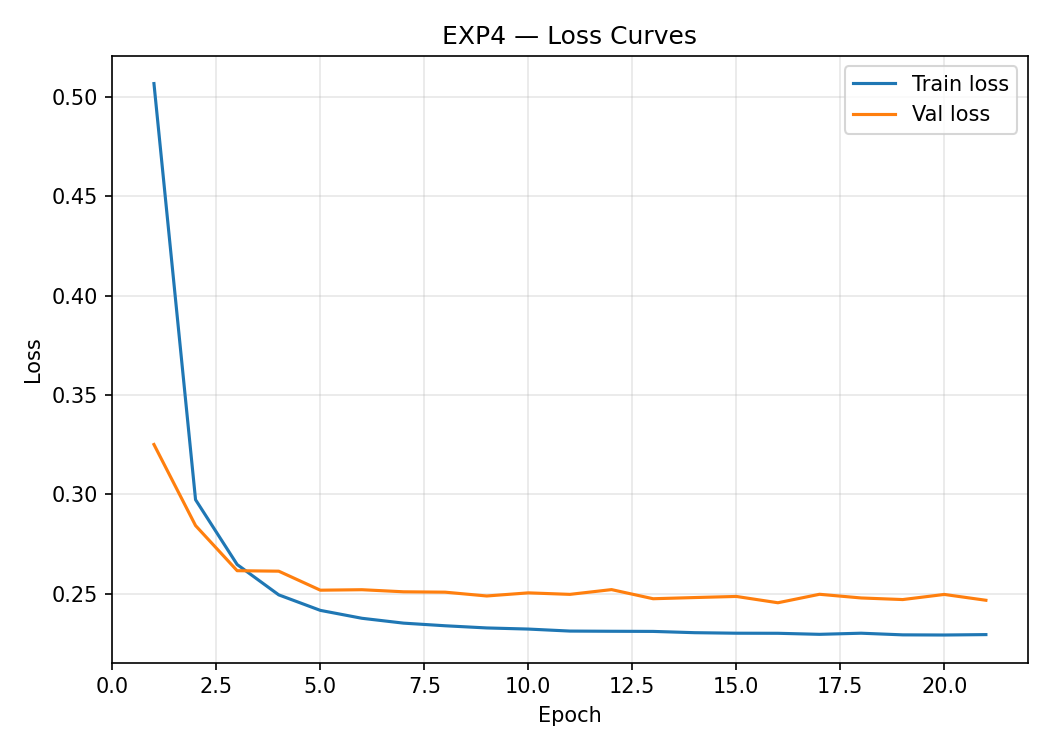


  f1_curves.png


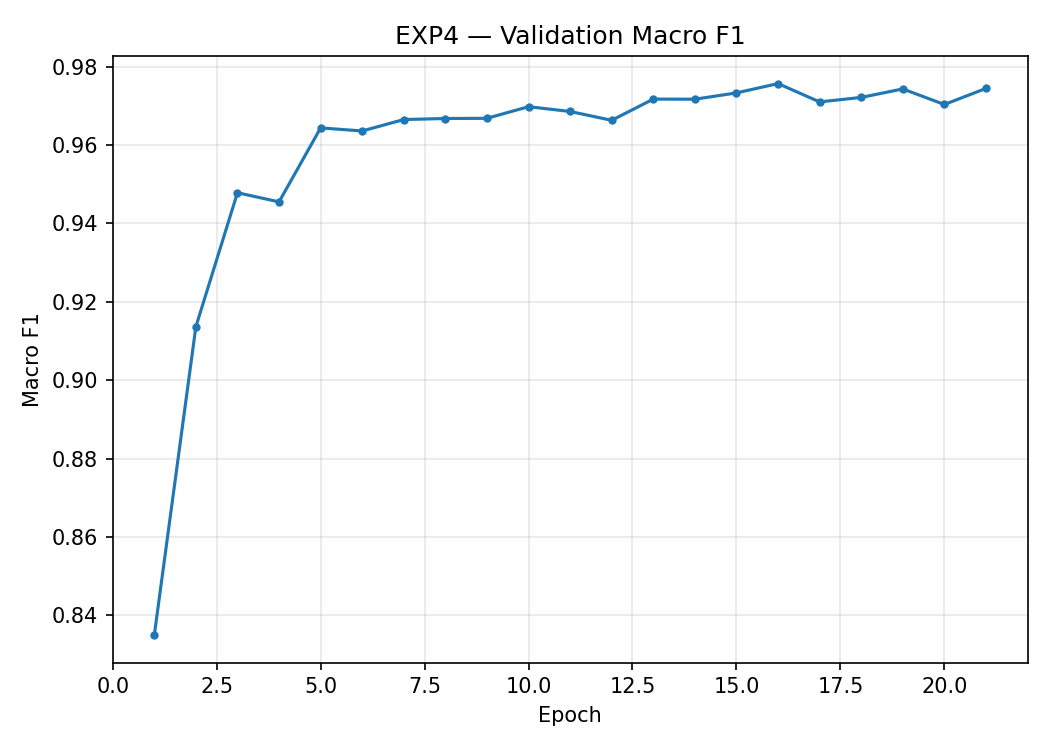


  acc_curves.png


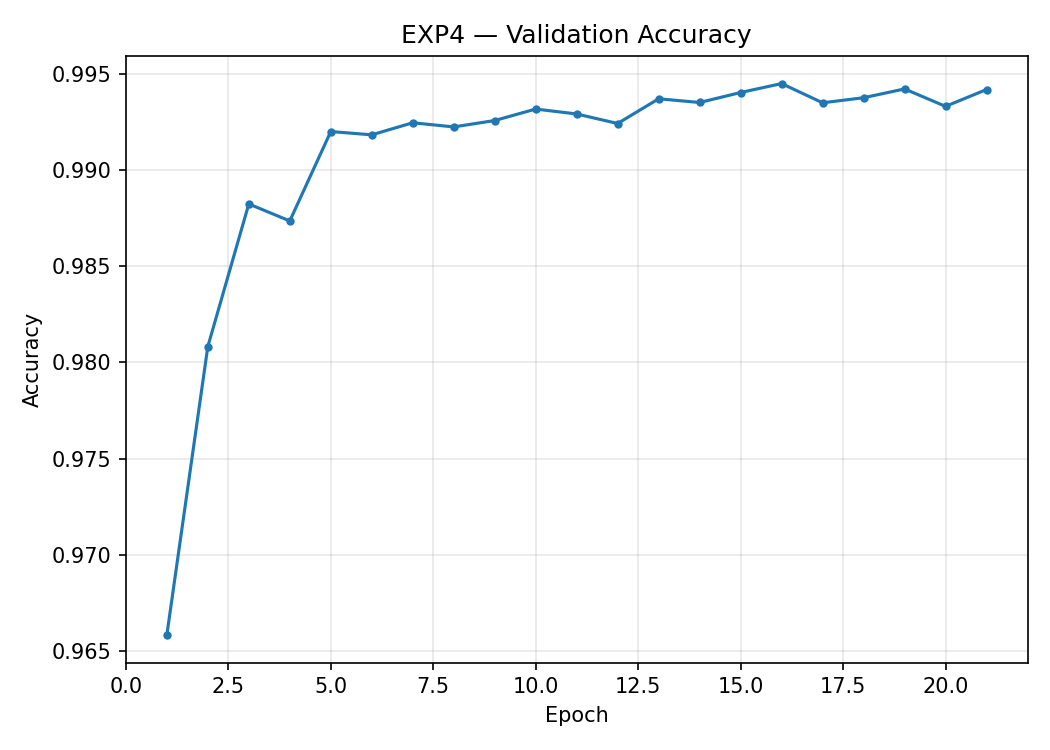


  cm_val_fam_pooled_abs.png


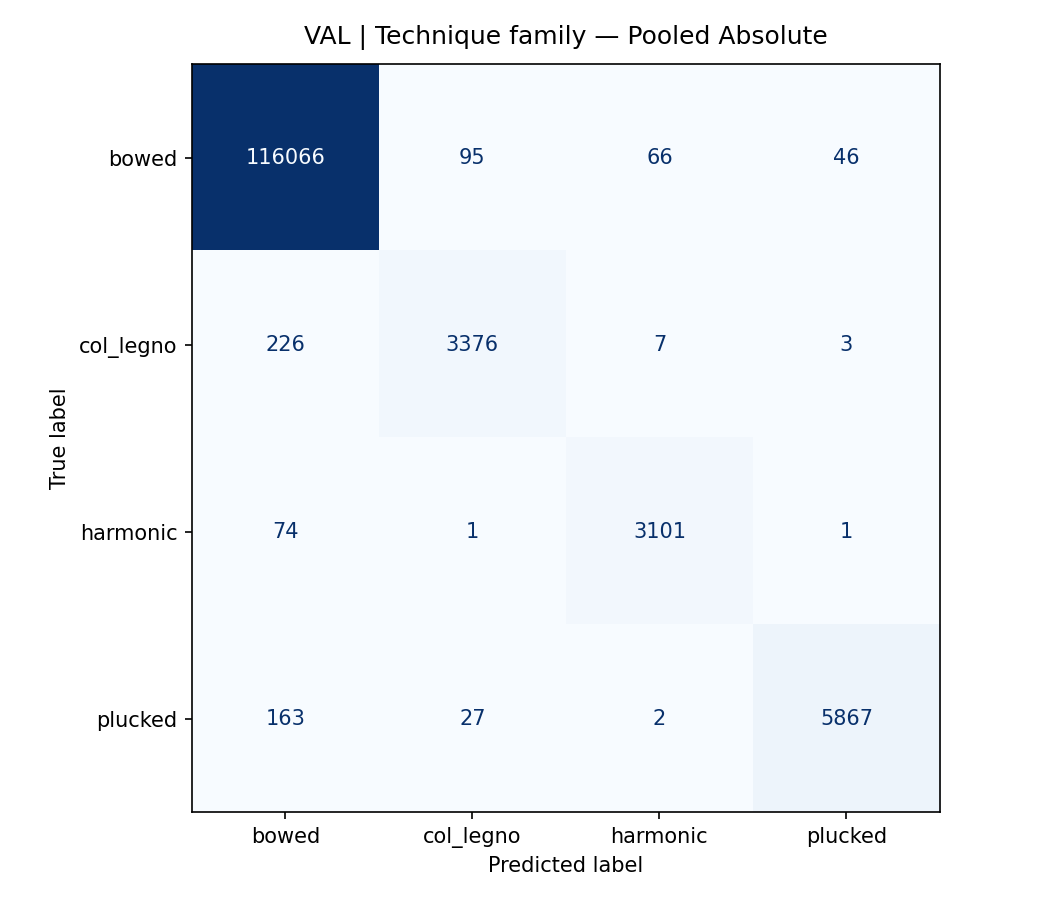


  cm_val_fam_pooled_norm.png


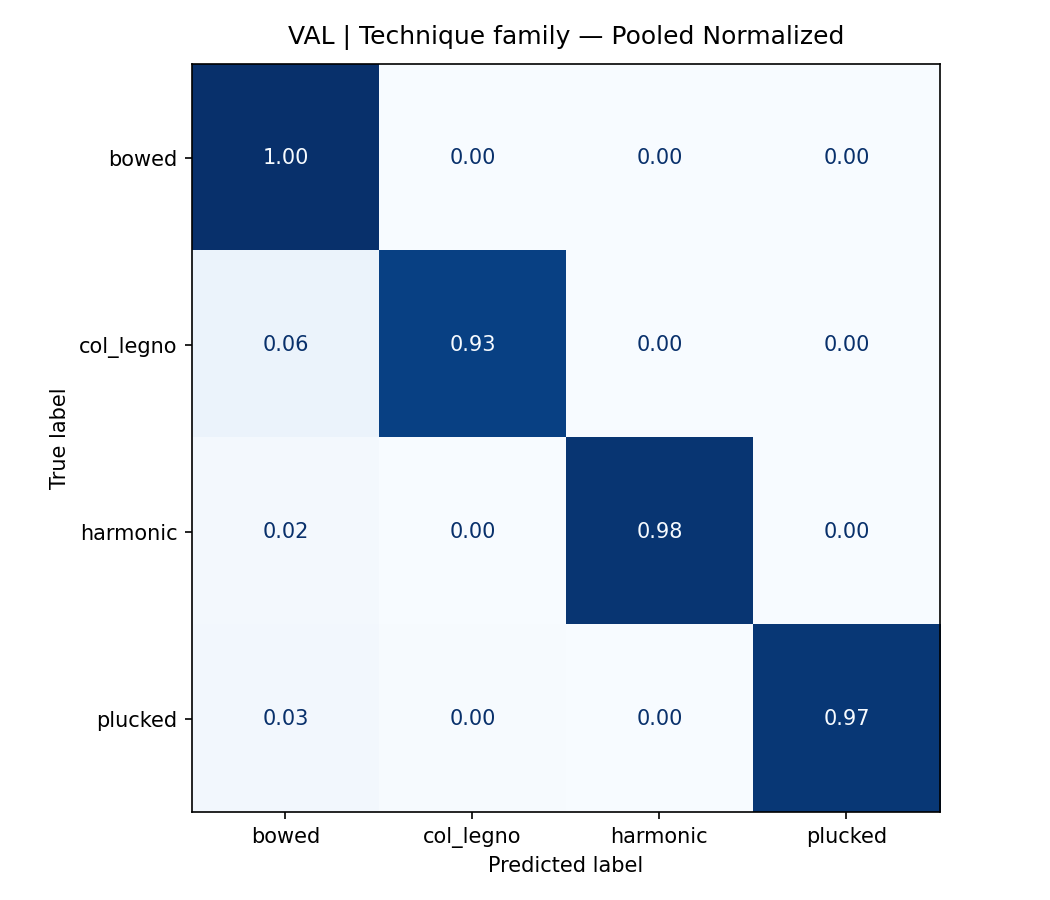


  cm_test_fam_pooled_abs.png


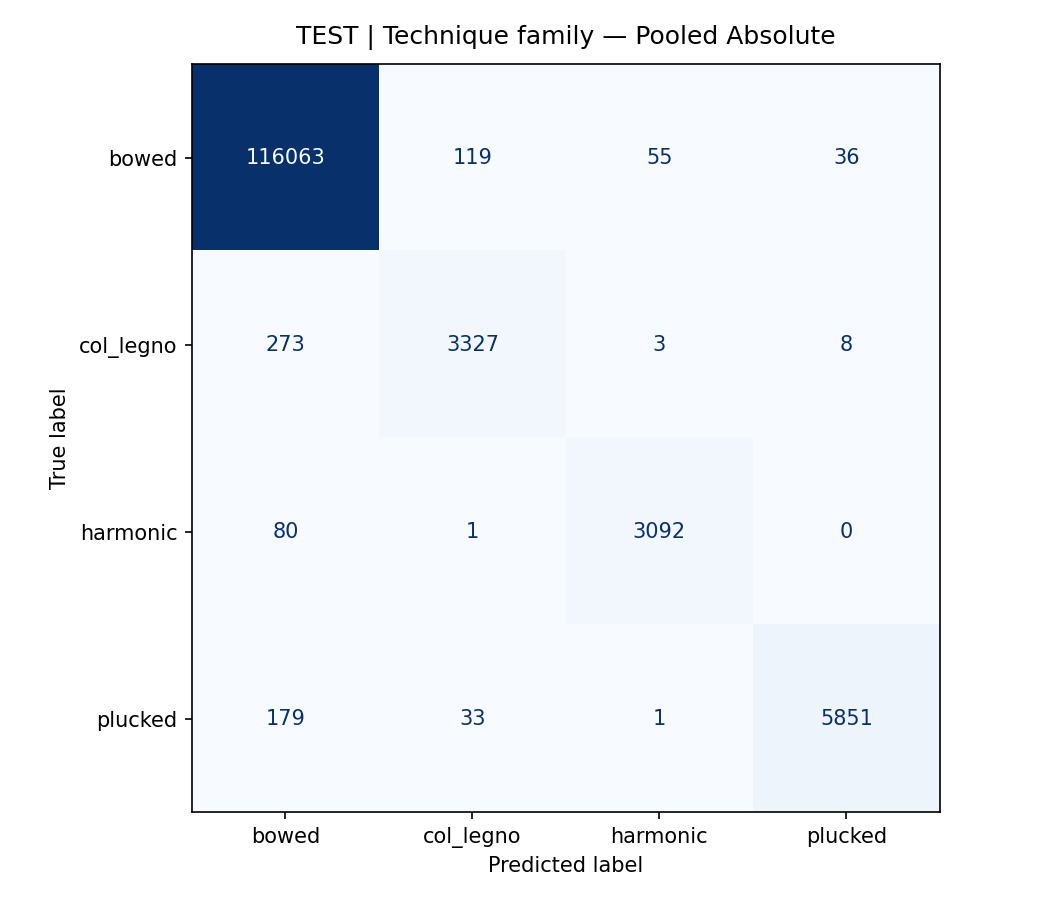


  cm_test_fam_pooled_norm.png


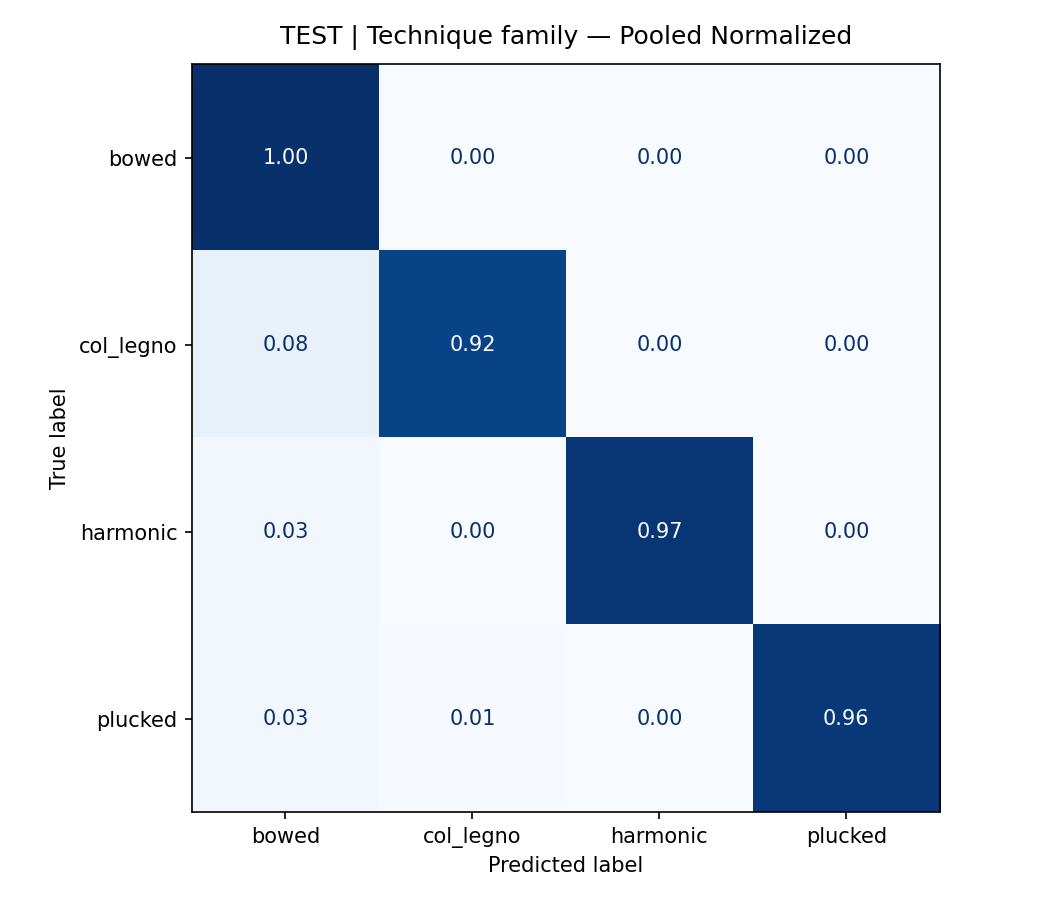


  cm_val_fam_cello_abs.png


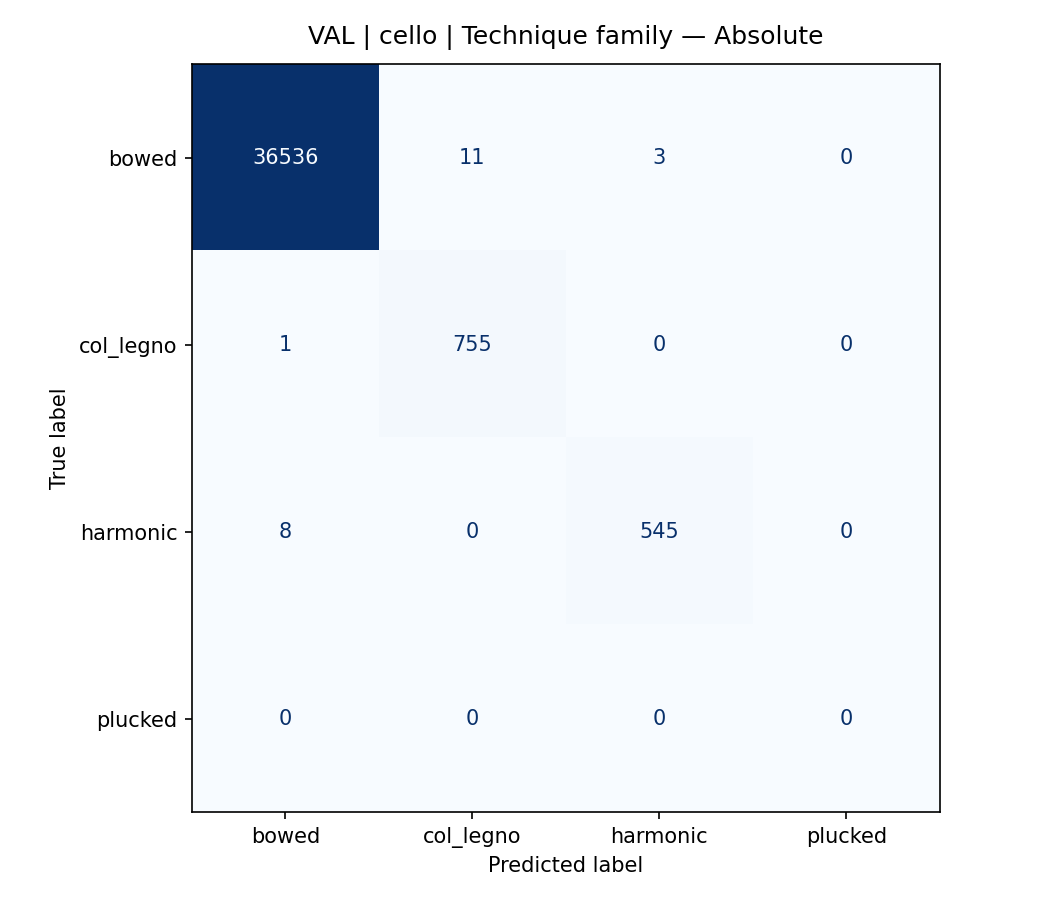


  cm_val_fam_cello_norm.png


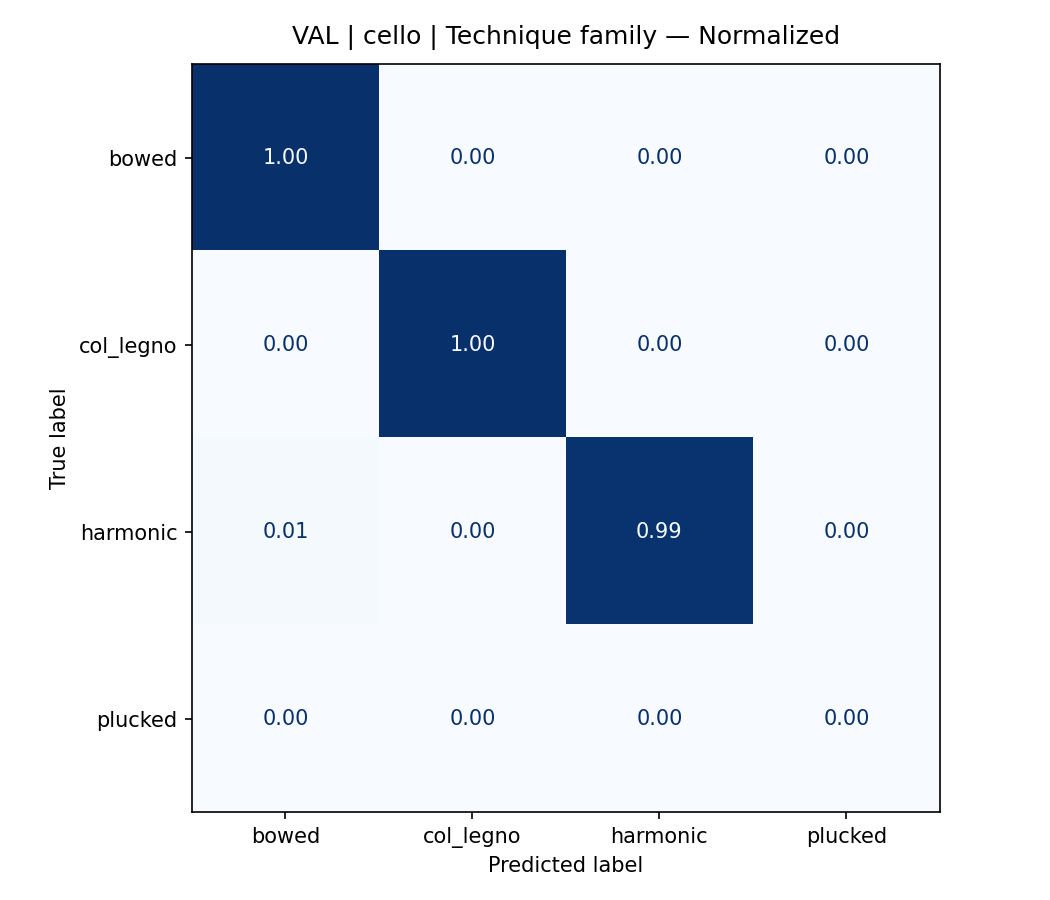


  cm_test_fam_cello_abs.png


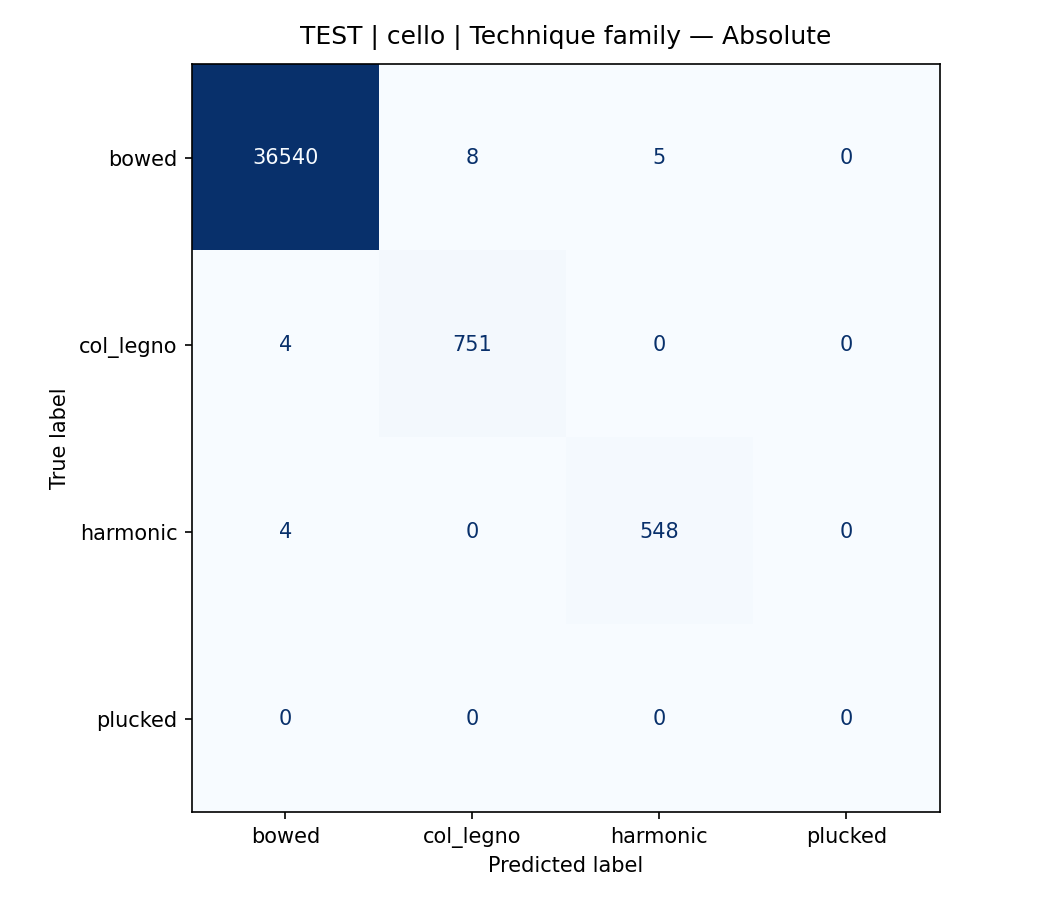


  cm_test_fam_cello_norm.png


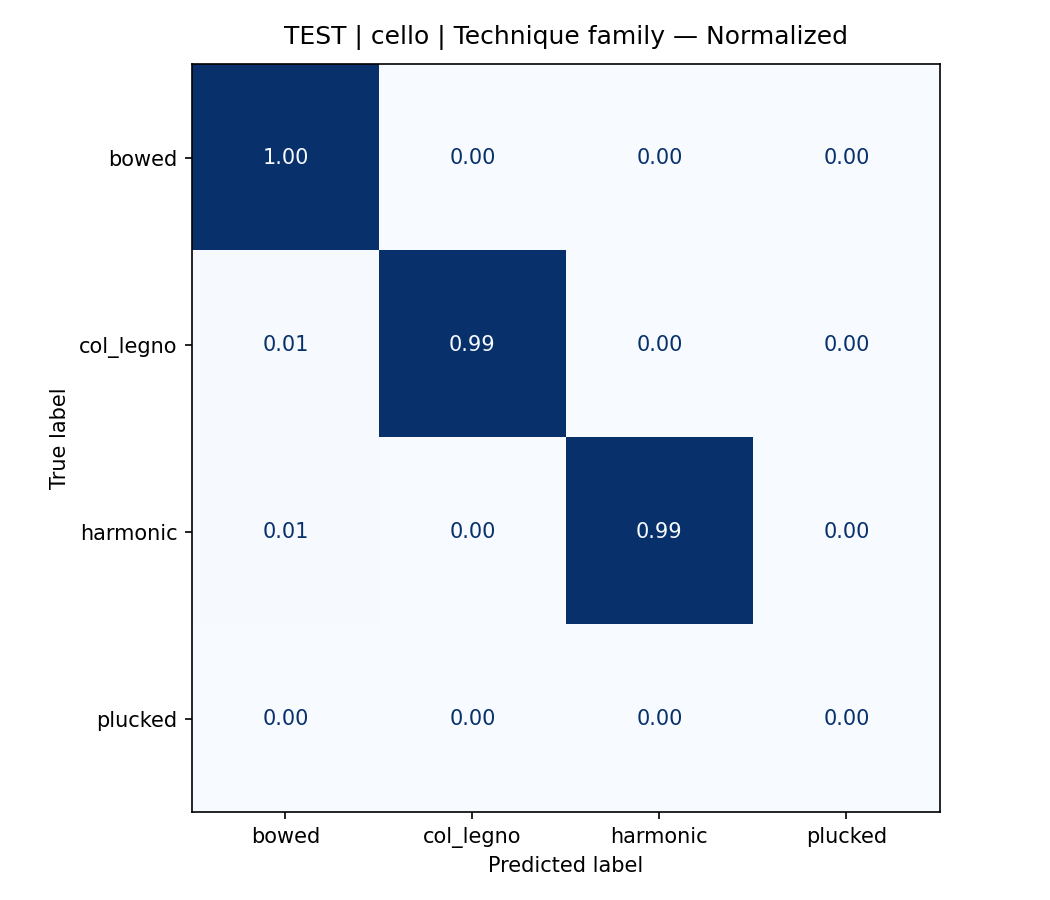


  cm_val_fam_viola_abs.png


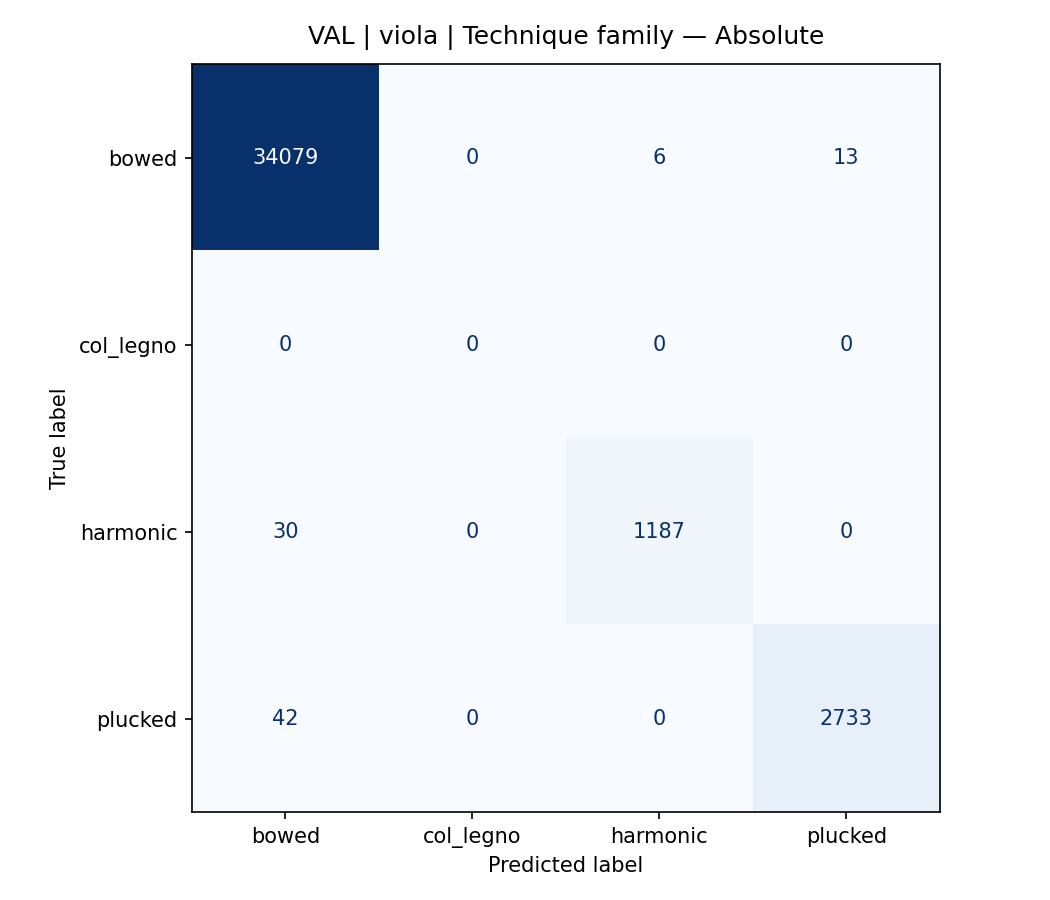


  cm_val_fam_viola_norm.png


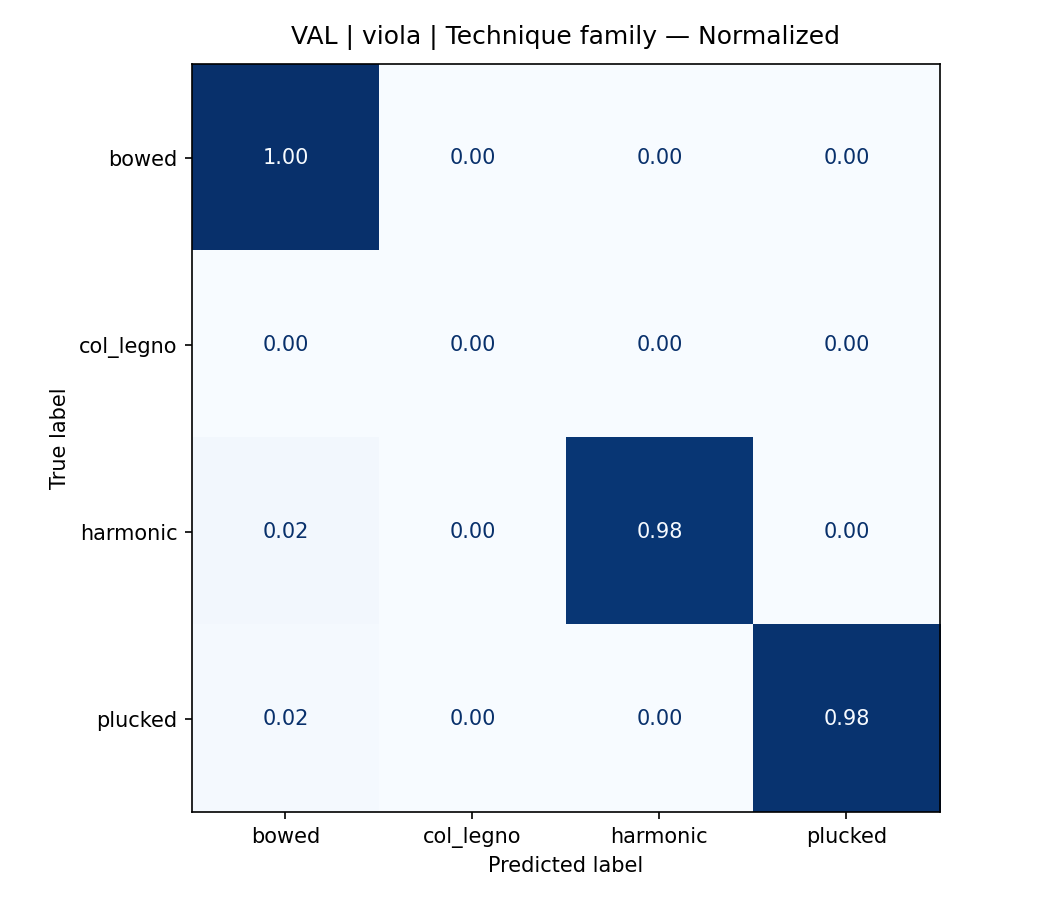


  cm_test_fam_viola_abs.png


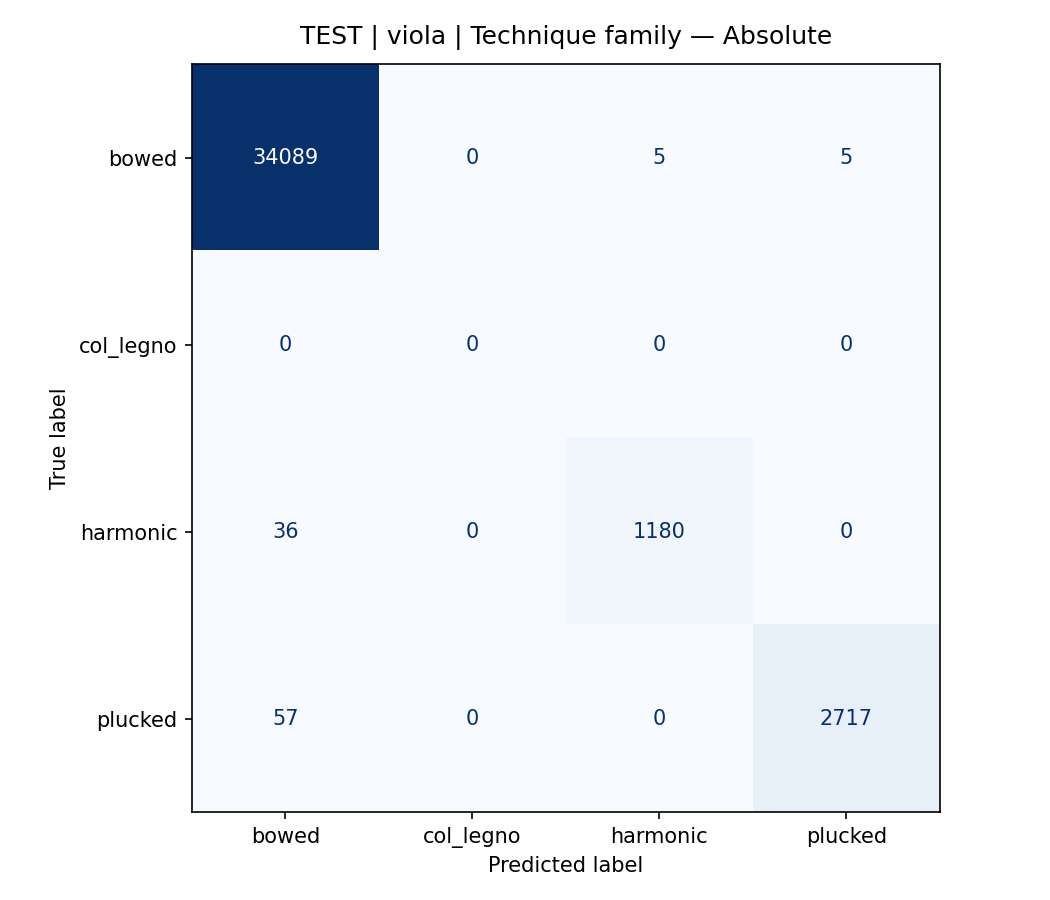


  cm_test_fam_viola_norm.png


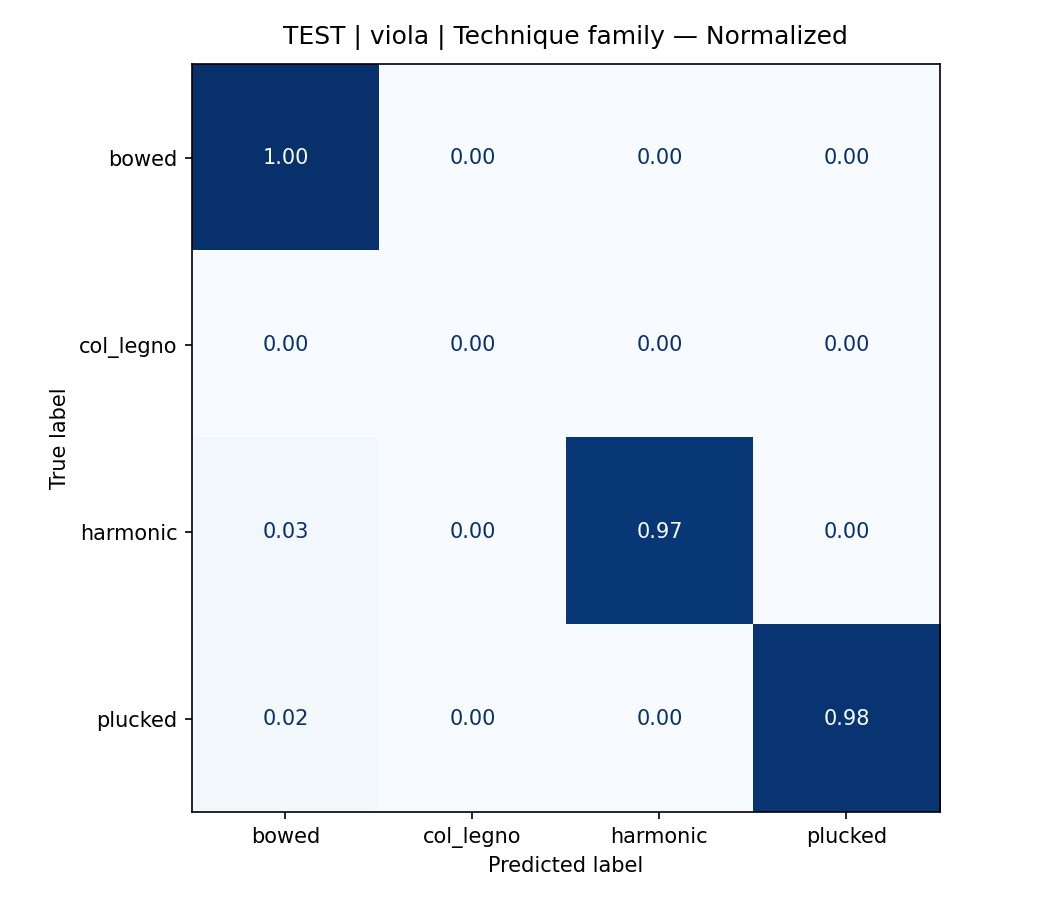


  cm_val_fam_violin2_abs.png


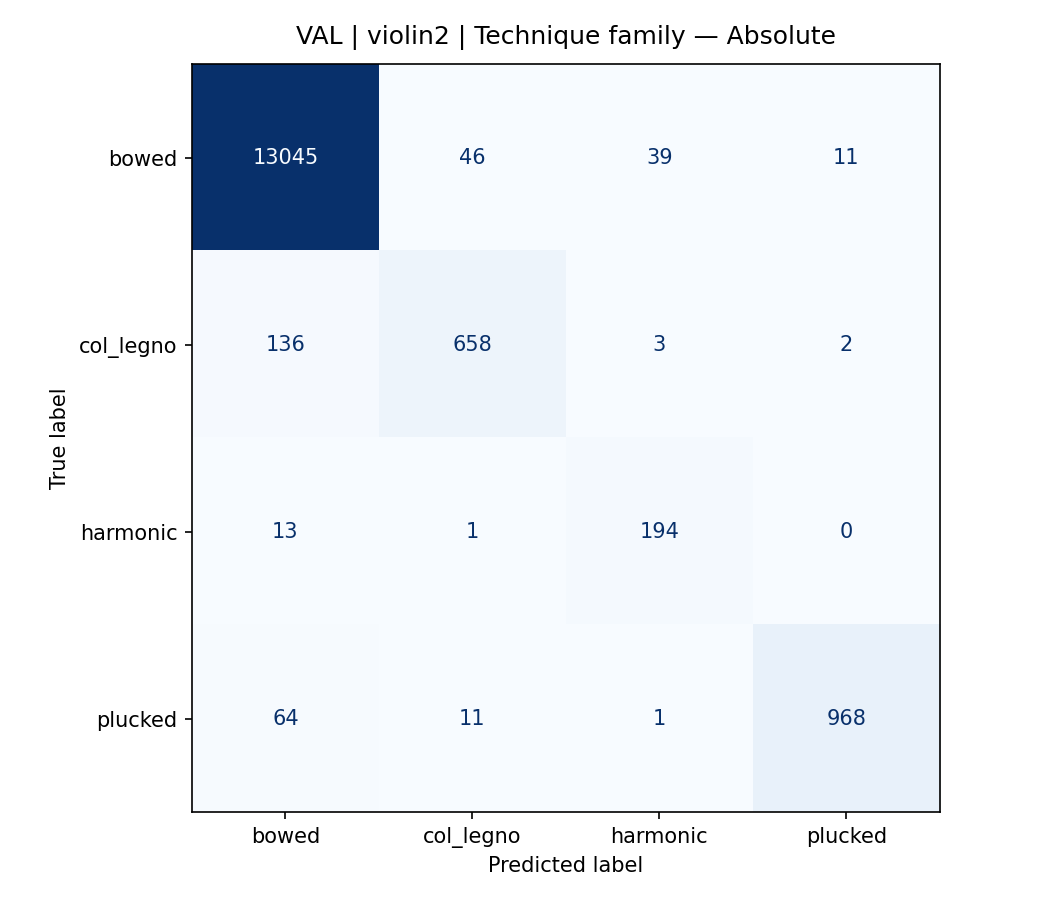


  cm_val_fam_violin2_norm.png


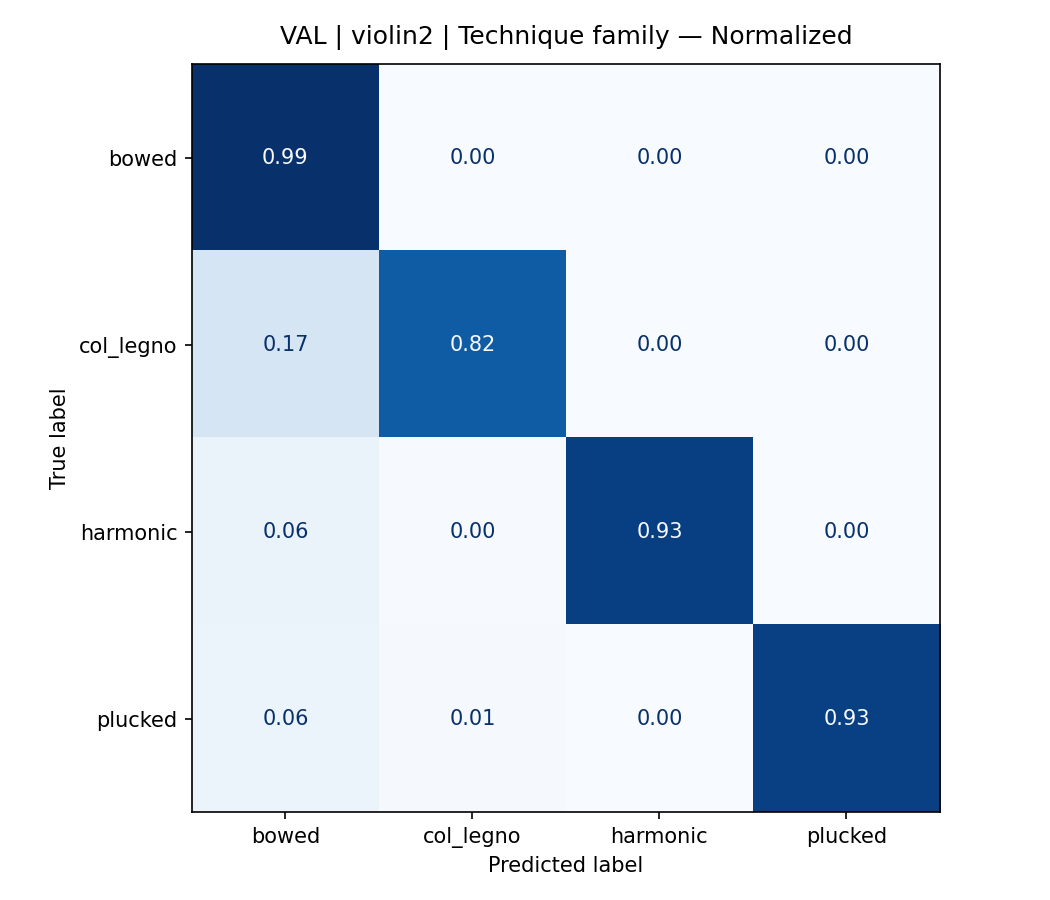


  cm_test_fam_violin2_abs.png


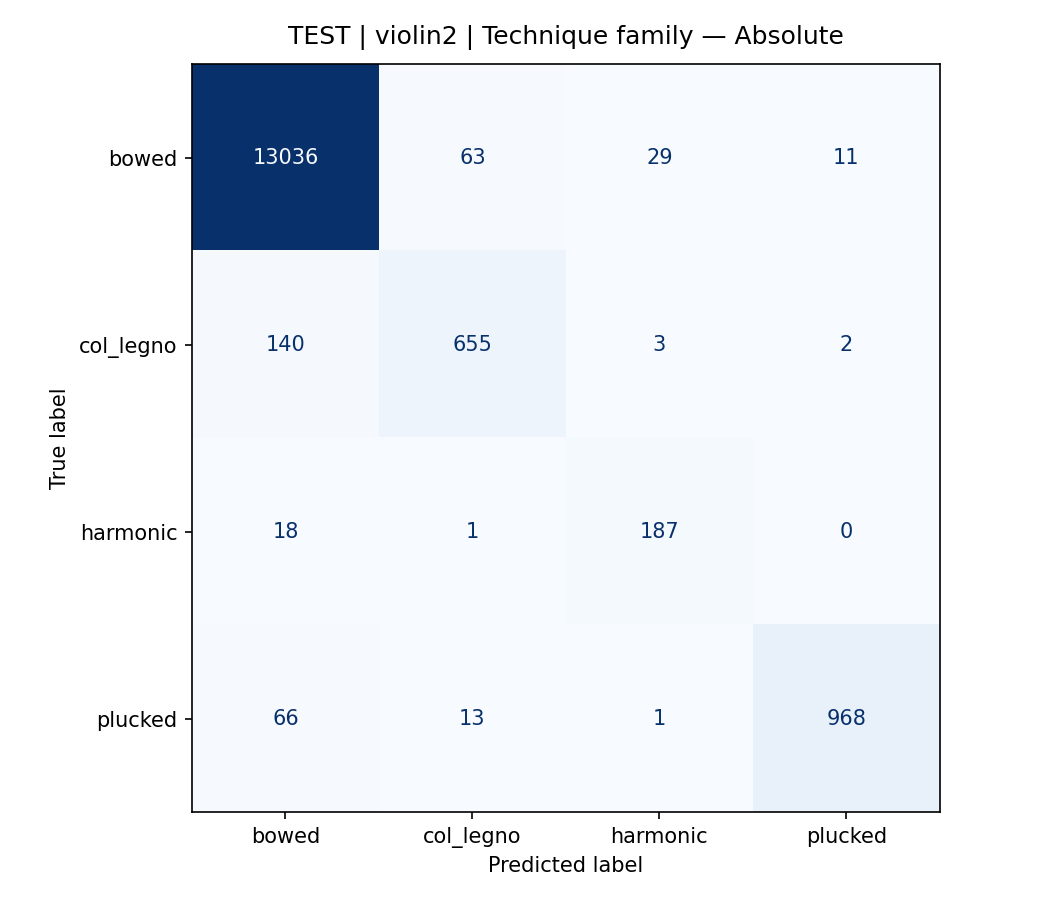


  cm_test_fam_violin2_norm.png


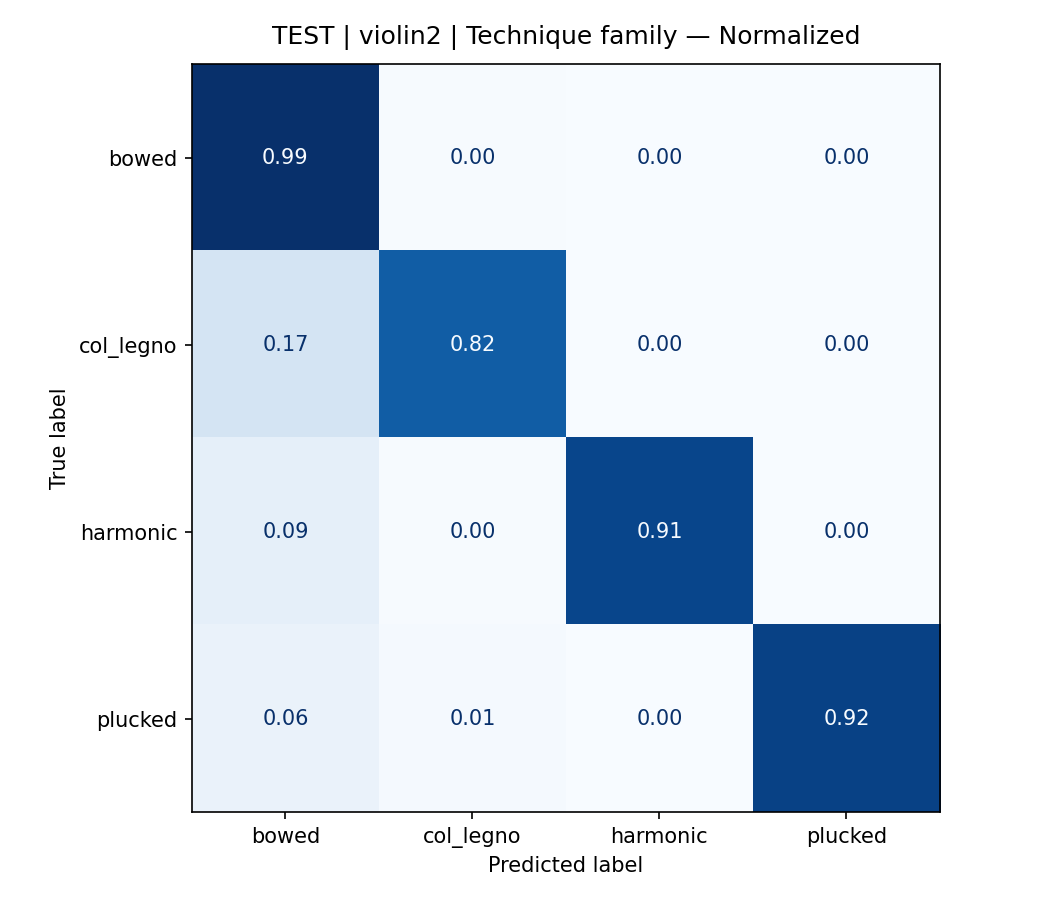


  cm_val_fam_violin1_abs.png


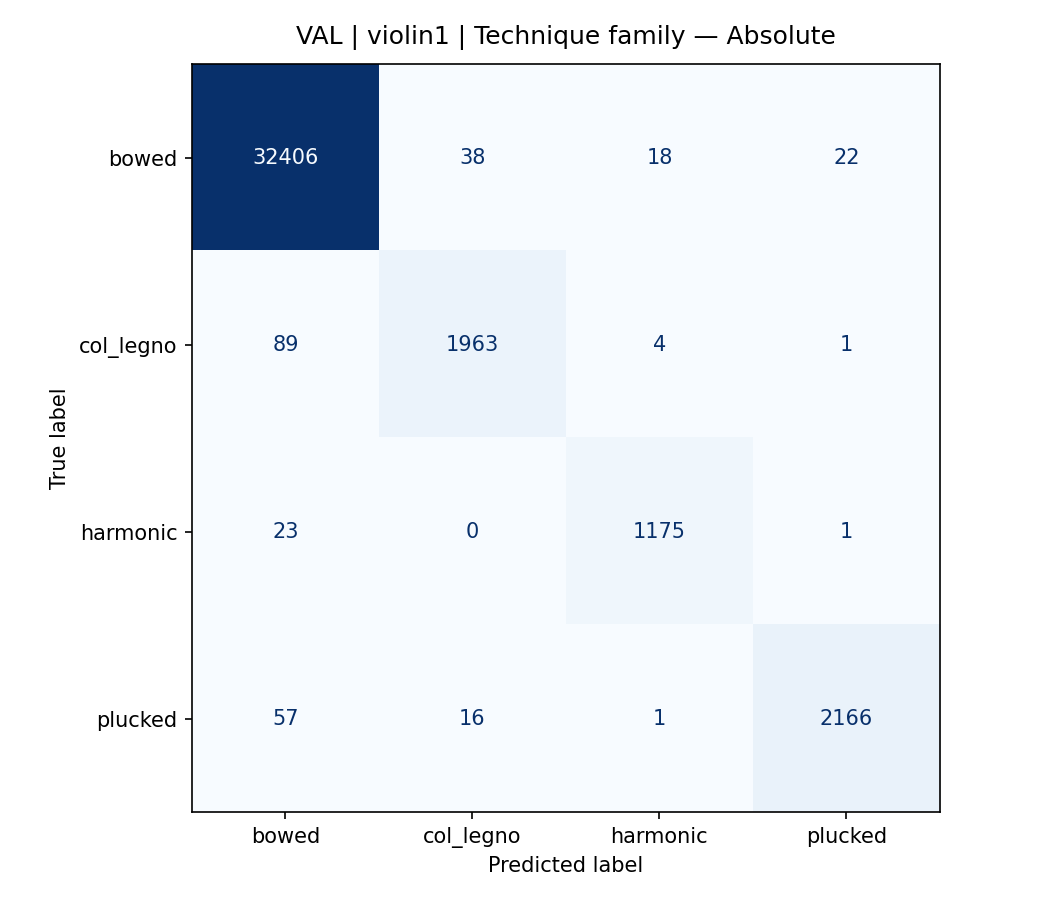


  cm_val_fam_violin1_norm.png


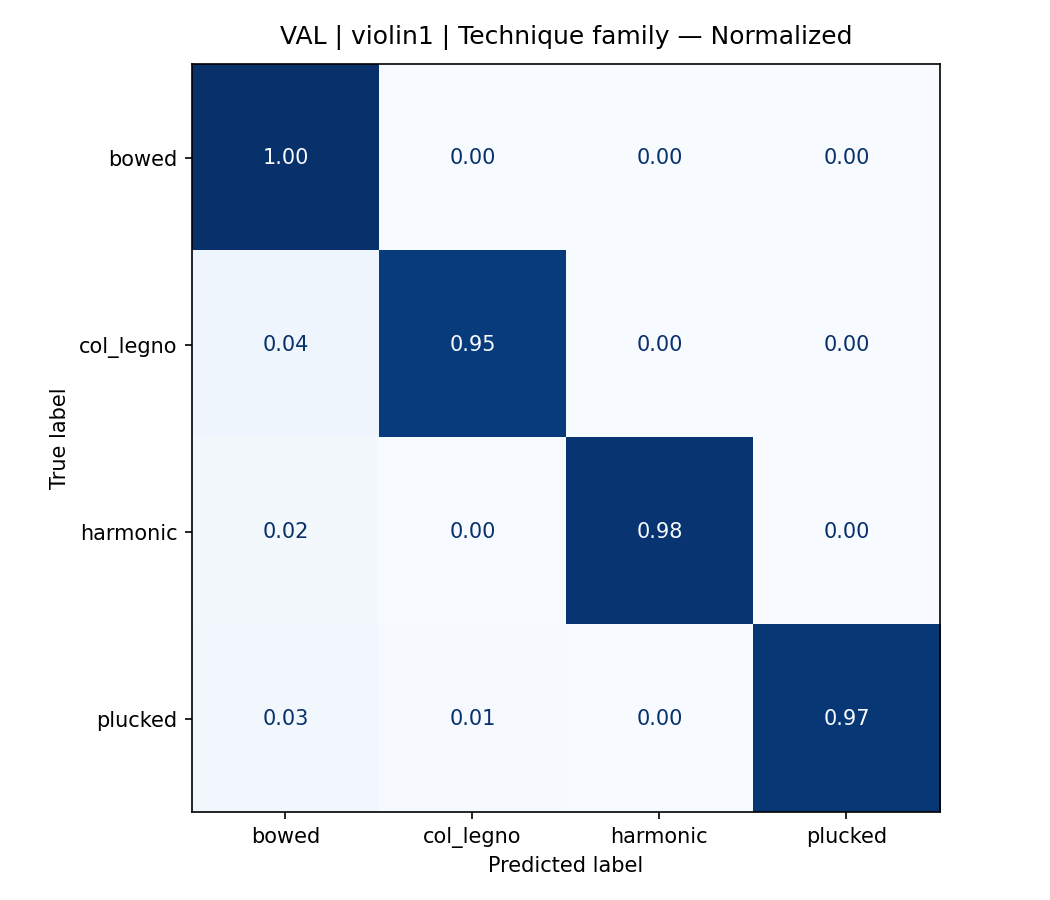


  cm_test_fam_violin1_abs.png


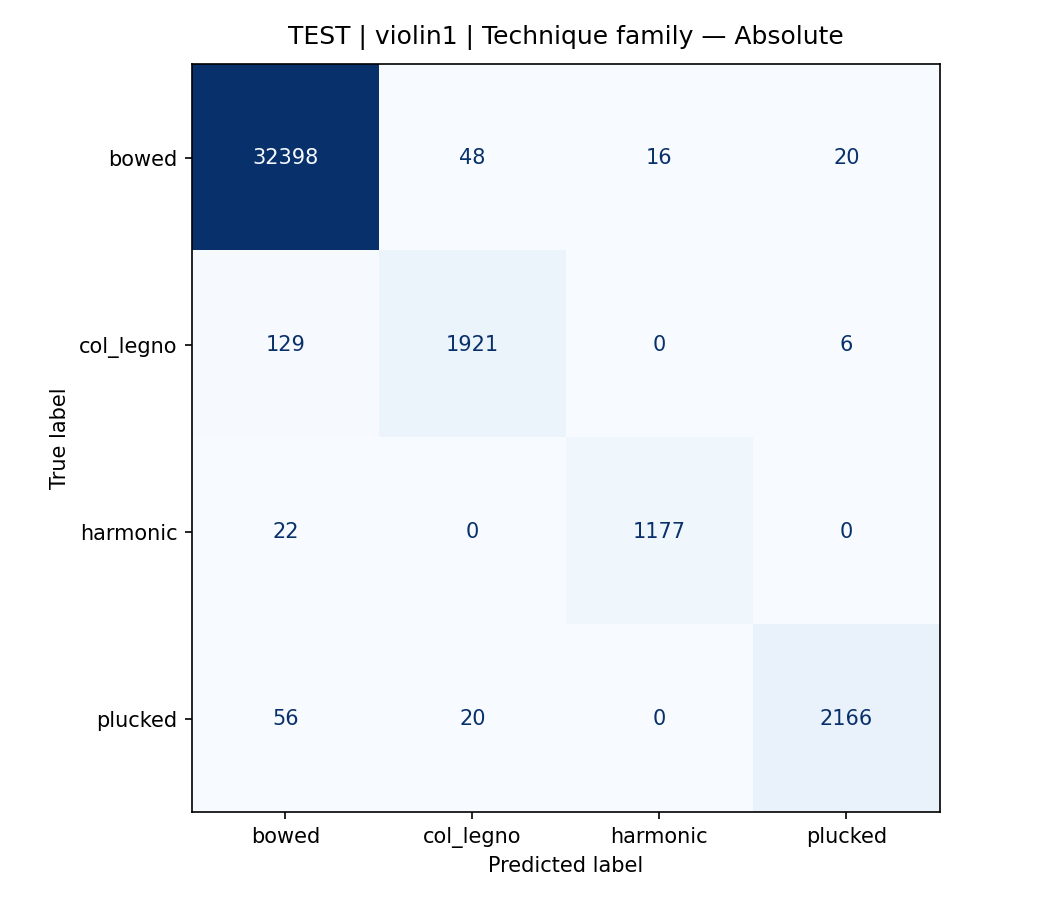


  cm_test_fam_violin1_norm.png


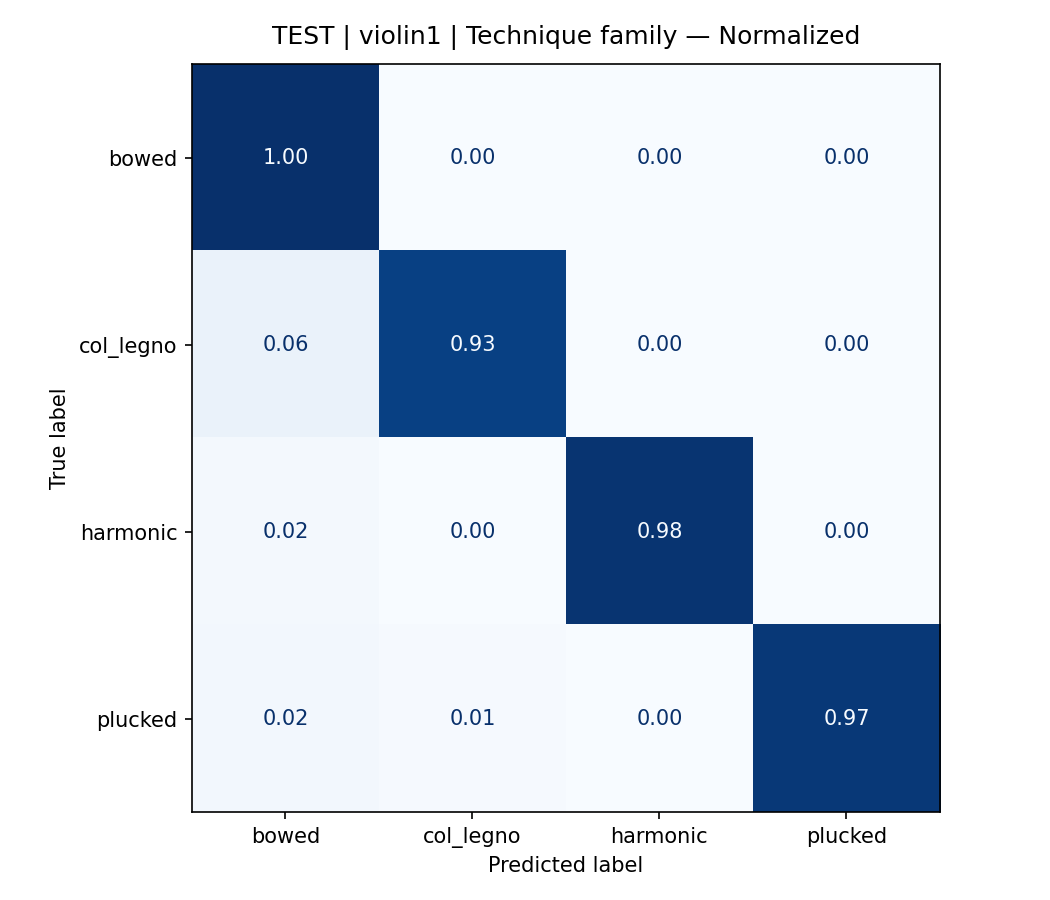


All 23 expected artifacts present.
------------------------------------------------------------
[Cell 13.1]  finished 2026-04-13  07:09:46  |  duration: 0.1s


In [52]:
# Cell 13.1 — Artifact Preview
cell_start("Cell 13.1")

import os
from IPython.display import display, Image

art_dir = os.path.join(OUTDIR, "artifacts")

if not os.path.isdir(art_dir):
    print(f"Artifact directory not found: {art_dir}")
else:
    ordered_pngs = [
        "loss_curves.png",
        "f1_curves.png",
        "acc_curves.png",
        "cm_val_fam_pooled_abs.png",
        "cm_val_fam_pooled_norm.png",
        "cm_test_fam_pooled_abs.png",
        "cm_test_fam_pooled_norm.png",
    ]

    for inst in INSTR_ORDER:
        for split in ["val", "test"]:
            for suffix in ["abs", "norm"]:
                ordered_pngs.append(f"cm_{split}_fam_{inst}_{suffix}.png")

    missing = []

    print(f"Artifact Preview — {art_dir}\n")

    for fname in ordered_pngs:
        fpath = os.path.join(art_dir, fname)
        if os.path.exists(fpath):
            print(f"  {fname}")
            display(Image(filename=fpath, width=900))
            print()
        else:
            missing.append(fname)

    if missing:
        print(f"Missing artifacts ({len(missing)}):")
        for f in missing:
            print(f"  - {f}")
    else:
        print(f"All {len(ordered_pngs)} expected artifacts present.")

cell_end("Cell 13.1")

In [54]:
# Cell 13.10 — Read-only verification from original SECD CSVs for cello plucked techniques
cell_start("Cell 13.10")

import os
import pandas as pd

if "ALL_CSVS" not in globals():
    raise RuntimeError("ALL_CSVS not found. Run Cell 3 first.")

print("=" * 72)
print("READ-ONLY VERIFICATION FROM ORIGINAL CSVs — CELLO PIZZ / SNAP")
print("=" * 72)

hits = []

for csv_path in ALL_CSVS:
    df = pd.read_csv(csv_path)

    # Case A: explicit per-instrument cello technique column
    if "cello_technique" in df.columns:
        vc = df["cello_technique"].fillna("").value_counts()
        for tec, cnt in vc.items():
            if "pizz" in tec.lower() or "snap" in tec.lower():
                hits.append({
                    "csv_file": os.path.basename(csv_path),
                    "mode": "cello_technique column",
                    "technique": tec,
                    "count": int(cnt),
                })

    # Case B: duo shared technique column plus cello file
    # This checks whether cello_file itself ever contains pizz/snap in duo CSVs
    if "cello_file" in df.columns:
        cello_file_mask = df["cello_file"].fillna("").str.contains("pizz|snap", case=False, regex=True)
        n_file_hits = int(cello_file_mask.sum())
        if n_file_hits > 0:
            hits.append({
                "csv_file": os.path.basename(csv_path),
                "mode": "cello_file path",
                "technique": "pizz/snap in cello_file",
                "count": n_file_hits,
            })

if hits:
    out = pd.DataFrame(hits).sort_values(["csv_file", "mode", "technique"]).reset_index(drop=True)
    print("\nDetected cello plucked-like evidence in original CSVs:")
    display(out)
else:
    print("\nNo cello pizz/snap evidence found in the original CSV metadata.")

cell_end("Cell 13.10")

[Cell 13.10]  started  2026-04-13  07:17:56
------------------------------------------------------------
READ-ONLY VERIFICATION FROM ORIGINAL CSVs — CELLO PIZZ / SNAP

No cello pizz/snap evidence found in the original CSV metadata.
------------------------------------------------------------
[Cell 13.10]  finished 2026-04-13  07:17:59  |  duration: 2.3s


## Cell 13.11(ΟΧΙ ΥΠΟΧΡΕΩΤΙΚΟ ΚΕΛΙ) — Read-only scan of original solo cello filenames by technique

In [55]:
# Cell 13.11 — Read-only scan of original solo cello filenames by technique
cell_start("Cell 13.11")

import os
from pathlib import Path
from collections import defaultdict, Counter
import pandas as pd

print("=" * 72)
print("READ-ONLY SCAN — ORIGINAL SOLO CELLO FILENAMES BY TECHNIQUE")
print("=" * 72)

# Adjust only if your solo cello folder lives elsewhere
CANDIDATE_DIRS = [
    os.path.join(paths.base, "solo_wavs", "solo_cello"),
    "/home/aggelosger/solo_wavs/solo_cello",
    "/home/sioutas/dmlab_workspace/Audio_Technology/mir_workspace/SECD/solo_wavs/solo_cello",
]

solo_dir = None
for d in CANDIDATE_DIRS:
    if os.path.isdir(d):
        solo_dir = d
        break

if solo_dir is None:
    raise RuntimeError(
        "Could not find the solo cello directory.\n"
        f"Tried:\n" + "\n".join(f"  - {d}" for d in CANDIDATE_DIRS)
    )

print(f"Using directory -> {solo_dir}")

all_files = sorted(
    str(p) for p in Path(solo_dir).glob("*.wav")
)

if not all_files:
    raise RuntimeError(f"No .wav files found in: {solo_dir}")

print(f"Total cello .wav files found: {len(all_files):,}")

# Full known technique vocabulary from EXP4
KNOWN_TECHNIQUES = [
    "arco-normal", "arco-sul-ponticello", "arco-sul-tasto", "arco-au-talon",
    "arco-tremolo", "arco-martele", "arco-minor-trill", "arco-major-trill",
    "arco-glissando", "arco-col-legno-battuto", "arco-col-legno-tratto",
    "arco-harmonic",
    "pizz-normal", "pizz-glissando", "pizz-tremolo", "snap-pizz",
    "natural-harmonic", "artificial-harmonic",
    "molto-vibrato", "non-vibrato", "con-sord",
]

# Longest first, to avoid accidental partial matching issues
KNOWN_TECHNIQUES = sorted(KNOWN_TECHNIQUES, key=len, reverse=True)

def detect_technique_from_filename(fp: str):
    name = os.path.basename(fp).lower()
    for tech in KNOWN_TECHNIQUES:
        if tech in name:
            return tech
    return None

tech_to_files = defaultdict(list)
unknown_files = []

for fp in all_files:
    tech = detect_technique_from_filename(fp)
    if tech is None:
        unknown_files.append(fp)
    else:
        tech_to_files[tech].append(fp)

# Summary
print("\nTechnique counts found in original solo cello files:")
summary_rows = []
for tech in sorted(tech_to_files.keys()):
    summary_rows.append({"technique": tech, "count": len(tech_to_files[tech])})
summary_df = pd.DataFrame(summary_rows).sort_values(["count", "technique"], ascending=[False, True]).reset_index(drop=True)

if len(summary_df) == 0:
    print("No known technique strings detected in cello filenames.")
else:
    print(summary_df.to_string(index=False))

print(f"\nUnknown / unmatched filenames: {len(unknown_files):,}")

# Explicit plucked-family check
PLUCKED = ["pizz-normal", "pizz-glissando", "pizz-tremolo", "snap-pizz"]

print("\n" + "-" * 72)
print("PLOCKED-FAMILY CHECK IN ORIGINAL SOLO CELLO FILES")
print("-" * 72)

plucked_total = 0
for tech in PLUCKED:
    n = len(tech_to_files.get(tech, []))
    plucked_total += n
    print(f"{tech:<18} : {n:>5,}")

print(f"{'TOTAL plucked-like':<18} : {plucked_total:>5,}")

# Show examples for every detected technique
print("\n" + "-" * 72)
print("EXAMPLE FILENAMES PER DETECTED TECHNIQUE")
print("-" * 72)

for tech in sorted(tech_to_files.keys()):
    print(f"\n{tech}  ({len(tech_to_files[tech])} files)")
    for ex in tech_to_files[tech][:10]:
        print("  -", os.path.basename(ex))

if unknown_files:
    print("\n" + "-" * 72)
    print("EXAMPLE UNKNOWN / UNMATCHED FILENAMES")
    print("-" * 72)
    for ex in unknown_files[:20]:
        print("  -", os.path.basename(ex))

# Optional dataframe for inspection
scan_df = pd.DataFrame({
    "filepath": all_files,
    "filename": [os.path.basename(x) for x in all_files],
    "detected_technique": [detect_technique_from_filename(x) for x in all_files],
})

print("\nScan dataframe created as: scan_df")
print("Technique summary dataframe created as: summary_df")

cell_end("Cell 13.11")

[Cell 13.11]  started  2026-04-13  07:25:01
------------------------------------------------------------
READ-ONLY SCAN — ORIGINAL SOLO CELLO FILENAMES BY TECHNIQUE
Using directory -> /home/aggelosger/solo_wavs/solo_cello
Total cello .wav files found: 825

Technique counts found in original solo cello files:
             technique  count
           arco-normal    743
arco-col-legno-battuto     18
           non-vibrato     17
         arco-harmonic     16
      arco-major-trill     13
      arco-minor-trill     10
         molto-vibrato      8

Unknown / unmatched filenames: 0

------------------------------------------------------------------------
PLOCKED-FAMILY CHECK IN ORIGINAL SOLO CELLO FILES
------------------------------------------------------------------------
pizz-normal        :     0
pizz-glissando     :     0
pizz-tremolo       :     0
snap-pizz          :     0
TOTAL plucked-like :     0

------------------------------------------------------------------------
EXAMPLE FI